# **Data Cleaning**

**Project**: Airbnb Market Segmentation Analysis \
**Goal**: Clean the listings and reviews dataset for future analysis.

## 1. Imports & environment setup

In [1]:
import pandas as pd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

## 2. Data Loading

In [3]:
listings_raw = pd.read_csv(BASE_PATH / "data" / "raw" / "listings.csv")
reviews_raw = pd.read_csv(BASE_PATH / "data" / "raw" / "reviews.csv")

#### 2.1 Listings dataframe

In [4]:
listings_raw.head(8)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2737,https://www.airbnb.com/rooms/2737,20250914152919,2025-09-15,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,It used to be an industrial area until late 80...,https://a0.muscache.com/pictures/41225252/e955...,3047,...,5.00,4.40,4.40,NaN,f,6,0,6,0,0.04
1,11834,https://www.airbnb.com/rooms/11834,20250914152919,2025-09-15,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,"""Monti"" with its narrow cobblestone alleys, cr...",https://a0.muscache.com/pictures/miso/Hosting-...,44552,...,4.96,4.99,4.81,IT058091C29VJSIZQZ,f,1,1,0,0,1.62
2,12398,https://www.airbnb.com/rooms/12398,20250914152919,2025-09-15,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,You are at 15 minutes walking distance from hi...,https://a0.muscache.com/pictures/miso/Hosting-...,11756,...,5.00,4.89,4.83,it058091c2kv6epw8f,f,1,1,0,0,0.47
3,19965,https://www.airbnb.com/rooms/19965,20250914152919,2025-09-15,city scrape,S. Peter's Square 5 Min WALK bright and quite ...,AT ONLY 5 MINUTES WALK to S.Peter's Basilica S...,Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.90,4.90,4.54,IT058091C20YD35BX2,t,3,3,0,0,1.07
4,19967,https://www.airbnb.com/rooms/19967,20250914152919,2025-09-15,city scrape,*In front Vatican Museums 2 bedrooms quite bri...,"IN FRONT of the Vatican Museums entrance, at O...",Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.80,4.85,4.28,IT058091C20YD35BX2,t,3,3,0,0,0.32
5,20534,https://www.airbnb.com/rooms/20534,20250914152919,2025-09-15,city scrape,DormiRoma - Cedro 1 Apartment - Trastevere,Cedro 1 Apartment is located in a beautiful s...,"Trastevere, the heart of the city, home to maj...",https://a0.muscache.com/pictures/miso/Hosting-...,77540,...,4.79,4.92,4.27,IT058091B4I3RFDVLG,t,5,5,0,0,0.27
6,20587,https://www.airbnb.com/rooms/20587,20250914152919,2025-09-15,city scrape,DormiRoma - Cedro 4 Apartment - Trastevere,Cedro 4 Apartment is located in a beautiful se...,"Trastevere, the heart of the city, home to maj...",https://a0.muscache.com/pictures/miso/Hosting-...,77540,...,4.94,4.89,4.70,IT058091B4PUG96AR4,t,5,5,0,0,0.48
7,20699,https://www.airbnb.com/rooms/20699,20250914152919,2025-09-15,city scrape,Vintage Suite w/ Private Bath by Esquiline Suites,This bright and elegant Vintage Suite by Esqui...,The multi-ethnic neighborhood of Esquilino is ...,https://a0.muscache.com/pictures/31060743/8d30...,78287,...,4.95,4.55,4.77,IT058091C1AXWLCJ7C,t,8,2,6,0,3.89


In [5]:
listings_raw.shape

(37652, 79)

In [6]:
listings_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            37652 non-null  int64  
 1   listing_url                                   37652 non-null  str    
 2   scrape_id                                     37652 non-null  int64  
 3   last_scraped                                  37652 non-null  str    
 4   source                                        37652 non-null  str    
 5   name                                          37652 non-null  str    
 6   description                                   36703 non-null  str    
 7   neighborhood_overview                         17721 non-null  str    
 8   picture_url                                   37652 non-null  str    
 9   host_id                                       37652 non-null  int64  
 1

In [7]:
listings_raw.describe(include = 'all')

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.765200e+04,37652,3.765200e+04,37652,37652,37652,36703,17721,37652,3.765200e+04,...,32254.000000,32252.000000,32253.000000,34589,37652,37652.000000,37652.000000,37652.000000,37652.000000,32255.000000
unique,NaN,37652,NaN,2,2,36682,33713,15191,37344,NaN,...,NaN,NaN,NaN,26958,2,NaN,NaN,NaN,NaN,NaN
top,NaN,https://www.airbnb.com/rooms/2737,NaN,2025-09-15,city scrape,Appartamento,Relax in this peaceful and centrally-located p...,Located in the north of the city center Monti ...,https://a0.muscache.com/pictures/miso/Hosting-...,NaN,...,NaN,NaN,NaN,"I applied for a CIN, but haven’t received it yet",t,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,33064,33668,18,77,15,12,NaN,...,NaN,NaN,NaN,337,22855,NaN,NaN,NaN,NaN,NaN
mean,7.461415e+17,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.611336e+08,...,4.856055,4.753798,4.686264,NaN,NaN,9.467598,7.847657,1.527276,0.027701,1.744446
std,5.767852e+17,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.432036e+08,...,0.299506,0.317206,0.361069,NaN,NaN,27.352151,27.028811,3.706959,0.540813,1.626930
min,2.737000e+03,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.353000e+03,...,1.000000,1.000000,1.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.892659e+07,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.960476e+07,...,4.830000,4.650000,4.600000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.440000
50%,9.477797e+17,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,1.757405e+08,...,4.950000,4.840000,4.760000,NaN,NaN,2.000000,1.000000,0.000000,0.000000,1.260000
75%,1.269260e+18,NaN,2.025091e+13,NaN,NaN,NaN,NaN,NaN,NaN,5.014931e+08,...,5.000000,4.970000,4.890000,NaN,NaN,6.000000,3.000000,2.000000,0.000000,2.650000


#### 2.2 Reviews dataframe

In [8]:
reviews_raw.head(8)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2737,24343517,2014-12-26,24333039,Raphaell,"This spot was in a great and nice area,walking..."
1,2737,24966779,2015-01-04,10493776,Ia,"Elif was really very helpful, while arranging ..."
2,2737,29770086,2015-04-12,29630601,Julia,"Elif's flat is spacious, clean, and had everyt..."
3,2737,30477570,2015-04-22,31215535,Sevil,I had a wonderful time staying with Elif and h...
4,2737,31659336,2015-05-08,1959813,Suzy,"Elif was a brilliant host, with an exceptional..."
5,11834,246099,2011-05-01,346365,Joanne,We loved our stay at Boschetto House. It was a...
6,11834,343799,2011-06-30,388909,Eteri,Everything was perfect! The apartment in a per...
7,11834,529617,2011-09-13,953228,Ginger,Apartment: Very nicely set up for guests - wel...


In [9]:
reviews_raw.shape

(2193330, 6)

In [10]:
reviews_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2193330 entries, 0 to 2193329
Data columns (total 6 columns):
 #   Column         Dtype
---  ------         -----
 0   listing_id     int64
 1   id             int64
 2   date           str  
 3   reviewer_id    int64
 4   reviewer_name  str  
 5   comments       str  
dtypes: int64(3), str(3)
memory usage: 100.4 MB


In [11]:
reviews_raw.describe(include = 'all')

,listing_id,id,date,reviewer_id,reviewer_name,comments
count,2.193330e+06,2.193330e+06,2193330,2.193330e+06,2193326,2193194
unique,NaN,NaN,5242,NaN,210331,2128354
top,NaN,NaN,2025-06-15,NaN,David,.
freq,NaN,NaN,3059,NaN,12442,3364
mean,2.786899e+17,7.687826e+17,NaN,1.988914e+08,NaN,NaN
std,4.496493e+17,5.411816e+17,NaN,1.838539e+08,NaN,NaN
min,2.737000e+03,4.220600e+04,NaN,4.600000e+01,NaN,NaN
25%,9.950970e+06,5.757394e+08,NaN,4.574577e+07,NaN,NaN
50%,2.920817e+07,9.099389e+17,NaN,1.344782e+08,NaN,NaN
75%,6.590309e+17,1.238298e+18,NaN,3.235647e+08,NaN,NaN


##  3. Duplicates check

#### 3.1 Listings dataframe

In [12]:
# duplicated listings ids 
print(listings_raw.duplicated("id").sum())

# duplicated whole rows
print(listings_raw.duplicated(subset=listings_raw.columns.drop('id')).sum())

# duplicated listings names
print(listings_raw.duplicated("name").sum())

# duplicated listings descriptions
print(listings_raw.duplicated("description").sum())

# duplicated listing_urls
print(listings_raw.duplicated("listing_url").sum())

0
0
970
3938
0


In [13]:
# print rows with duplicated names
listings_raw[listings_raw.duplicated("name", keep = False)].sort_values(by = 'name')

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
24155,1147781118331143481,https://www.airbnb.com/rooms/1147781118331143481,20250914152919,2025-09-15,previous scrape,(Colosseo) Camera di lusso al centro di Roma,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,4.88,4.88,IT058091B49GCHE6QW,t,6,0,6,0,0.51
24226,1150716406754631079,https://www.airbnb.com/rooms/1150716406754631079,20250914152919,2025-09-15,city scrape,(Colosseo) Camera di lusso al centro di Roma,The San Giovanni Retreat is a Luxury Guesthous...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,5.00,4.00,IT058091B49GCHE6QW,t,6,0,6,0,0.21
24219,1150660321577994956,https://www.airbnb.com/rooms/1150660321577994956,20250914152919,2025-09-15,city scrape,(Colosseo)Camera con balcone al centro di Roma,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,5.00,4.50,IT058091B49GCHE6QW,t,6,0,6,0,0.13
24220,1150668316352949889,https://www.airbnb.com/rooms/1150668316352949889,20250914152919,2025-09-15,city scrape,(Colosseo)Camera con balcone al centro di Roma,The San Giovanni Retreat is a Luxury Guesthous...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,484756313,...,5.00,4.80,4.60,IT058091B49GCHE6QW,t,6,0,6,0,0.31
6506,23972978,https://www.airbnb.com/rooms/23972978,20250914152919,2025-09-15,city scrape,4321 Stazione Trastevere bed & breakfast,"Bright, quiet and panoramic apartment of 75 sq...","The neighborhood is popular, very 'Roman', fri...",https://a0.muscache.com/pictures/hosting/Hosti...,158506090,...,5.00,4.81,4.94,IT058091C12ULQTFXQ,f,3,1,2,0,0.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4727,15995943,https://www.airbnb.com/rooms/15995943,20250914152919,2025-09-15,previous scrape,stanza singola,The New Inn and a cozy guest house of Rome loc...,NaN,https://a0.muscache.com/pictures/836b19c9-441f...,88872950,...,4.81,4.75,4.58,IT058091B4MCJW7Q4U,t,11,1,8,0,2.21
892,1997075,https://www.airbnb.com/rooms/1997075,20250914152919,2025-09-15,city scrape,☆ BunkBeds BR in Beautiful Artsy APT in Traste...,Beautiful bright dorm in the heart of Rome. Th...,We believe Trastevere is simply the best part ...,https://a0.muscache.com/pictures/hosting/Hosti...,3305730,...,4.78,4.87,4.73,IT058091C2E3HLSEAS,f,7,0,7,0,3.63
895,2005424,https://www.airbnb.com/rooms/2005424,20250914152919,2025-09-15,previous scrape,☆ BunkBeds BR in Beautiful Artsy APT in Traste...,Beautiful bright dorm in the heart of Rome. Th...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3305730,...,4.80,4.85,4.72,IT058091C2E3HLSEAS,f,7,0,7,0,2.19
896,2005557,https://www.airbnb.com/rooms/2005557,20250914152919,2025-09-15,city scrape,☆ BunkBeds BR in Beautiful Artsy APT in Traste...,Beautiful bright dorm in the heart of Rome. Th...,We believe Trastevere is simply the best part ...,https://a0.muscache.com/pictures/hosting/Hosti...,3305730,...,4.81,4.87,4.75,IT058091C2E3HLSEAS,f,7,0,7,0,2.48


**Conclusion**: Even though some listing names and descriptions are duplicated, it does not mean that the listings refer to the same physical property. A single host can possess several properties with the same title, which may refer to different units within the same building. Prices may vary based on specific amenities or features, such as city views or floor level. Since no identical rows were found (excluding the unique ID), we can proceed with the analysis.

#### 3.2 Reviews dataframe

In [14]:
# duplicated comment
print(reviews_raw.duplicated('comments').sum())

# duplicated comments for partiqular listings ids
print(reviews_raw.duplicated(['listing_id','comments']).sum())

64975
1452


In [15]:
# view duplicated comments
reviews_raw[reviews_raw.duplicated("comments", keep = False)].sort_values(by = 'comments')

,listing_id,id,date,reviewer_id,reviewer_name,comments
257370,3446829,199107187,2017-10-01,69981910,Pau,.
349682,5297331,62518043,2016-02-15,51752286,Juan,.
1624183,640992868659241936,1152735845692063393,2024-05-09,249453719,Sarah,!
1827557,884688402475449300,1239803181613887675,2024-09-06,103533669,Pierre,!
1835508,897419810510791981,1123765304186802886,2024-03-30,460899803,Kateryna,!
...,...,...,...,...,...,...
2120730,1259335350242465155,1461599805210604078,2025-07-09,572947592,Darlington,NaN
2156906,1336019852433530500,1378178104705248661,2025-03-16,509000523,Charles,NaN
2157624,1336980407431866046,1490588503836212900,2025-08-18,208335382,James,NaN
2160226,1345123522749105483,1428910279458200707,2025-05-25,107648257,Paul,NaN


In [16]:
reviews_raw[reviews_raw.duplicated(['listing_id', "comments"], keep = False)].sort_values(by = 'comments')

,listing_id,id,date,reviewer_id,reviewer_name,comments
1759099,801921683624887852,1045579413446484915,2023-12-13,66657642,Dylan,-
276174,3994822,957840381003692861,2023-08-14,529489008,Faith,-
1390881,45792786,1099233624911459843,2024-02-25,472342198,Gianmarco,-
276143,3994822,297183359,2018-07-27,116093516,Lucija,-
1390904,45792786,1173847152422932680,2024-06-07,567765401,Oliver,-
...,...,...,...,...,...,...
794593,17006035,1111453535148747411,2024-03-13,433618651,Andre,👍🏻
1712737,747766187537708990,1144147468983625590,2024-04-27,526550533,Hakan,👍🏻👍🏻👍🏻
1712729,747766187537708990,1095500240565881418,2024-02-20,553031099,Chaewon,👍🏻👍🏻👍🏻
1028941,25768601,823012323182409076,2023-02-09,485190126,Julian,NaN


In [17]:
# delete duplicates by listing_id, reviewer_id and comments columns

reviews_deduped = reviews_raw.drop_duplicates(subset = ['listing_id', 'reviewer_id', 'comments'], keep = 'first')

print(len(reviews_deduped)/len(reviews_raw)* 100)

99.99220363556783


**Conclusion**: Technical duplicates were removed using a composite key: `listing_id`, `reviewer_id`, and `comments`. This approach ensures that we preserve unique feedback from different users while filtering out system glitches or double-posts. Additionally, a significant volume of "non-text" reviews (symbols, punctuation, and emoji) was identified. These entries require further preprocessing to determine their sentiment value during the NLP stage.

## 4. Structural Cleaning & Type Casting

### 4.1 Dropping irrelevant columns

#### 4.1.1 Listings dataframe

**Column Removal Rationale**

The following columns were identified as irrelevant for the current research objectives:

- `listing_url`, `scrape_id`, `source`: these contain internal scraping information and timestamps that do not characterize the property or influence pricing.

- `picture_url`, `host_url`, `host_name`, `host_thumbnail_url`, `host_picture_url`, `host_location`: visual content and URLs do not provide analytical value for segmentation and host identity is preserved via host_id.

- `neighbourhood`, `neighbourhood_group_cleansed`: `neighbourhood_cleansed` provides the most accurate and standardized location data for Rome and `neighbourhood_group_cleansed` is entirely empty in this dataset.

- `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`,`maximum_maximum_nights`, `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm`: these are seasonal variations of the base rules. They are highly correlated with the main minimum_nights column and introduce multi-collinearity and noise.

- `calendar_updated`, `has_availability`, `availability_30`, `availability_60`, `availability_eoy`: short-term availability fluctuates daily and is less indicative of long-term business strategy than availability_90 or availability_365.

- `number_of_reviews_ltm`, `number_of_reviews_l30d`, `number_of_reviews_ly`, `estimated_occupancy_l365d`, `estimated_revenue_l365d`: these are calculated using black-box formulas from Inside Airbnb. To ensure research integrity, we rely on raw metrics or perform our own calculations.

- `calculated_host_listings_count_entire_homes`, `calculated_host_listings_count_private_rooms`, `calculated_host_listings_count_shared_rooms`: the total count `calculated_host_listings_count` is sufficient for segmenting professional vs. amateur hosts.

In [18]:
# list of irrelevant columns

irr_cols_listings = ['listing_url', 'scrape_id', 'source', 'picture_url'
                    , 'host_url', 'host_name', 'host_thumbnail_url', 'host_picture_url', 'host_location'
                    , 'neighbourhood', 'neighbourhood_group_cleansed'
                    , 'minimum_minimum_nights', 'maximum_minimum_nights'
                    , 'minimum_maximum_nights', 'maximum_maximum_nights'
                    , 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'
                    , 'calendar_updated'
                    , 'has_availability', 'availability_30', 'availability_60'
                    , 'calendar_last_scraped'
                    , 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'first_review'
                    , 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d'
                    , 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']

listings_cleaned = listings_raw.drop(irr_cols_listings, axis = 'columns')

#### 4.1.2 Reviews dataframe

In [19]:
# list of irrelevant columns

irr_cols_reviews = ['id', 'reviewer_name']

reviews_cleaned = reviews_deduped.drop(irr_cols_reviews, axis = 'columns')

### 4.2 Parsing Complex Data Structures

#### 4.2.1 Listings dataframe

- **Date columns** : `host_since`, `last_review`

In [20]:
# transfrom host_since variable from date to number of years

listings_cleaned['host_experience_years'] = ((pd.to_datetime(listings_cleaned['last_scraped']) - pd.to_datetime(listings_cleaned['host_since'])).dt.days / 365.25).round(1)

#transform last_review to number of days since last review
listings_cleaned['last_review_recency'] = ((pd.to_datetime(listings_cleaned['last_scraped']) - pd.to_datetime(listings_cleaned['last_review'])).dt.days).round(1)

listings_cleaned.drop(['host_since', 'last_review', 'last_scraped'], axis = 'columns', inplace = True)

- **% columns** : `host_response_rate`, `host_acceptance_rate`

In [21]:
# transform host_response_rate to float
listings_cleaned['host_response_rate'] = round(listings_cleaned['host_response_rate'].str.replace('%','').astype(float)/100, 2)

In [22]:
# transform host_acceptance_rate to float
listings_cleaned['host_acceptance_rate'] = round(listings_cleaned['host_acceptance_rate'].str.replace('%','').astype(float)/100, 2)

- **True-False columns** : `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `instant_bookable`

In [23]:
# transform host_is_superhost to 1-0 variable

listings_cleaned['host_is_superhost'] = listings_cleaned['host_is_superhost'].map({'t': 1, 'f' : 0})   

# transform host_has_profile_pic to 1-0 variable

listings_cleaned['host_has_profile_pic'] = listings_cleaned['host_has_profile_pic'].map({'t': 1, 'f' : 0}) 

# transform host_identity_verified to 1-0 variable

listings_cleaned['host_identity_verified'] = listings_cleaned['host_identity_verified'].map({'t': 1, 'f' : 0}) 

# transform instant_bookable to 1-0 variable

listings_cleaned['instant_bookable'] = listings_cleaned['instant_bookable'].map({'t': 1, 'f' : 0}) 

- **Price column** : `price`

In [24]:
# transform price to float

listings_cleaned['price'] = listings_cleaned['price'].str.replace(r'[$, ]', '', regex=True).astype(float)

- **Text to number columns** : `bathrooms_text`

In [25]:
# transform bathroom_text column

# 1. Create 1-0 variable if information whether bathroom is private is provided
listings_cleaned['bath_private_info'] = listings_cleaned['bathrooms_text'].str.contains('private', case = False, na = False).astype(int)

# 2. Create 1-0 variable if information whether bathroom is shared is provided
listings_cleaned['bath_shared_info'] = listings_cleaned['bathrooms_text'].str.contains('shared', case = False, na = False).astype(int)

# 3. Create new bathrooms_count column with number of baths from bathrooms_text column
listings_cleaned['bathroom_count'] = listings_cleaned['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)

# 4. In case information is provided as 'half-bath', fill 0.5 into the bathroom_count column
listings_cleaned.loc[
            listings_cleaned['bathrooms_text'].str.contains('half', case = False, na = False) 
            & listings_cleaned['bathroom_count'].isna(),
            'bathroom_count'
            ] = 0.5

# 5. Drop irrelevant columns
listings_cleaned.drop(['bathrooms_text', 'bathrooms'], axis = 'columns', inplace = True)

- **Text descriptive columns** : `name`, `description`, `neighborhood_overview`, `host_about`

In [26]:
# normalize text cols
import emoji

text_cols = ['name', 'description', 'neighborhood_overview', 'host_about']

# 1. create a function for text columns normalization
def clean_text_light(x):

    if pd.isna(x) or str(x).strip() == "":

        return "unknown"

    x = str(x)

    # HTML decode
    x = html.unescape(x)

    # remove HTML tags
    x = re.sub(r'<.*?>', ' ', x)

    # remove emojis
    x = emoji.replace_emoji(x, replace=' ')

    # normalize whitespace
    x = re.sub(r'\s+', ' ', x).strip()

    # replace texts like "-", ".", "..." etc with "unknown"
    if re.fullmatch(r'[\.\-\!\?…•·\s]*', x):
        return "unknown"

    x = x.lower()

    # placeholder/non-answer text ("n/a", "null", "none", etc.) 
    if x in {'n/a', 'na', 'null', 'none', 'nan', '#n/a', '<na>'}:
        return "unknown"

    return x

# 2. create cleaned columns
for col in text_cols:
    listings_cleaned[f'{col}_cleaned'] = listings_cleaned[col].apply(clean_text_light)

# 3. drop irrelvant columns
listings_cleaned.drop(text_cols, axis = 'columns', inplace = True)


- **Text column**: `license`

In [ ]:
# 1. check the unique values (texts like 'IT...' are consifered as valid license category)
listings_cleaned[
    listings_cleaned['license'].notna() &
    ~listings_cleaned['license'].str.lower().str.startswith('it')
]['license'].unique()

<StringArray>
['I applied for a CIN, but haven’t received it yet', 'Exempt']
Length: 2, dtype: str

In [28]:
# 2. check number & % of unique values (texts like 'IT...' are consifered as valid license category)
license_summary = {
    'valid_license': listings_cleaned['license']
        .str.lower()
        .str.strip()
        .str.startswith('it')
        .fillna(False)
        .sum(),
    'pending': listings_cleaned['license']
        .eq('I applied for a CIN, but haven’t received it yet')
        .sum(),
    'exempt': listings_cleaned['license']
        .eq('Exempt')
        .sum(),
    'missing': listings_cleaned['license'].isna().sum()
}
license_summary = pd.Series(license_summary)
license_percent = (
    license_summary / len(listings_cleaned) * 100
).round(2)
pd.DataFrame({
    'count': license_summary,
    'percentage': license_percent
})

,count,percentage
valid_license,34173,90.76
pending,337,0.90
exempt,79,0.21
missing,3063,8.14


In [29]:
# 3. create a flag column for rows with missing values and pending license 
# meaning there is no information about the valid license for particular listing
# ("exempt" counts as valid license)

listings_cleaned['no_valid_license'] = np.where(
    listings_cleaned['license'].isna() |
    (listings_cleaned['license'] == 'I applied for a CIN, but haven’t received it yet'),
    1,
    0
)

# 4. drop raw 'license' column
listings_cleaned.drop('license', axis = 'columns', inplace = True)

- **List columns**: 

`host_verifications`

In [30]:
# unnest host_verifications variable

# 1. check all possible verifications
print(set(listings_cleaned['host_verifications'].str.replace(r"[\[\]' ]", "", regex=True).str.split(',').explode().dropna()))

# 2. replace [] with missing values
listings_cleaned['host_verifications'] = listings_cleaned['host_verifications'].replace('[]', np.nan)

# 3. create host_verifications_count column with the number of verifications
listings_cleaned['host_verifications_count'] = listings_cleaned['host_verifications'].str.count(',') + listings_cleaned['host_verifications'].notna().astype(int)

# 4. create host_verification_work_email 1-0 variable to signal if work email is provided.
# This variable may help to recognize the listings from agencies
listings_cleaned['host_verification_work_email'] = listings_cleaned['host_verifications'].str.contains('work_email', na = False).astype(int)

# 5. Drop column host_verifications
listings_cleaned.drop('host_verifications', axis = 'columns', inplace = True)

{'email', '', 'phone', 'work_email'}


 `amenities`

The `amenities` column contained highly unstructured and noisy textual data, including a mix of real property features, promotional content, UI artifacts, and irrelevant metadata (e.g. service descriptions, brand names, days of the week, and formatting noise).

The entire transformation pipeline for the `amenities` column was designed with a specific analytical goal in mind:
**to identify which `amenities` have the strongest relationship with listing price and use them for market segmentation analysis**.

Rather than treating `amenities` as descriptive text, the objective was to extract price-relevant signals from this noisy feature and convert them into structured variables that can support segmentation.

This approach ensures that all subsequent steps are not purely technical transformations, but directly aligned with extracting maximum analytical value from a single high-dimensional text field.

1. Noise Removal

The raw `amenities` field was first standardized by:

* removing Unicode artifacts and non-ASCII characters
* converting all text to lowercase for consistency
* stripping brackets, quotes, and formatting symbols
* removing leading numeric or punctuation noise

After this, a custom set of junk patterns was applied to filter out irrelevant or non-informative entries such as:

* time-related strings (e.g. “every day”, weekdays)
* appliance descriptors without feature meaning (e.g. “wood-burning”, “stationary bike”)
* branding or cosmetic items (e.g. shampoo brands, cable services, streaming platforms)
* duplicate or malformed entries

Additionally, an `amenities_count` variable was created to capture the number of valid amenities per listing, serving as a proxy for overall property completeness.

In [31]:
# transform  the amenities column

# 1. create a list of junk patterns
junk_patterns = [
    r'^[\-\.\?]+\s|^\.\.|^\d+\s*years old|^and \d|^and (dresser|wardrobe|xbox|freezer)',
    r'^(monday|tuesday|wednesday|thursday|friday|saturday|sunday)',
    r'^\d+ days? a week|^\d+ day a week|^every day',
    r'^(open 24 hours|open specific hours|saltwater|olympic-sized|rooftop)',
    r'^(wood-burning|electric|heated|rowing|stationary bike|treadmill|workout bench|yoga mat|free weights)$',
    r'^(usb|voyage|airone|forno termoventilato|mill mill|salone monouso|piccoli saponi monouso)$',
    r'^(bio|neutro|neutro\.|bagnoschiuma|wella|nivea|samsung|sony|jvc|teac|ortigia|rytuals|viso)$',
    r'^(near|baking sheet|standard cable|premium cable|amazon prime video|disney\+|netflix|fire tv|hulu|hbo max|roku|chromecast|apple tv)$',
    r'^(in sala comune|in zona comune|in the (shared|common)|condiviso|frigo condviso)',
    r'^[\?\!\*]|^(nn|nd|na|xx|xxx|xxxx|x |b&v |hb )'
]

# 2. define function to remove junk patterns from the amenities column
def remove_junk_items(amenities_str):
    if not amenities_str:
        return ""
    items = [i.strip() for i in amenities_str.split(',')]
    clean_items = []
    
    for item in items:
        keep = True
        for pat in junk_patterns:
            if re.search(pat, item, re.IGNORECASE):
                keep = False
                break
        if keep and item:
            clean_items.append(item)
            
    return ", ".join(clean_items)

# 3. basic cleaning of the aenities column
listings_cleaned['amenities_cleaned'] = listings_cleaned['amenities'] \
    .str.replace(r'\\u[0-9a-fA-F]{4}', ' ', regex=True) \
    .str.encode('ascii', 'ignore').str.decode('ascii') \
    .str.lower() \
    .str.replace(r'[\[\]\"]', '', regex=True) \
    .str.replace(r'^[.\-\s\d]+', '', regex=True) \
    .str.strip()

# 4. remove junk patterns
listings_cleaned['amenities_cleaned'] = listings_cleaned['amenities_cleaned'].apply(remove_junk_items)

# 5. create the amenities_count column
listings_cleaned['amenities_count'] = listings_cleaned['amenities_cleaned'] \
    .fillna('') \
    .apply(lambda x: len([i.strip() for i in x.split(',') if i.strip()]))

2. Feature Mapping into Semantic Categories

To reduce dimensionality and improve interpretability, raw amenities were mapped into higher-level semantic tags using a rule-based dictionary (`amenity_map`).

These categories group similar features into meaningful clusters, such as:

* kitchen equipment (e.g. refrigerator, oven, coffee machine)
* climate control (air conditioning, heating, fans)
* digital amenities (WiFi, TV, streaming services)
* property features (balcony, view, workspace)
* luxury amenities (pool, hot tub, gym, sauna)
* safety and security features
* service-related offerings (housekeeping, host services)

This transformation significantly improves signal quality by reducing redundancy and noise in the feature space.

In [32]:
# 6. create the map to replace amenities with tags
amenity_map = {
    # kitchen
    'kitchen_basic': [
        r'kitchen',
        r'cooking basics',
        r'dishes and silverware',
        r'dining table',
        r'toaster',
        r'blender'
    ],
    'refrigerator': [
        r'refrigerator',
        r'fridge',
        r'frigo',
        r'minibar',
        r'frigobar'
    ],
    'oven_microwave': [
        r'oven',
        r'forno',
        r'microwave',
        r'microonde'
    ],
    'dishwasher': [
        r'dishwasher'
    ],
    'coffee_machine': [
        r'coffee maker',
        r'nespresso',
        r'espresso machine',
        r'moka',
        r'keurig',
        r'french press',
        r'pour-over coffee'
    ],
    # climate
    'air_conditioning': [
        r'air conditioning',
        r'window ac',
        r'portable air',
        r'ac - split',
        r'central air'
    ],
    'heating': [
        r'heating',
        r'riscaldamento',
        r'heated floors',
        r'central heating',
        r'radiant heating'
    ],
    'fans': [
        r'portable fans',
        r'ceiling fan'
    ],
    # internet / entertainment
    'wifi': [
        r'wifi',
        r'wi-fi',
        r'ethernet',
        r'internet'
    ],
    'tv': [
        r'tv',
        r'hdtv',
        r'\d+\s*inch'
    ],
    'streaming_services': [
        r'netflix',
        r'disney\+',
        r'hbo max',
        r'roku',
        r'chromecast',
        r'apple tv',
        r'fire tv',
        r'amazon prime video'
    ],
    'sound_system': [
        r'sound system',
        r'alexa',
        r'bluetooth'
    ],
    # laundry
    'washer': [
        r'\bwasher\b',
        r'lavatrice'
    ],
    'dryer': [
        r'(?<!hair )\bdryer\b',
        r'asciugatrice'
    ],
    # bathroom
    'hair_dryer': [
        r'hair dryer'
    ],
    'bathtub': [
        r'bathtub'
    ],
    'toiletries': [
        r'shampoo',
        r'soap',
        r'shower gel',
        r'bagnoschiuma',
        r'conditioner'
    ],
    'hot_water': [
        r'hot water'
    ],
    # basic amenities
    'basics': [
        r'essentials',
        r'bed linens',
        r'extra pillows and blankets',
        r'hangers',
        r'iron',
        r'clothing storage'
    ],
    # property / outdoor
    'balcony_outdoor': [
        r'patio',
        r'balcony',
        r'outdoor dining area',
        r'outdoor furniture',
        r'backyard',
        r'garden'
    ],
    'workspace': [
        r'dedicated workspace'
    ],
    'building_features': [
        r'elevator',
        r'building staff'
    ],
    'private_space': [
        r'private living room',
        r'private entrance',
        r'lock on bedroom door',
        r'single level home'
    ],
    'view': [
        r'view',
        r'waterfront',
        r'beachfront',
        r'city skyline',
        r'mountain view',
        r'lake view',
        r'sea view',
        r'river view'
    ],
    # parking
    'free_parking': [
        r'free parking',
        r'free street parking',
        r'free driveway parking'
    ],
    'paid_parking': [
        r'paid parking'
    ],
    # family
    'family_friendly': [
        r'crib',
        r'high chair',
        r'baby bath',
        r'children',
        r'pack.?n.?play'
    ],
    # pets / rules
    'pets_allowed': [
        r'pets allowed'
    ],
    'smoking_allowed': [
        r'smoking allowed'
    ],
    # luxury
    'pool_private': [
        r'private.*pool'
    ],
    'pool_shared': [
        r'shared.*pool',
        r'pool -',
        r'pool view'
    ],
    'hot_tub': [
        r'hot tub'
    ],
    'gym': [
        r'gym',
        r'fitness',
        r'exercise equipment',
        r'palestra'
    ],
    'spa_sauna': [
        r'\bsauna\b',
        r'\bspa\b'
    ],
    'bbq': [
        r'bbq',
        r'grill'
    ],
    'fireplace': [
        r'fireplace'
    ],
    'outdoor_leisure': [
        r'outdoor shower',
        r'fire pit',
        r'hammock',
        r'sun loungers'
    ],
    # safety
    'self_checkin': [
        r'self check-in',
        r'smart lock',
        r'keypad',
        r'lockbox'
    ],
    'security_features': [
        r'alarm',
        r'fire extinguisher',
        r'first aid',
        r'smoke alarm',
        r'carbon monoxide alarm'
    ],
    'property_monitoring': [
        r'exterior security cameras',
        r'noise decibel monitors',
        r'window guards'
    ],
    # services / convenience
    'housekeeping_paid': [
        r'housekeeping.*extra cost'
    ],
    'housekeeping_included': [
        r'housekeeping available(?!.*extra cost)'
    ],
    'breakfast': [
        r'breakfast'
    ],
    'host_services': [
        r'host greets you',
        r'luggage dropoff allowed'
    ],
    'travel_friendly': [
        r'long term stays allowed',
        r'laundromat nearby'
    ]
}

# 7. define the function for mapping
def clean_to_tags(raw_string):
    if pd.isna(raw_string) or raw_string == '':
        return []
    items = [i.strip().lower() for i in str(raw_string).split(',') if i.strip()]
    tags = set()
    for item in items:
        for tag, patterns in amenity_map.items():
            for pat in patterns:
                if re.search(pat, item):
                    tags.add(tag)
                    break
    return list(tags)

# 8. create the amenities_tags column
listings_cleaned['amenities_tags'] = listings_cleaned['amenities_cleaned'].apply(clean_to_tags)

3. Prior-Classification-Based Candidate Selection

Beyond the general `amenities_count`, a small set of premium amenity flags is engineered to capture whether a listing signals a higher-end positioning, a distinction plain amenity counts don't make, since ten basic amenities and five luxury ones would otherwise look identical.

The candidate pool for premium amenities is defined from a classification made when the tag taxonomy itself was built: amenity tags already grouped under the `# luxury` comment in `amenity_map` (`pool_private`, `pool_shared`, `hot_tub`, `gym`, `spa_sauna`, `bbq`, `fireplace`, `outdoor_leisure`). This grouping was a subjective judgment call based on what these amenities intuitively represent (luxury and added convenience) rather than a statistical ranking against any other variable.

From this candidate pool, prevalence across listings is used as the informativeness criterion, favoring tags common enough to be a statistically reliable signal (excluding rare, effectively noisy ones) while still remaining distinctly "premium" rather than near-universal.

In [33]:
# 9. candidate pool: tags already grouped under the "# luxury" semantic category in amenity_map
luxury_candidate_tags = ['pool_private', 'pool_shared', 'hot_tub', 'gym', 'spa_sauna', 'bbq', 'fireplace', 'outdoor_leisure']

tag_prevalence = pd.Series({
    tag: listings_cleaned['amenities_tags'].apply(lambda tags: tag in tags).mean() * 100
    for tag in luxury_candidate_tags
}).sort_values(ascending=False)

display(tag_prevalence.round(2))

outdoor_leisure    3.66
fireplace          3.01
hot_tub            2.90
bbq                2.50
gym                2.29
pool_shared        0.65
spa_sauna          0.29
pool_private       0.23
dtype: float64

4. Premium Amenities Feature Selection & Encoding

The final set of premium amenities was defined as:

* `outdoor_leisure`
* `fireplace`
* `hot_tub`
* `bbq`
* `gym`

These features cleared the prevalence threshold, while `pool_shared`, `spa_sauna`, and `pool_private` (all below 1%) did not.

In [34]:
# 10. create a list of premium amenities 
premium_amenities = ['outdoor_leisure', 'fireplace', 'hot_tub', 'bbq', 'gym']

5. Feature Engineering

From this subset, two types of variables are created:

- Aggregated luxury indicator
    * `has_top5_amenity`: equals 1 if a listing contains at least one premium amenity, otherwise 0
- Individual premium amenity flags
    * `has_outdoor_leisure`
    * `has_fireplace`
    * `has_hot_tub`
    * `has_bbq`
    * `has_gym`

In [35]:
# 11. create a 1-0 column for listings that have at least 1 of the top amenities
listings_cleaned['has_top5_amenity'] = listings_cleaned['amenities_tags'].apply(
    lambda x: int(any(tag in x for tag in premium_amenities))
)

# 12. create 5 1-0 columns for every amenity from the top amenities
for amenity in premium_amenities:
    listings_cleaned[f'has_{amenity}'] = listings_cleaned['amenities_tags'].apply(
        lambda x: int(amenity in x)
    )

# 13. drop irrelevant columns
listings_cleaned.drop(['amenities', 'amenities_cleaned'], axis = 'columns', inplace = True)

- Final check of the structure

In [36]:
listings_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              37652 non-null  int64  
 1   host_id                         37652 non-null  int64  
 2   host_response_time              30861 non-null  str    
 3   host_response_rate              30861 non-null  float64
 4   host_acceptance_rate            33814 non-null  float64
 5   host_is_superhost               35456 non-null  float64
 6   host_neighbourhood              12241 non-null  str    
 7   host_listings_count             37643 non-null  float64
 8   host_total_listings_count       37643 non-null  float64
 9   host_has_profile_pic            37643 non-null  float64
 10  host_identity_verified          37643 non-null  float64
 11  neighbourhood_cleansed          37652 non-null  str    
 12  latitude                        37652 non-n

#### 4.2.2 Reviews dataframe

- **Text column** : `comments`

In [37]:
# 1. create function for the light comments cleaning v2
def clean_text_light_v2(x):
    if pd.isna(x) or str(x).strip() == "":
        return "unknown"

    x = str(x)

    # decode HTML entities
    x = html.unescape(x)

    # remove HTML tags only
    x = re.sub(r'<.*?>', ' ', x)

    # normalize whitespace
    x = re.sub(r'\s+', ' ', x).strip()

    # replace only true "garbage" strings with "unknown"
    if re.fullmatch(r'[\.\-•·\+\*]*', x):
        return "unknown"

    x = x.lower()

    # placeholder/non-answer text ("n/a", "null", "none", etc.)
    if x in {'n/a', 'na', 'null', 'none', 'nan', '#n/a', '<na>'}:
        return "unknown"

    return x

# 2. clean the comments column
reviews_cleaned['comments_clean'] = reviews_cleaned['comments'].apply(clean_text_light_v2)

# 3. drop irrelevant column
reviews_cleaned.drop('comments', axis = 'columns', inplace = True)

### 4.3 Type casting

#### 4.3.1 Listings dataframe

In [38]:
# float column to nullable int
cols_float_to_nullable = [
    'host_is_superhost'
    ,'host_has_profile_pic'
    ,'host_identity_verified'
]

for col in cols_float_to_nullable:
    listings_cleaned[col] = listings_cleaned[col].astype('Int64')

# string columns to categories

cols_str_to_cat = [
    'host_response_time'
    ,'host_neighbourhood'
    ,'neighbourhood_cleansed'
    ,'property_type'
    ,'room_type'
]

for col in cols_str_to_cat:
    listings_cleaned[col] = listings_cleaned[col].astype('category')

listings_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 37652 entries, 0 to 37651
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              37652 non-null  int64   
 1   host_id                         37652 non-null  int64   
 2   host_response_time              30861 non-null  category
 3   host_response_rate              30861 non-null  float64 
 4   host_acceptance_rate            33814 non-null  float64 
 5   host_is_superhost               35456 non-null  Int64   
 6   host_neighbourhood              12241 non-null  category
 7   host_listings_count             37643 non-null  float64 
 8   host_total_listings_count       37643 non-null  float64 
 9   host_has_profile_pic            37643 non-null  Int64   
 10  host_identity_verified          37643 non-null  Int64   
 11  neighbourhood_cleansed          37652 non-null  category
 12  latitude                     

#### 4.3.2 Reviews dataframe

In [39]:
# date column to datetime format

reviews_cleaned['date'] = pd.to_datetime(reviews_cleaned['date'])

reviews_cleaned.info()

<class 'pandas.DataFrame'>
Index: 2193159 entries, 0 to 2193329
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   reviewer_id     int64         
 3   comments_clean  str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 83.7 MB


## 5. Data Profiling

This section provides a high-level overview of the cleaned datasets after structural preprocessing and type standardization.

### 5.1 Listings dataframe

#### 5.1.1 Numerical columns

In [40]:
numeric_cols = ['host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count'
                , 'accommodates', 'bedrooms', 'beds', 'bathroom_count', 'price'
                , 'minimum_nights', 'maximum_nights', 'availability_90', 'availability_365'
                , 'number_of_reviews'
                , 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness' ,'review_scores_checkin'
                , 'review_scores_communication', 'review_scores_location', 'review_scores_value'
                , 'calculated_host_listings_count', 'reviews_per_month'
                , 'host_experience_years', 'last_review_recency', 'host_verifications_count', 'amenities_count']

- Stats overview

In [41]:
listings_cleaned[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
host_response_rate,30861.0,0.965777,0.139221,0.00,1.00,1.00,1.00,1.00
host_acceptance_rate,33814.0,0.924862,0.205377,0.00,0.98,1.00,1.00,1.00
host_listings_count,37643.0,16.116542,67.549298,1.00,1.00,3.00,7.00,1500.00
host_total_listings_count,37643.0,24.237999,130.416357,1.00,1.00,3.00,9.00,8768.00
accommodates,37652.0,3.820780,1.991687,1.00,2.00,4.00,5.00,16.00
bedrooms,36804.0,1.508640,0.896519,0.00,1.00,1.00,2.00,28.00
beds,33638.0,2.215590,1.469154,0.00,1.00,2.00,3.00,40.00
bathroom_count,37618.0,1.306582,0.691390,0.00,1.00,1.00,1.50,24.00
price,33564.0,197.328000,443.190521,8.00,93.00,133.00,195.25,10515.00
minimum_nights,37652.0,5.389939,16.623835,1.00,1.00,2.00,3.00,730.00


- Host behaviour columns

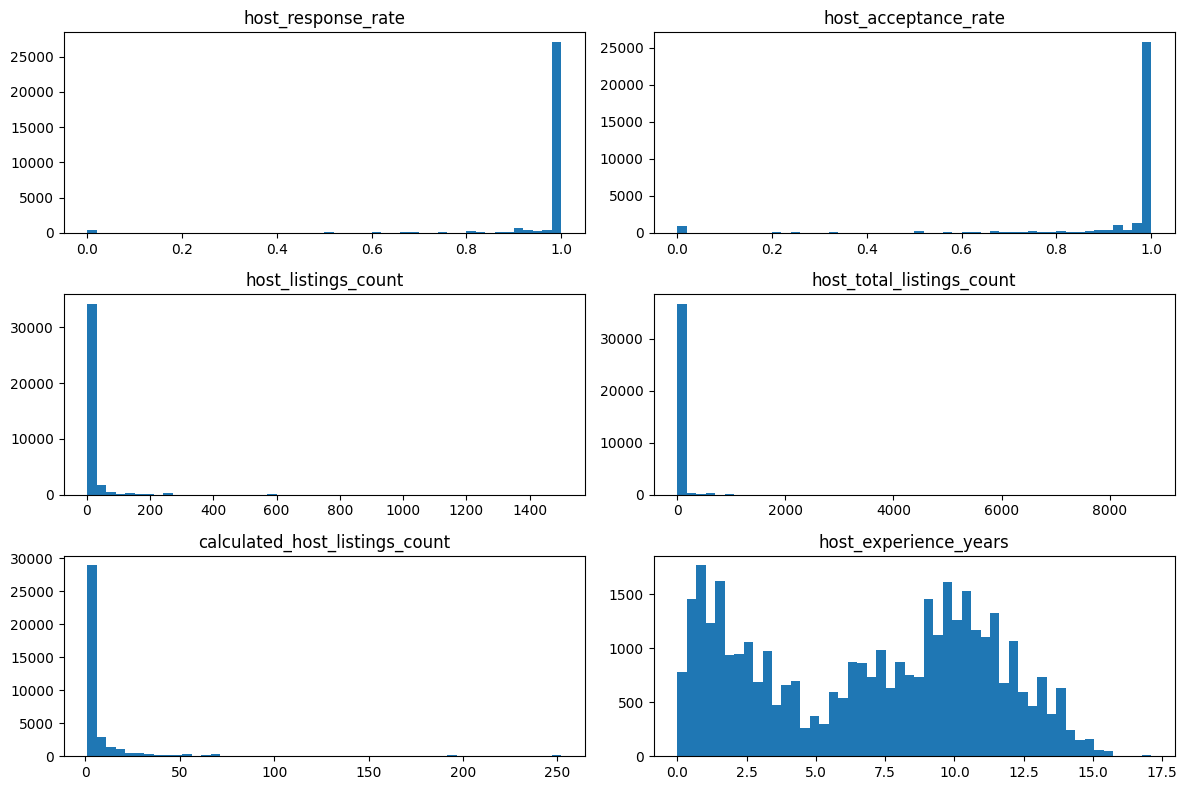

In [42]:
host_behaviour_cols = ['host_response_rate'
                       , 'host_acceptance_rate'
                       , 'host_listings_count'
                       , 'host_total_listings_count'
                       , 'calculated_host_listings_count'
                       , 'host_experience_years']

# histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(host_behaviour_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Observations:**

- **`host_response_rate` & `host_acceptance_rate`**: Both are heavily left-skewed with a massive spike at 1.0 (100%), indicating that the majority of hosts respond and accept almost always. This ceiling effect suggests low discriminative power for segmentation. At the Feature Engineering stage, binarizing (e.g., "responsive host": response_rate > 0.9) or treating as a flag rather than continuous variable should be considered.

- **`host_listings_count` & `host_total_listings_count`**, **`calculated_host_listings_count`**: Strongly right-skewed with a long tail. Most hosts manage 1-10 listings, but a small number of professional hosts manage hundreds. This also may be an anomaly and a severe outlier, which will be investigated further. This distribution is a signal for host type segmentation (casual vs. professional/commercial host). May require transformation (e.g., log scaling) before clustering due to heavy skewness.. At the Feature Engineering stage, creating a categorical variable (e.g., solo host / small operator / commercial operator) should be considered.

- **`host_experience_years`**: Values range from 0 to 17 years, suggesting a mix of relatively new and long-established hosts. May be a useful feature for distinguishing established vs. newer listings. This variable potentially should be discretized into experience buckets at Feature Engineering stage.

- Property variables

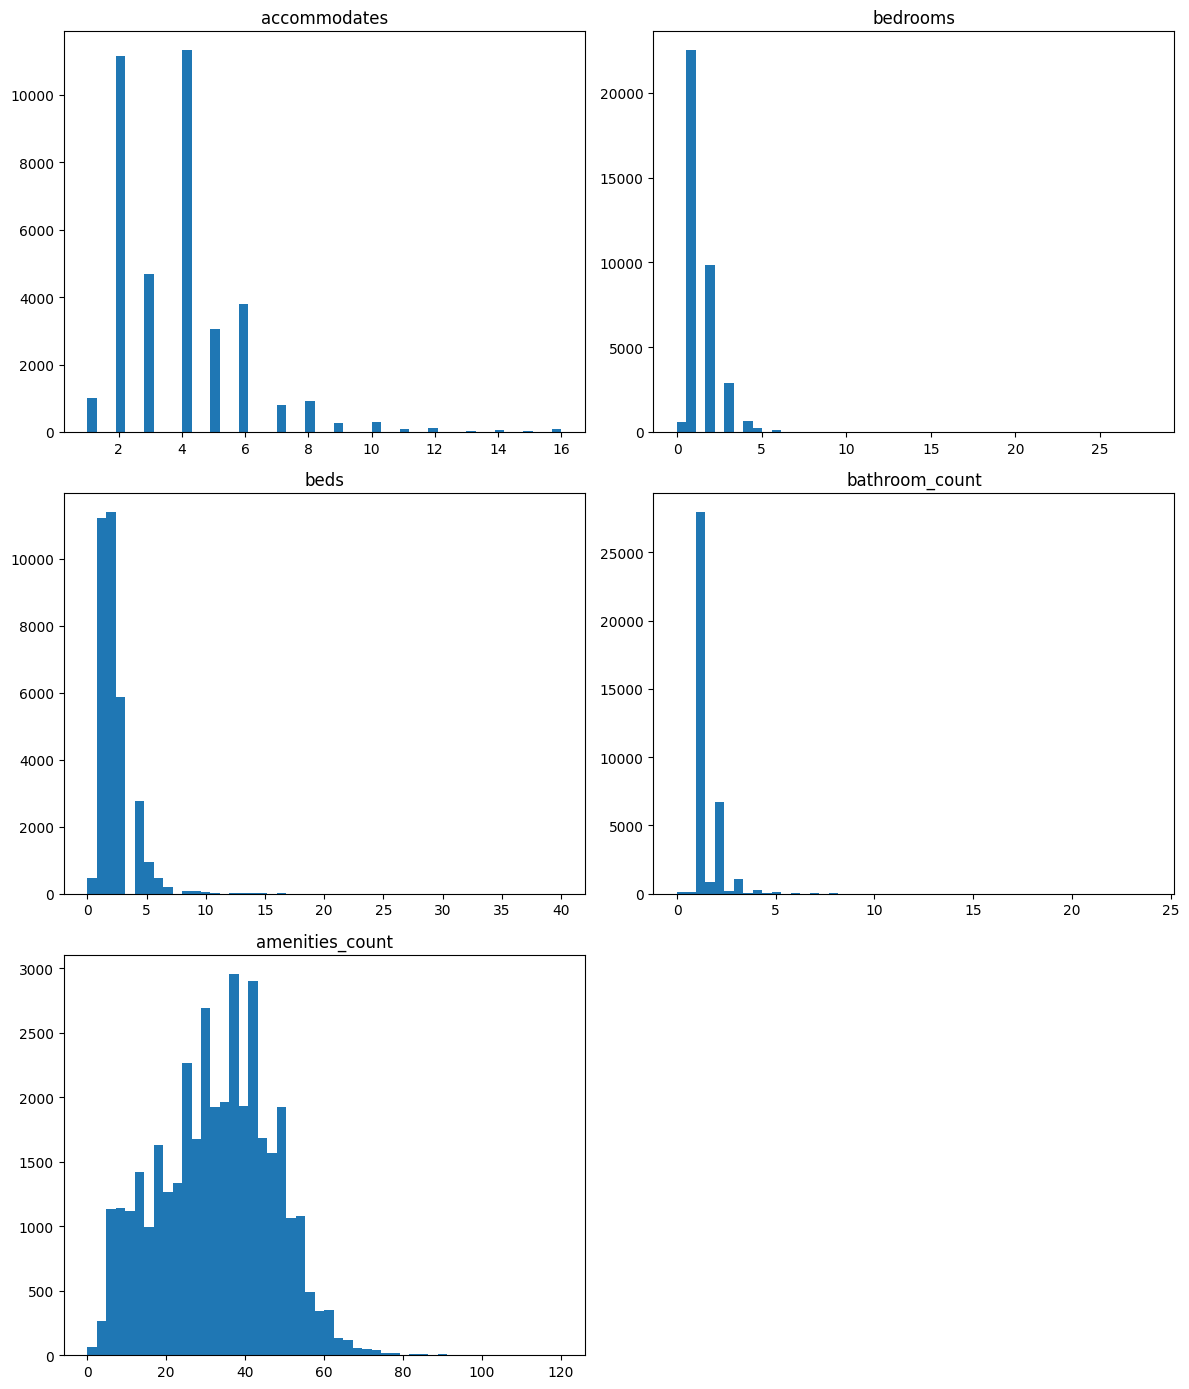

In [43]:
property_cols = ['accommodates'
                 , 'bedrooms'
                 , 'beds'
                 , 'bathroom_count'
                 , 'amenities_count']

# histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()
for i, col in enumerate(property_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=50)
    axes[i].set_title(col)
    
axes[-1].axis('off')

plt.tight_layout()
plt.show()

**Observations:**

- **`accommodates`**: Right-skewed with most listings accommodating 2–5 guests. Tail extends to 16, indicating some large group/villa-type properties. Could be binned into capacity tiers (e.g. solo/couple, small group, large group) at the Feature Engineering stage.

- **`bedrooms`**: Right-skewed, majority are 1- or 2-bedroom listings. A small number of large properties with many bedrooms will likely be outliers. 

- **`beds`**: Similar pattern to `accommodates`. Right-skewed, potentially high correlated with `accommodates`.

- **`bathroom_count`**: Right-skewed, mostly 1–2 bathrooms. Outliers (e.g., 24 bathrooms) are likely caused by system errors or human factor.

- **`amenities_count`**: Approximately bell-shaped with mild right skewness and several high-end outliers, should be investigated and standardized.

- Price column

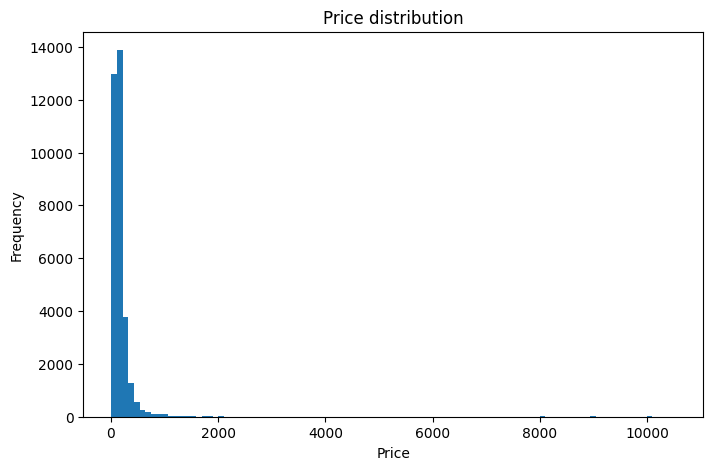

In [44]:
plt.figure(figsize=(8,5))
plt.hist(listings_cleaned['price'].dropna(), bins=100)
plt.title('Price distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Observations:**

**`price`**: Extremely right-skewed with a long tail. Most listings are concentrated in the lower price range, but extreme outliers exist. Those may be luxury villas, etc., which might be a separate cluster.

- Availability & booking constraints

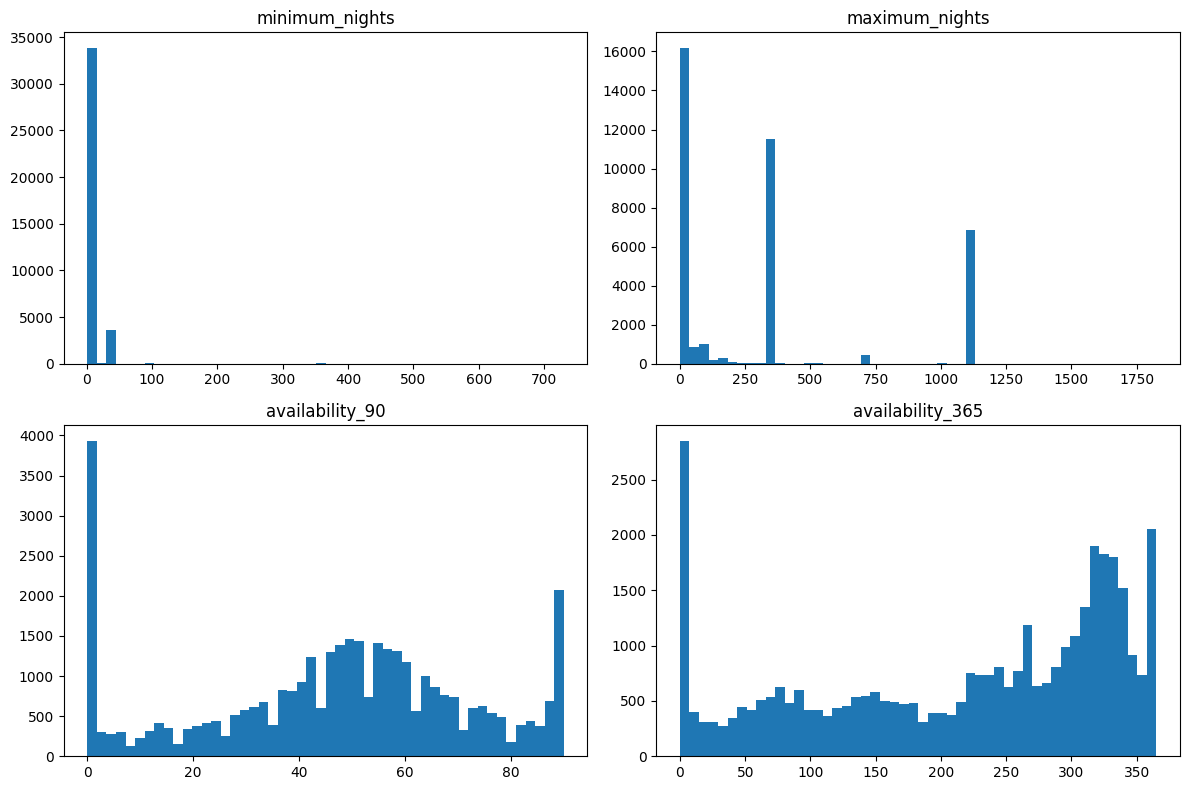

In [45]:
availability_cols = ['minimum_nights'
                      , 'maximum_nights'
                      , 'availability_90'
                      , 'availability_365']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(availability_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Observations:**

- **`minimum_nights`**: Extremely right-skewed — most listings require 1–3 nights minimum, but extreme values (up to 730 nights) indicate long-term rental listings mixed into the dataset. This is an important segmentation signal: short-term tourist rentals vs. long-term housing. Capping at FE stage or creating a binary flag for long-term rentals should be considered at further stages.

- **`maximum_nights`**: Shows a bimodal-like distribution. The ~365-day spike may reflect a platform default rather than true host intent. Similar to `minimum_nights`, this helps distinguish short-term vs. long-term rental strategies. May benefit from discretization.

- **`availability_90`**: Shows a multimodal distribution with clear peaks near 0 and 90 days, suggesting different booking and availability patterns across listings.

- **`availability_365`**: Shows a multimodal distribution with peaks near 0 and 365 days, indicating distinct listing availability patterns ranging from highly occupied or blocked calendars to nearly fully available listings.

- Demand columns

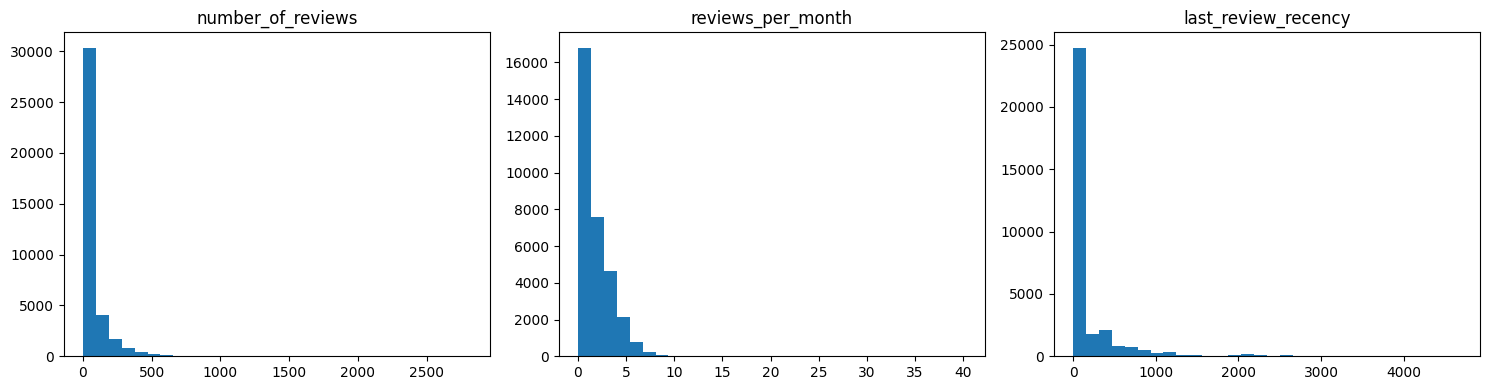

In [46]:
demand_cols = ['number_of_reviews', 'reviews_per_month', 'last_review_recency']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(demand_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Observations:**

- **`number_of_reviews`**: Heavily right-skewed, with a long tail of highly-reviewed listings. Acts as a proxy for listing popularity. Log transformation should be considered at FE stage. Listings with 0 reviews may require separate treatment, as they can represent newly listed, inactive, or low-demand properties.

- **`reviews_per_month`**: Right-skewed, concentrated near 0–3. Extreme values (up to 40) should be investigated during the Outliers Detection stage. This is a strong demand signal. 

- **`last_review_recency`**: Extremely right-skewed — most listings were reviewed recently, but a long tail extends to 4000 days (~13 years), which indicates inactive listings in the dataset. A binary "active listing" flag may be created as a derived feature

- Guest experience columns

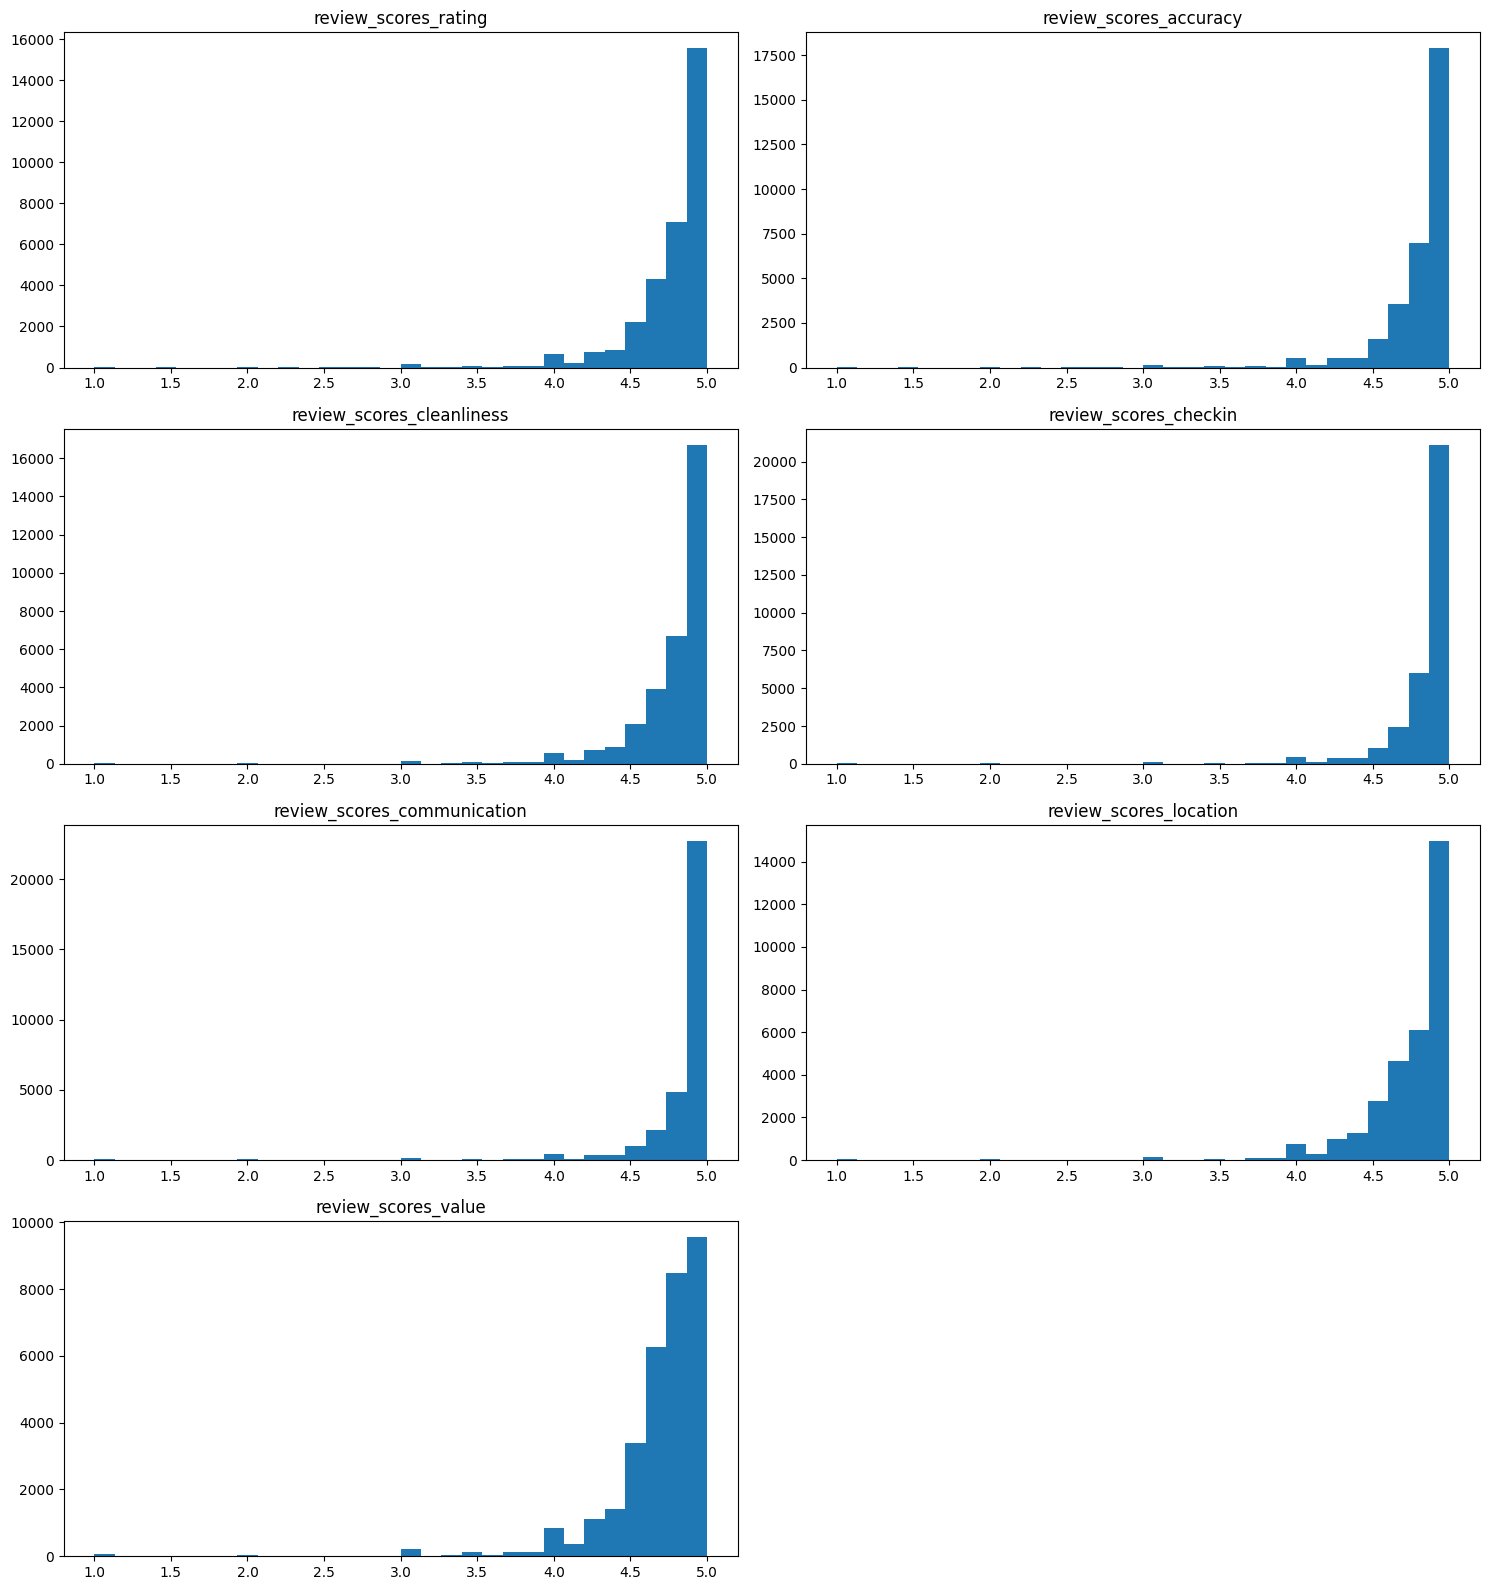

In [47]:
review_cols = ['review_scores_rating'
               , 'review_scores_accuracy'
               , 'review_scores_cleanliness'
               , 'review_scores_checkin'
               , 'review_scores_communication'
               , 'review_scores_location'
               , 'review_scores_value']

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()
for i, col in enumerate(review_cols):
    axes[i].hist(listings_cleaned[col].dropna(), bins=30)
    axes[i].set_title(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Observations:**

- **All review score dimensions** (`rating`, `accuracy`, `cleanliness`, `checkin`, 
  `communication`, `location`, `value`): All are heavily left-skewed with a strong ceiling effect as distributions are clustered near 4.5–5.0 with a sharp drop toward lower values. 

- The low discriminative range means these variables may have limited power in separating clusters when used raw. 
  At the Feature engineering stage, those columns can be transformed by:
    - Computing a **composite review score** as weighted average.
    - Creating binary flags for "high performer" listings.

- `review_scores_value` has a slightly wider spread than others, suggesting guests are more willing to differentiate on perceived value, making it potentially more informative for future analysis.

- Correlations

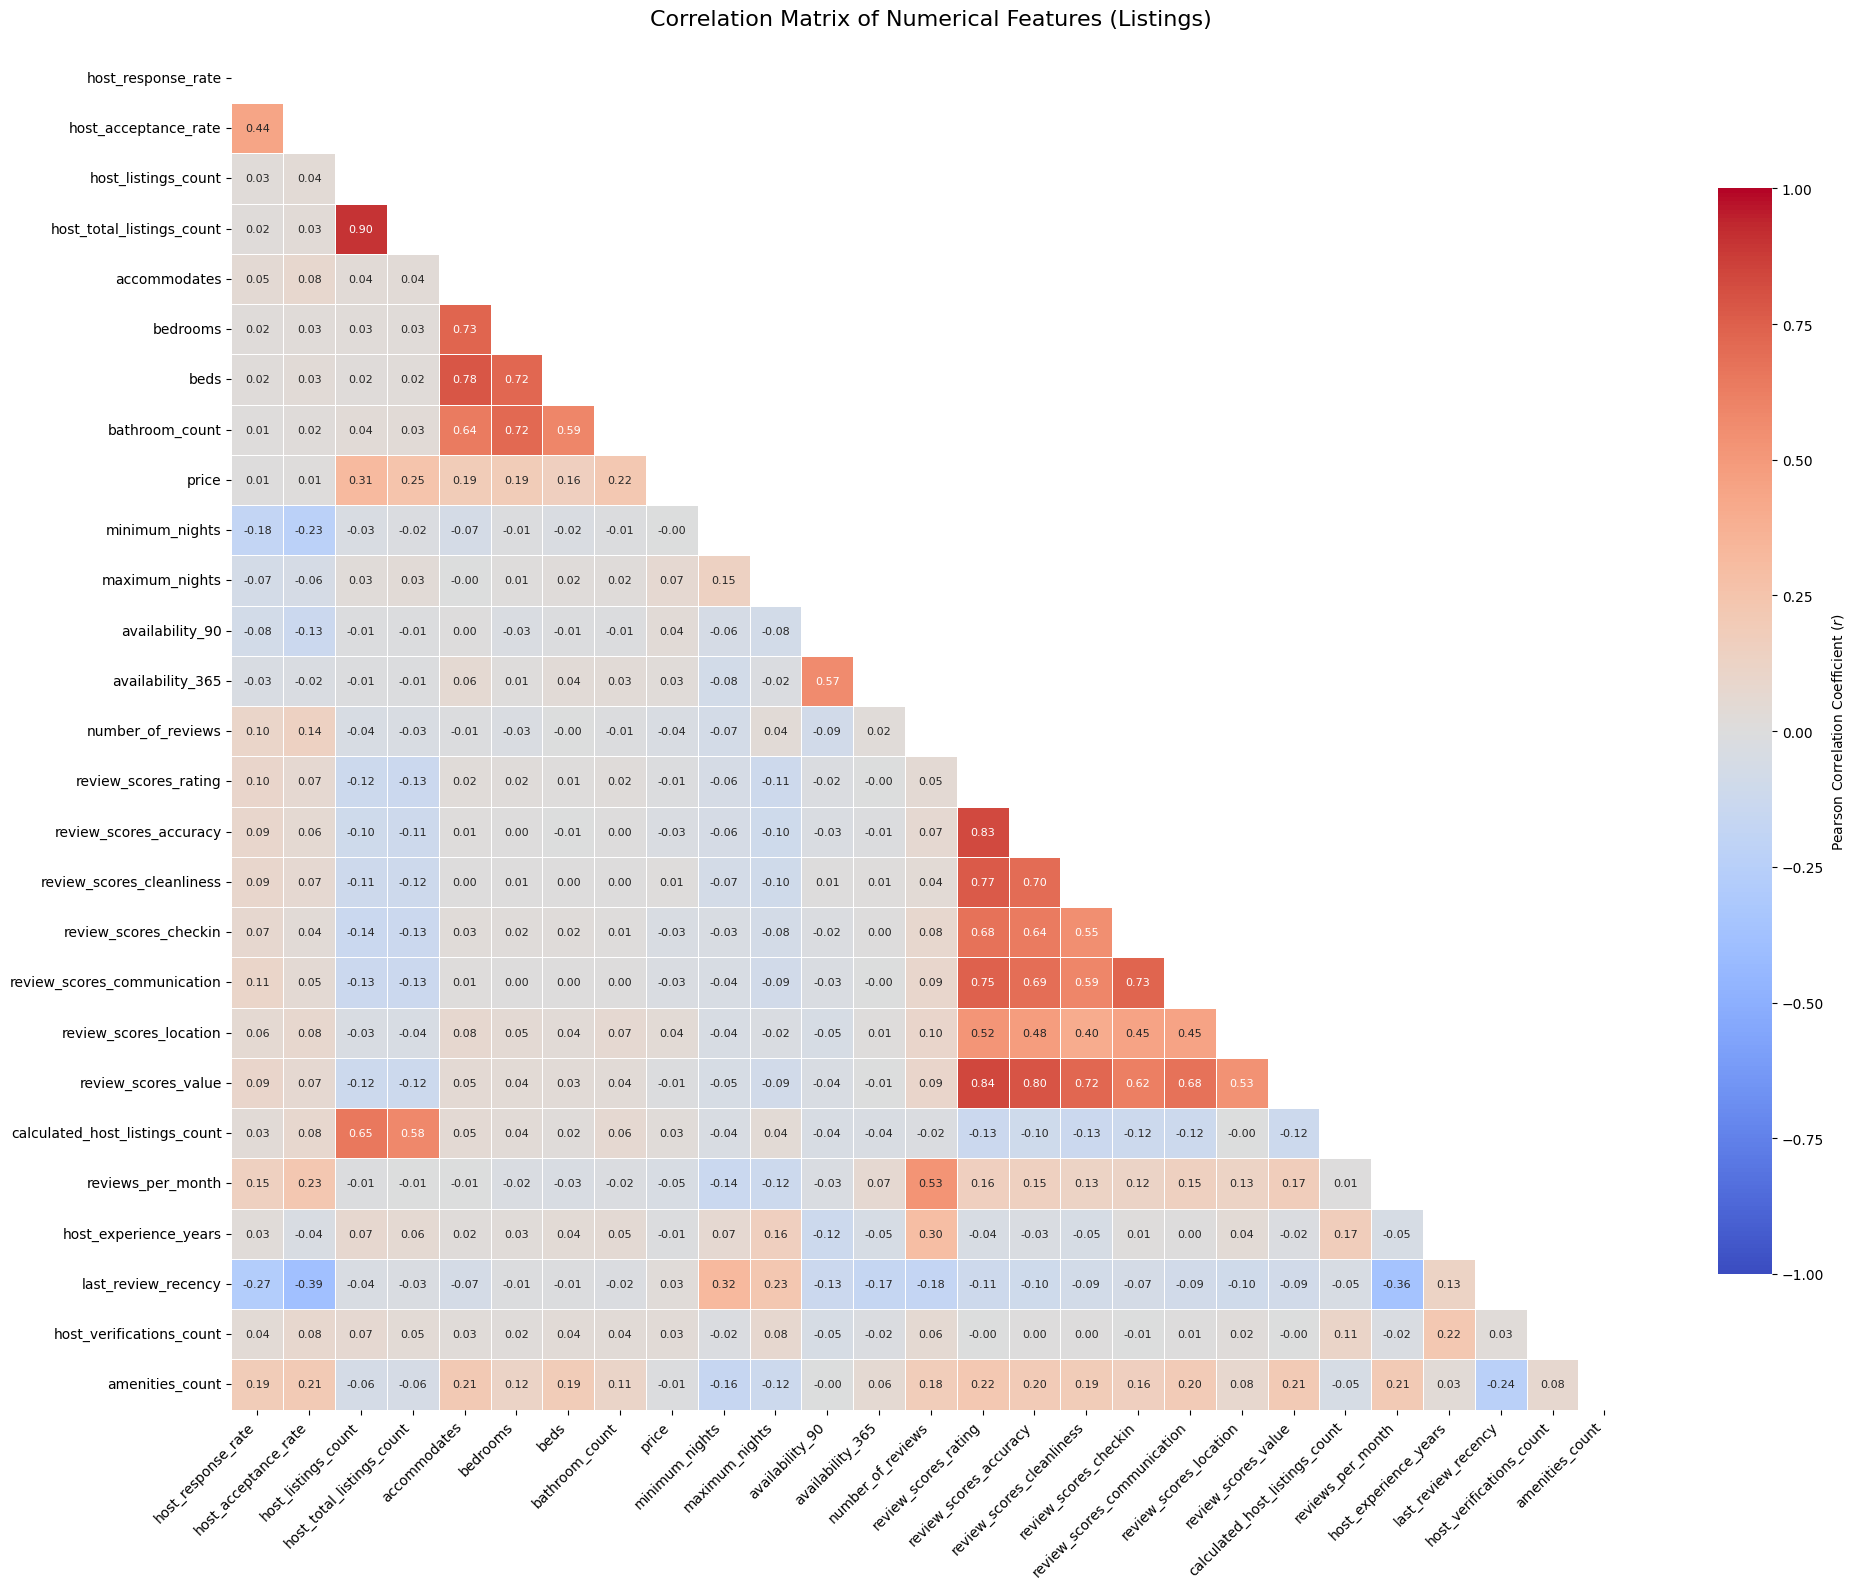

In [48]:
corr_matrix = listings_cleaned[numeric_cols].corr(method='pearson')

# create mask for the top triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=True,       
    fmt=".2f",          
    linewidths=0.5,      
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient ($r$)"},
    annot_kws={"size": 8} 
)

plt.title('Correlation Matrix of Numerical Features (Listings)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**Observations:**

- **Weak and Non-Linear Price Drivers:** The most notable finding is that traditional quality metrics (all review scores) have negligible linear correlation with `price` ($|r| < 0.05$). Price is primarily associated with structural capacity (e.g., `bathroom_count`, $r = 0.22$) and the host's portfolio scale (`host_listings_count`, $r = 0.31$). This confirms that higher ratings do not automatically yield price premiums and suggests that pricing strategies are driven by more complex, non-linear factors (validating the need for NLP-based insights).

- **Severe Multicollinearity in Review Scores:** All review sub-metrics form a tightly interlinked cluster ($r = 0.45 - 0.84$), with `review_scores_rating` acting as the central hub. This "halo effect" implies these features capture a single latent "guest satisfaction" dimension and are highly redundant.
  
- **Redundancy in Capacity and Scale:** Expected multicollinearity exists among physical property metrics (`accommodates`, `bedrooms`, `beds`, `bathroom_count`; $r = 0.59 - 0.78$) and host operational scale (`host_listings_count` and its derivatives; $r = 0.58 - 0.90$).
  
- **Practical Implications:** Given the extreme multicollinearity across reviews, property size, and host scale, feeding these raw variables into distance-based algorithms (like K-Means) will severely distort cluster formation by over-weighting redundant dimensions. Before proceeding to clustering, rigorous feature selection or dimensionality reduction is necessary.

#### 5.1.2 Binary columns

In [49]:
bin_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified'
            , 'host_verification_work_email', 'no_valid_license'
            , 'instant_bookable'
            , 'bath_private_info', 'bath_shared_info', 'has_top5_amenity', 'has_outdoor_leisure', 'has_fireplace'
            , 'has_hot_tub', 'has_bbq', 'has_gym'
            ]

- Stats overview

In [50]:
binary_stats = pd.DataFrame({
    'count_1': listings_cleaned[bin_cols].sum(),
    'count_0': listings_cleaned[bin_cols].shape[0] - listings_cleaned[bin_cols].sum(),
    'pct_1': (listings_cleaned[bin_cols].mean() * 100).round(2),
    'pct_0': (100 - listings_cleaned[bin_cols].mean() * 100).round(2)
})

binary_stats.sort_values('pct_1', ascending=False)

,count_1,count_0,pct_1,pct_0
host_has_profile_pic,35445,2207,94.16,5.84
host_identity_verified,34564,3088,91.82,8.18
instant_bookable,22855,14797,60.7,39.3
host_is_superhost,13722,23930,38.7,61.3
bath_private_info,6289,31363,16.7,83.3
has_top5_amenity,4079,33573,10.83,89.17
no_valid_license,3400,34252,9.03,90.97
host_verification_work_email,2742,34910,7.28,92.72
bath_shared_info,1821,35831,4.84,95.16
has_outdoor_leisure,1378,36274,3.66,96.34


- Host information columns

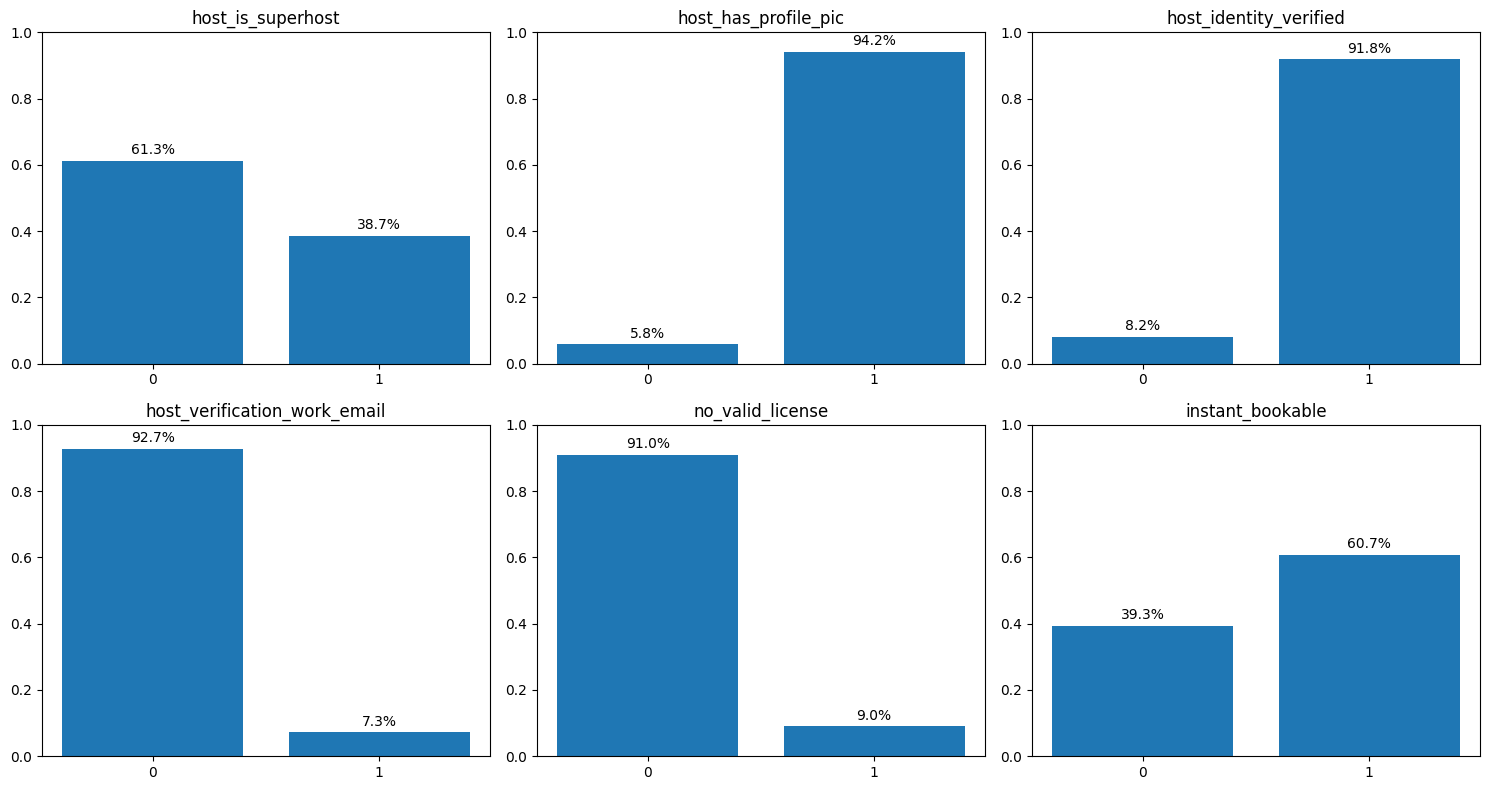

In [51]:
host_info_cols = ['host_is_superhost'
                  , 'host_has_profile_pic'
                  , 'host_identity_verified'
                  , 'host_verification_work_email'
                  , 'no_valid_license'
                  , 'instant_bookable']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(host_info_cols):
    dist = listings_cleaned[col].value_counts(normalize=True).reindex([0, 1]).fillna(0)
    axes[i].bar(['0', '1'], dist.values)
    axes[i].set_title(col)
    axes[i].set_ylim(0, 1)

    for j, v in enumerate(dist.values):
        axes[i].text(
            j,
            v + 0.02,
            f"{v * 100:.1f}%",
            ha='center',
            fontsize=10
        )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observations**:
* **Near-homogeneous features (low variance)**

`host_has_profile_pic` and `host_identity_verified`  show extremely high prevalence across the dataset, indicating that basic identity and profile completeness requirements are almost universally satisfied among hosts.

These variables exhibit strong ceiling effects and very low variance. As a result, they are expected to provide limited discriminatory power for clustering-based segmentation, as they do not meaningfully differentiate between listings.

* **Sparse but high-signal features**

`host_verification_work_email` and `no_valid_license` capture rare but structurally meaningful signals despite their strong class imbalance. A verified work email is indicative of professional host management (e.g., agencies or commercial operators), while missing or invalid licensing information may reflect regulatory non-compliance or incomplete registration.

* **Balanced behavioral differentiators**

`instant_bookable` and `host_is_superhost` exhibit relatively balanced distributions and reflect meaningful differences in host behavior.

- Bath structure information

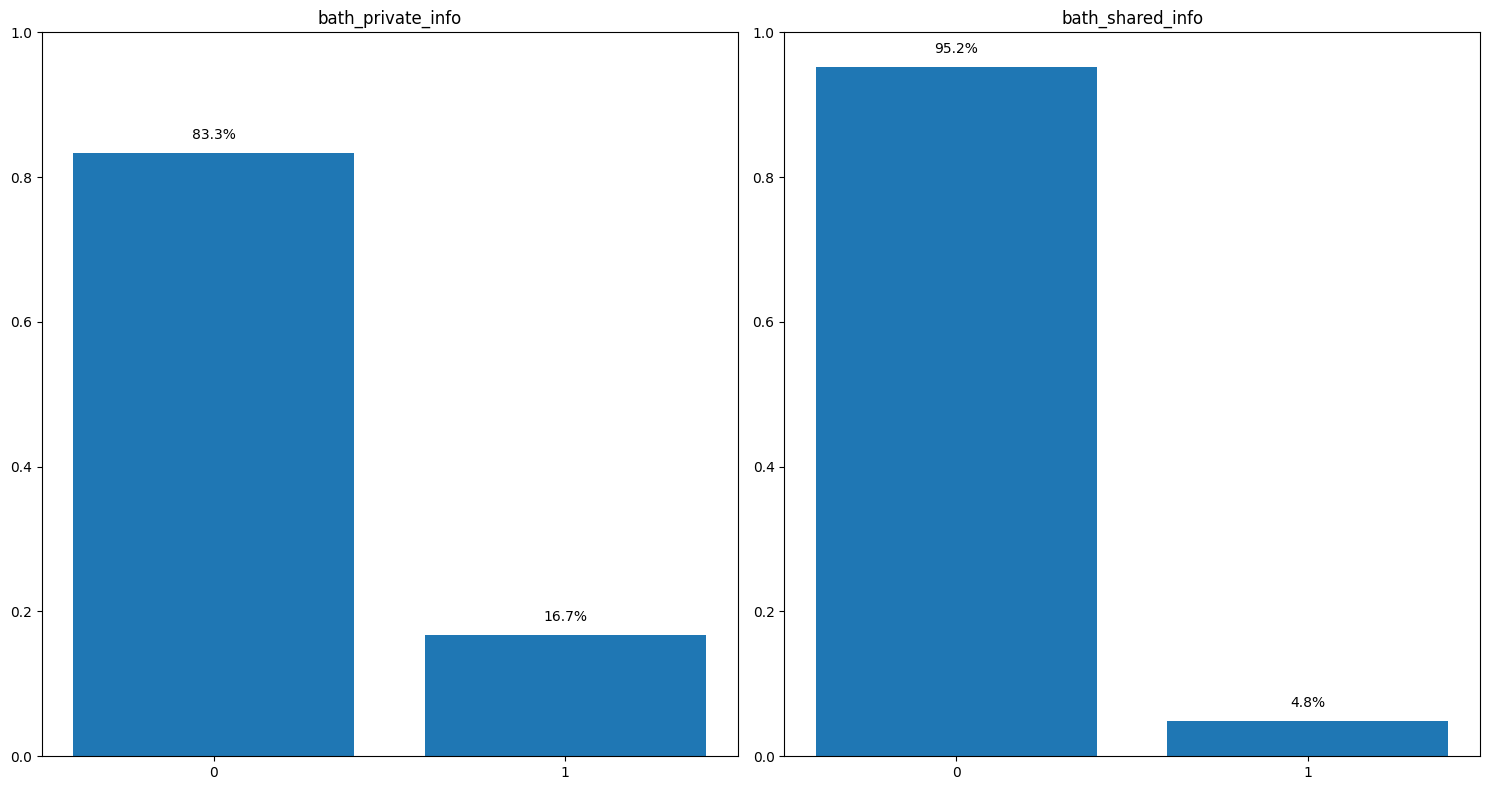

In [52]:
bath_cols = ['bath_private_info', 'bath_shared_info']

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(bath_cols):
    dist = listings_cleaned[col].value_counts(normalize=True).reindex([0, 1]).fillna(0)
    axes[i].bar(['0', '1'], dist.values)
    axes[i].set_title(col)
    axes[i].set_ylim(0, 1)

    for j, v in enumerate(dist.values):
        axes[i].text(
            j,
            v + 0.02,
            f"{v * 100:.1f}%",
            ha='center',
            fontsize=10
        )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observations:**
* **Explicit shared bathrooms**

`bath_shared_info` is present in only a very small fraction of listings, indicating that explicitly shared bathroom configurations are relatively rare in the dataset. Despite its low frequency, this is a high-signal structural feature and likely represents a strong downward pricing driver and is expected to concentrate within budget-oriented segments such as private rooms, shared accommodations, or hostel-like listings

* **Explicit private bathrooms**

`bath_private_info` appears in a relatively small subset of listings and is likely to be a weaker pricing driver compared to the `bath_shared_info` columns.

- Amenities

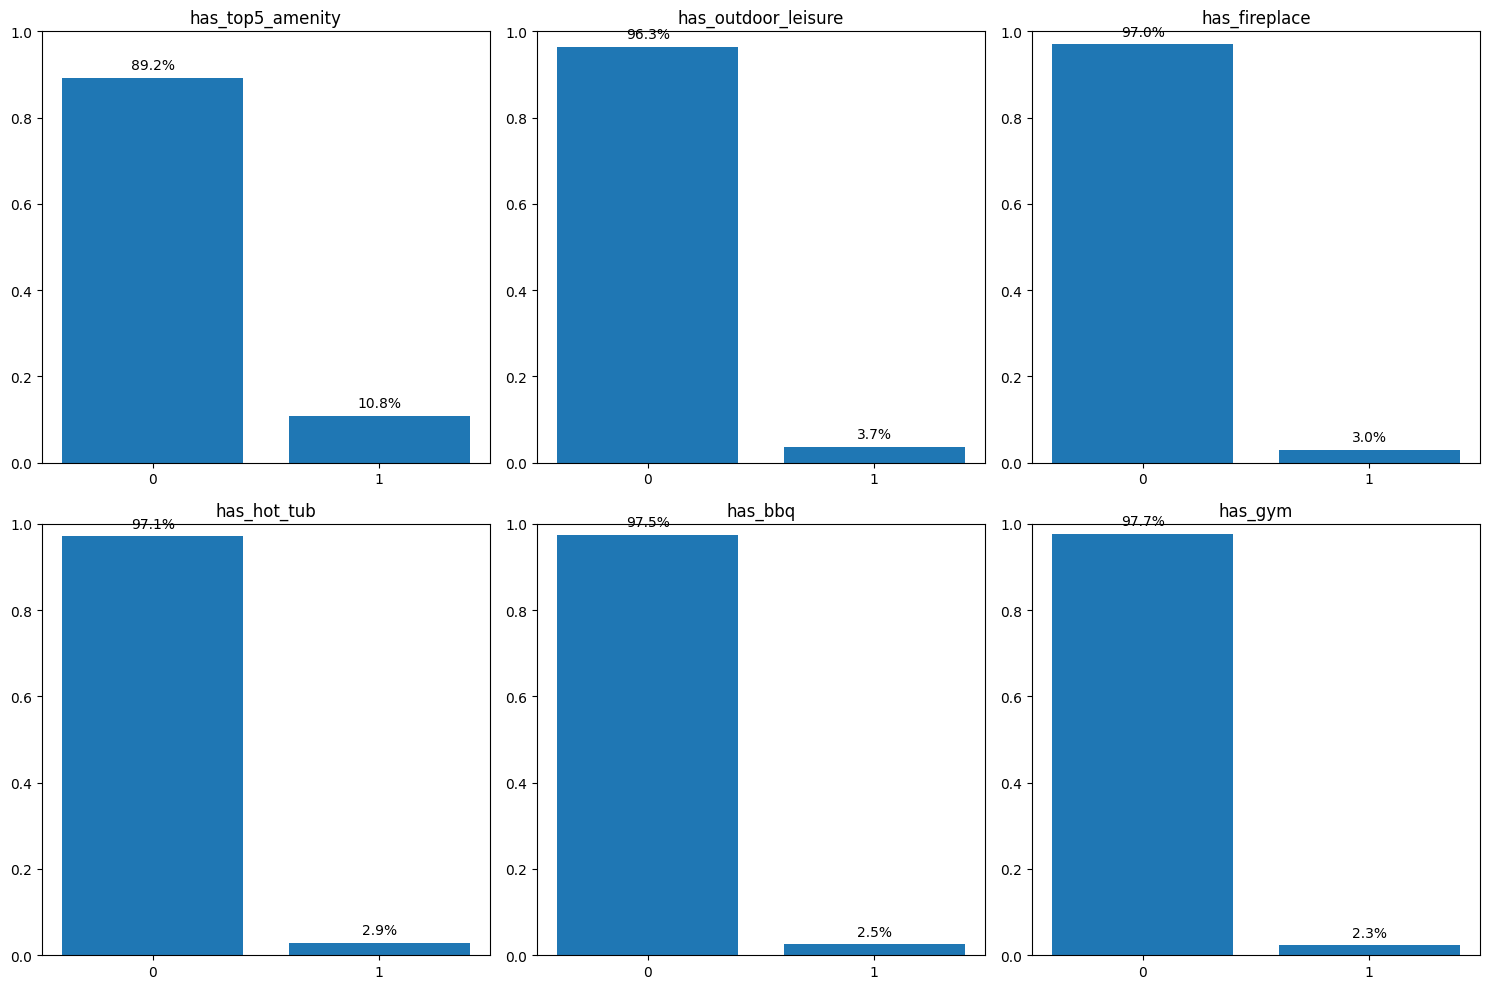

In [53]:
amenities_cols = ['has_top5_amenity', 'has_outdoor_leisure', 'has_fireplace'
                  , 'has_hot_tub', 'has_bbq', 'has_gym']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(amenities_cols):
    dist = listings_cleaned[col].value_counts(normalize=True).reindex([0, 1]).fillna(0)
    axes[i].bar(['0', '1'], dist.values)
    axes[i].set_title(col)
    axes[i].set_ylim(0, 1)

    for j, v in enumerate(dist.values):
        axes[i].text(
            j,
            v + 0.02,
            f"{v * 100:.1f}%",
            ha='center',
            fontsize=10
        )

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observations:**
- `has_top5_amenity` is highly selective at 10.8%, confirming it functions as a genuine ultra-premium indicator rather than a mid-level quality threshold, as only about one in ten listings offers any of five luxury amenities.

- `has_outdoor_leisure` and `has_fireplace` are the most common of the five (3.7% and 3.0%), representing leisure-oriented and cozy/atmospheric additions to a property.

- `has_hot_tub`, `has_bbq`, and `has_gym` are the rarest (2.3–2.9%), each carrying disproportionate semantic importance despite their low prevalence. Together with the other two, they mark the small, exclusive segment of listings offering resort-style or leisure-focused amenities, distinct from the standard residential stay.

#### 5.1.3 Categorical columns

In [54]:
cat_cols_listings = ['neighbourhood_cleansed'
                     , 'host_response_time'
                     , 'property_type', 'room_type']

- Stats overview

In [55]:
cat_stats = pd.DataFrame({
    'n_unique': listings_cleaned[cat_cols_listings].nunique(),
    'top_category': listings_cleaned[cat_cols_listings].mode().iloc[0],
    'top_freq': listings_cleaned[cat_cols_listings].apply(
        lambda x: x.value_counts(dropna=False).iloc[0]
    ),
    'top_freq_pct': listings_cleaned[cat_cols_listings].apply(
        lambda x: round(x.value_counts(normalize=True, dropna=False).iloc[0] * 100, 2)
    ),
    'missing_count': listings_cleaned[cat_cols_listings].isna().sum(),
    'missing_pct': round(listings_cleaned[cat_cols_listings].isna().mean() * 100, 2)
})

cat_stats.sort_values('n_unique', ascending=False)

,n_unique,top_category,top_freq,top_freq_pct,missing_count,missing_pct
property_type,63,Entire rental unit,18832,50.02,0,0.00
neighbourhood_cleansed,15,I Centro Storico,18563,49.30,0,0.00
host_response_time,4,within an hour,26249,69.71,6791,18.04
room_type,4,Entire home/apt,28294,75.15,0,0.00


- Location & Host Behavior

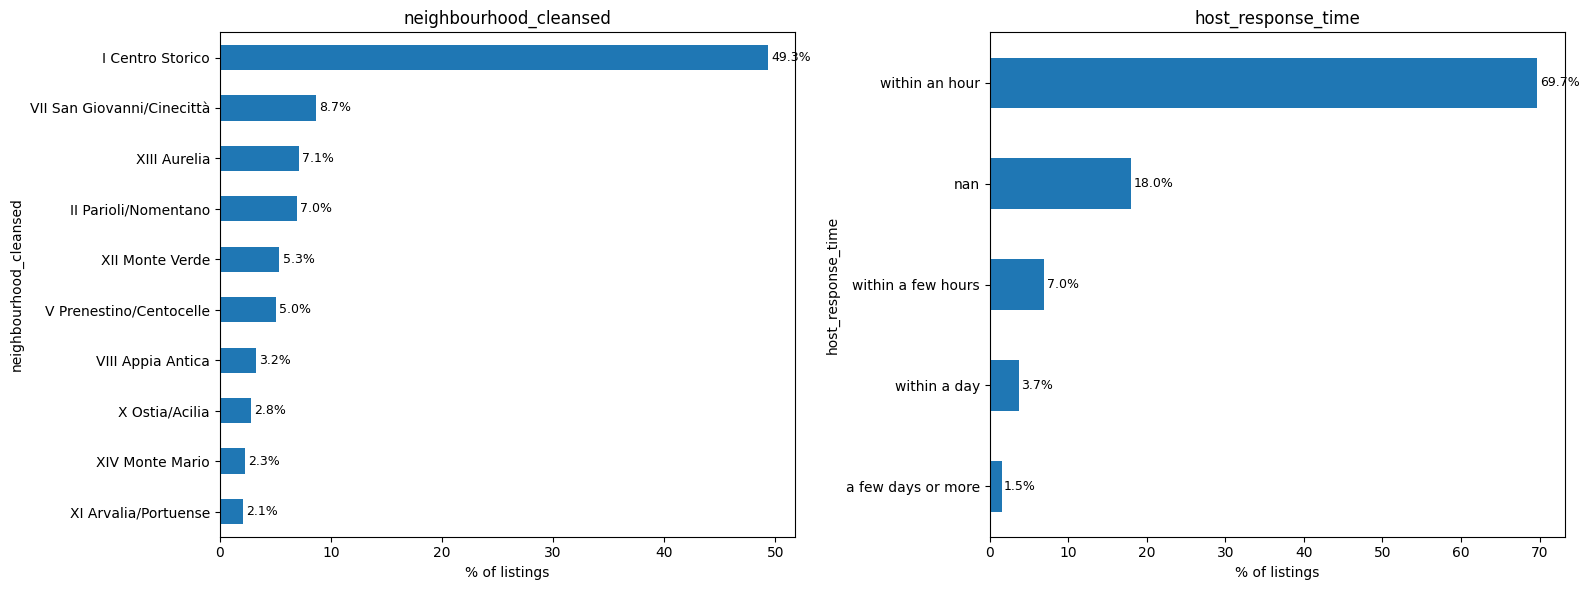

In [56]:
loc_host_cols = ['neighbourhood_cleansed', 'host_response_time']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(loc_host_cols):

    vc = listings_cleaned[col].value_counts(normalize=True, dropna = False) * 100
    vc_top = vc.head(10).sort_values(ascending=True)

    vc_top.plot(
        kind='barh',
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("% of listings")

    for j, v in enumerate(vc_top.values):
        axes[i].text(
            v + 0.3,
            j,
            f"{v:.1f}%",
            va='center',
            fontsize=9
        )

plt.tight_layout()
plt.show()

**Observations:**

- `neighbourhood_cleansed`: Almost half of the market is located in *I Centro Storico*, while the rest is heavily fragmented across 14 districts with a steep drop-off. This indicates a strong “core vs periphery” spatial hierarchy rather than a smooth geographic distribution. Keeping all categories would introduce sparsity and distort distance-based clustering, so at the feature engineering stage collapsing into broader macro-location tiers should be considered, with very low-frequency areas grouped into an “Other” class.

- `host_response_time`: Host communication is strongly skewed toward fast responses. At the same time, a significant share of missing values appears. Missing values should be treated as a separate “unknown” category since they likely reflect a meaningful behavioral segment of inactive or low-engagement hosts rather than random noise. In addition, rare slow-response categories should be merged into a single group to improve clustering stability.

- Accommodation Structure

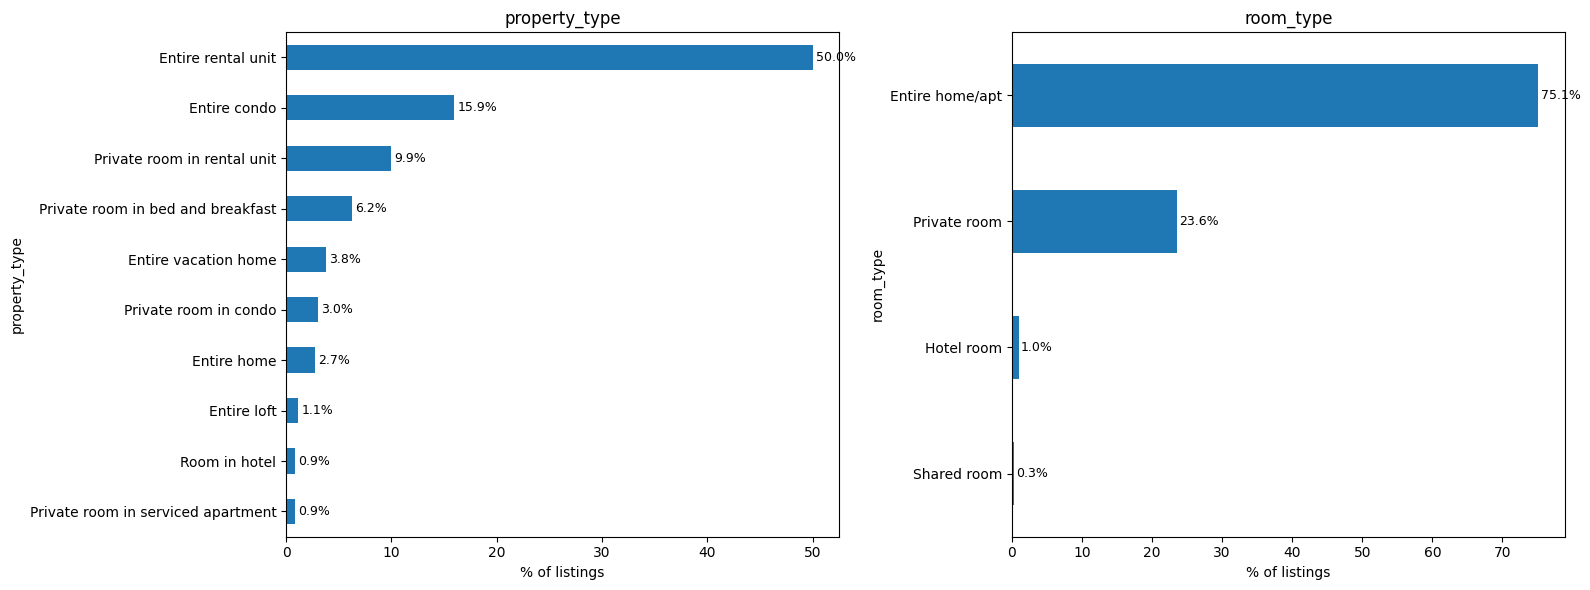

In [57]:
acc_cols = ['property_type', 'room_type']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(acc_cols):
    vc = listings_cleaned[col].value_counts(normalize=True, dropna = False) * 100
    vc_top = vc.head(10).sort_values(ascending=True)

    vc_top.plot(
        kind='barh',
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("% of listings")

    for j, v in enumerate(vc_top.values):
        axes[i].text(
            v + 0.3,
            j,
            f"{v:.1f}%",
            va='center',
            fontsize=9
        )

plt.tight_layout()
plt.show()

**Observations:**

- `property_type`: Despite 63 apparent categories, the distribution is heavily concentrated in a few dominant types, while the long tail is largely sparse and noisy, and this apparent diversity is further inflated by multilingual and semantically duplicate labels. At the feature engineering stage, this feature should be normalized to account for language variation and redundancy, then collapsed into a small set of macro asset classes to reduce dimensionality, improve interpretability, and retain only economically meaningful structure.

- `room_type`: The market is almost entirely concentrated in Entire home/apt and Private room, which together define the core structure of the dataset, while Hotel room and Shared room form a long tail. This variable captures the fundamental split between full-unit and shared-space economics and is one of the strongest segmentation drivers. To ensure stable clustering, the rare categories should be merged into an “Other” group instead of being treated as standalone classes.

### 5.2 Reviews dataframe

- Number of reviews per `listing_id`

In [58]:
reviews_df_counts = reviews_cleaned['listing_id'].value_counts()

listings_df_counts = listings_cleaned.set_index('id')['number_of_reviews']

comparison = pd.DataFrame({
    'Actual_Count': reviews_df_counts,
    'Listed_Count': listings_df_counts
}).fillna(0) 

diff = comparison[comparison['Actual_Count'] != comparison['Listed_Count']]

print(f"Total listings in 'listings' dataset: {len(listings_df_counts)}")
print(f"Listings with discrepancies: {len(diff)}")

if len(diff) > 0:
    print(f"Discrepancy detected in {len(diff)/len(listings_df_counts)*100:.1f}% of listings.")
else:
    print("Success: Data is perfectly consistent.")

Total listings in 'listings' dataset: 37652
Listings with discrepancies: 162
Discrepancy detected in 0.4% of listings.


In [59]:
# check the missing listing_id in the reviews dataframe

reviews_count_df = reviews_cleaned['listing_id'].value_counts().reset_index()
reviews_count_df.columns = ['id', 'actual_review_count']

test_df = listings_cleaned[['id']].merge(reviews_count_df, on='id', how='left')

missing_pct = test_df['actual_review_count'].isna().mean() * 100

original_zeros_pct = (listings_cleaned['number_of_reviews'] == 0).mean() * 100

print(f"Percentage of missing values in test merge: {missing_pct:.2f}%")
print(f"Percentage of listings with 0 reviews in original dataset: {original_zeros_pct:.2f}%")

Percentage of missing values in test merge: 14.33%
Percentage of listings with 0 reviews in original dataset: 14.33%


In [60]:
# check if missing listing_ids are the listings that have 0 reviews in the listings dataframe

missing_ids = set(test_df[test_df['actual_review_count'].isna()]['id'])
original_zero_ids = set(listings_cleaned[listings_cleaned['number_of_reviews'] == 0]['id'])

are_identical = missing_ids == original_zero_ids
print(f"Are the missing IDs and original zero-review IDs perfectly identical? {are_identical}")

if not are_identical:
    print(f"Total missing IDs from merge: {len(missing_ids)}")
    print(f"Total original zero-review IDs: {len(original_zero_ids)}")
    print(f"Intersection (common IDs): {len(missing_ids.intersection(original_zero_ids))}")

Are the missing IDs and original zero-review IDs perfectly identical? True


In [61]:
# replace the number_od_reviews column in the listings dataframe with the actual number of reviews for listing_ids

test_df['actual_review_count'] = test_df['actual_review_count'].fillna(0).astype(int)

listings_cleaned['number_of_reviews'] = test_df['actual_review_count']

**Data Consistency Check:**

A validation between the `listings` dataset metadata and the raw `reviews` content was performed to ensure data integrity. The analysis revealed a high degree of consistency, with discrepancies identified in only 0.4% of cases. 
* Given the negligible impact, the granular count derived directly from the `reviews` dataset will be used as the 'ground truth' for all subsequent text-based feature engineering. This ensures that the review-frequency features used in the clustering pipeline are aligned with the actual volume of available text data per listing.

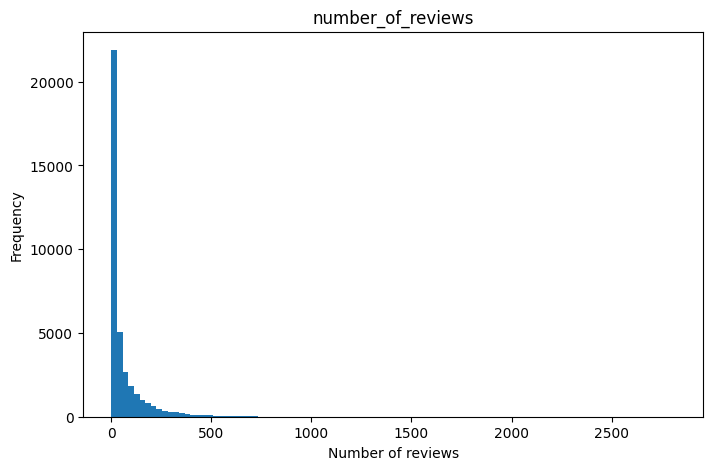

In [62]:
plt.figure(figsize=(8,5))
plt.hist(listings_cleaned['number_of_reviews'].dropna(), bins=100)
plt.title('number_of_reviews')
plt.xlabel('Number of reviews')
plt.ylabel('Frequency')
plt.show()

The replacement of `number_of_reviews` with the count derived directly from the `reviews` dataset has been completed. This substitution has not altered the fundamentally right-skewed distribution of the variable.

- Length of reviews

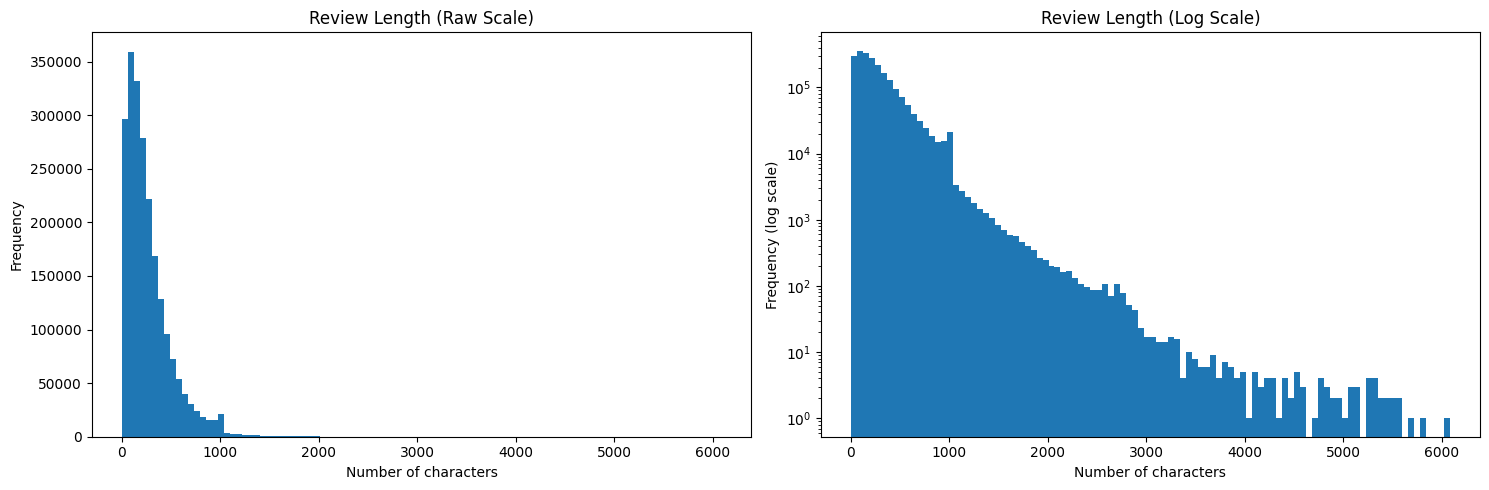

In [63]:
reviews_cleaned['review_length'] = reviews_cleaned['comments_clean'].str.len()

# comments that were replaced with the "unknown" placeholder were originally treated as junk,
# so their length should be 0, not len("unknown") == 7
reviews_cleaned.loc[reviews_cleaned['comments_clean'] == 'unknown', 'review_length'] = 0


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# raw scale
axes[0].hist(reviews_cleaned['review_length'].dropna(), bins=100)
axes[0].set_title('Review Length (Raw Scale)')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Frequency')

# log scale
axes[1].hist(reviews_cleaned['review_length'].dropna(), bins=100)
axes[1].set_title('Review Length (Log Scale)')
axes[1].set_xlabel('Number of characters')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

**Observations:**

The review length distribution is heavily right-skewed. The raw scale is dominated by short reviews, while the log-scale reveals a long tail with a notable frequency spike near 1,000 characters.

- Average and median review length per listing_id

In [64]:
# calculate statistics

listing_lengths = reviews_cleaned.groupby('listing_id')['review_length'].agg(
    avg_review_length='mean', 
    median_review_length='median'
)

listings_cleaned = listings_cleaned.merge(listing_lengths, left_on='id', right_index=True, how='left')

listings_cleaned[['avg_review_length', 'median_review_length']] = listings_cleaned[['avg_review_length', 'median_review_length']].fillna(0)

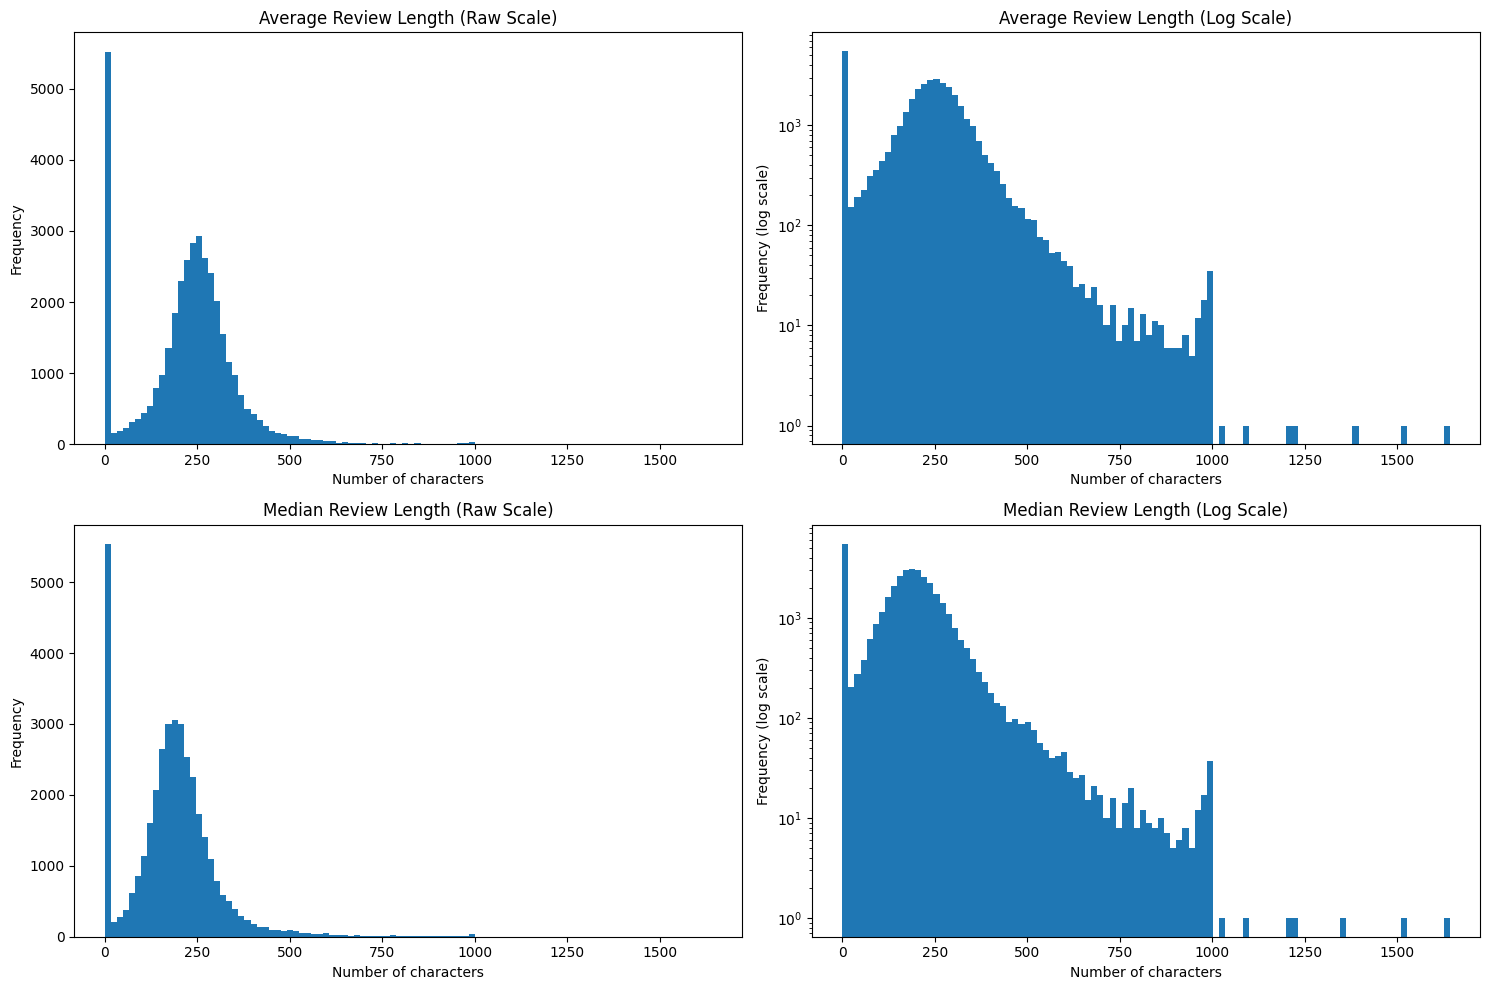

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = [('avg_review_length', 'Average'), ('median_review_length', 'Median')]

for i, (col, title) in enumerate(metrics):
    # Raw Scale
    axes[i, 0].hist(listings_cleaned[col].dropna(), bins=100)
    axes[i, 0].set_title(f'{title} Review Length (Raw Scale)')
    axes[i, 0].set_xlabel('Number of characters')
    axes[i, 0].set_ylabel('Frequency')
    
    # Log Scale
    axes[i, 1].hist(listings_cleaned[col].dropna(), bins=100)
    axes[i, 1].set_title(f'{title} Review Length (Log Scale)')
    axes[i, 1].set_xlabel('Number of characters')
    axes[i, 1].set_ylabel('Frequency (log scale)')
    axes[i, 1].set_yscale('log')

plt.tight_layout()
plt.show()

**Observations**:

Aggregated review length distributions reveal a stable pattern: the typical listing features feedback averaging 200–300 characters. The similarity between mean and median plots indicates low intra-listing variance, suggesting that "typical review length" is a robust characteristic. While the zero-spike highlights a subgroup of inactive or brief-review listings, the right tail identifies properties that consistently attract detailed feedback, likely reflecting unique guest experiences.

## 6. Outliers Diagnosis & Handling

In this section, only **extreme values** and **data entry errors** will be identified and addressed. Since the subsequent analysis relies on clustering techniques, which are particularly sensitive to outliers, it is essential to establish strict data-cleaning criteria. Furthermore, applying the standard IQR method may be inappropriate, as it could remove observations belonging to valid but small market segments that are intended to be preserved in the dataset.

In [66]:
listings_cleaned[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
host_response_rate,30861.0,0.965777,0.139221,0.00,1.00,1.00,1.00,1.00
host_acceptance_rate,33814.0,0.924862,0.205377,0.00,0.98,1.00,1.00,1.00
host_listings_count,37643.0,16.116542,67.549298,1.00,1.00,3.00,7.00,1500.00
host_total_listings_count,37643.0,24.237999,130.416357,1.00,1.00,3.00,9.00,8768.00
accommodates,37652.0,3.820780,1.991687,1.00,2.00,4.00,5.00,16.00
bedrooms,36804.0,1.508640,0.896519,0.00,1.00,1.00,2.00,28.00
beds,33638.0,2.215590,1.469154,0.00,1.00,2.00,3.00,40.00
bathroom_count,37618.0,1.306582,0.691390,0.00,1.00,1.00,1.50,24.00
price,33564.0,197.328000,443.190521,8.00,93.00,133.00,195.25,10515.00
minimum_nights,37652.0,5.389939,16.623835,1.00,1.00,2.00,3.00,730.00


- helper function to identify outliers

In [67]:
def diagnose_outliers(df, columns, group_name=""):
    """
    Plots boxplots and calculates extreme percentiles for selected columns.
    """
    fig, axes = plt.subplots(1, len(columns), figsize=(2.8 * len(columns), 5))
    
    if len(columns) == 1:
        axes = [axes]
        
    for i, col in enumerate(columns):
        sns.boxplot(
            y=df[col].dropna(), 
            ax=axes[i], 
            color='lightblue', 
            flierprops={'marker': '.', 'color': 'red', 'alpha': 0.5}
        )
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('') 
        
    plt.suptitle(f'Outlier Diagnosis: {group_name}', y=1.05, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    percentiles = [0.01, 0.05, 0.50, 0.75, 0.90, 0.95, 0.99]
    stats = df[columns].describe(percentiles=percentiles).T
    stats = stats[['mean', 'min', '1%', '5%', '50%','75%', '90%', '95%', '99%', 'max']]
    display(stats.round(2))

### 6.1 Detection

- Price

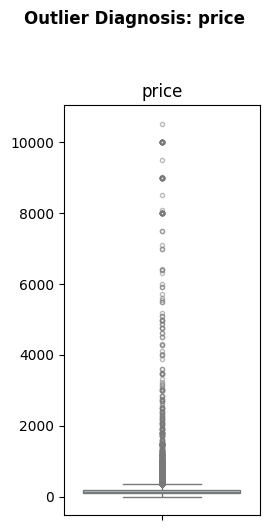

,mean,min,1%,5%,50%,75%,90%,95%,99%,max
price,197.33,8.0,41.0,60.0,133.0,195.25,304.0,426.0,1005.74,10515.0


In [68]:
diagnose_outliers(listings_cleaned, ["price"], group_name = "price")

The `price` variable exhibits a heavy right skew, with a maximum value roughly ten times the 99th percentile. To prevent these extreme outliers from distorting further modeling stages, listings priced above the 99th percentile will be removed. This trimming drops only ~1% of the data, effectively eliminating anomalies while preserving the core variance required for robust segmentation. No lower-bound adjustment is necessary, as the minimum value represents a plausible budget accommodation rather than a data entry error.

- Property Size & Capacity

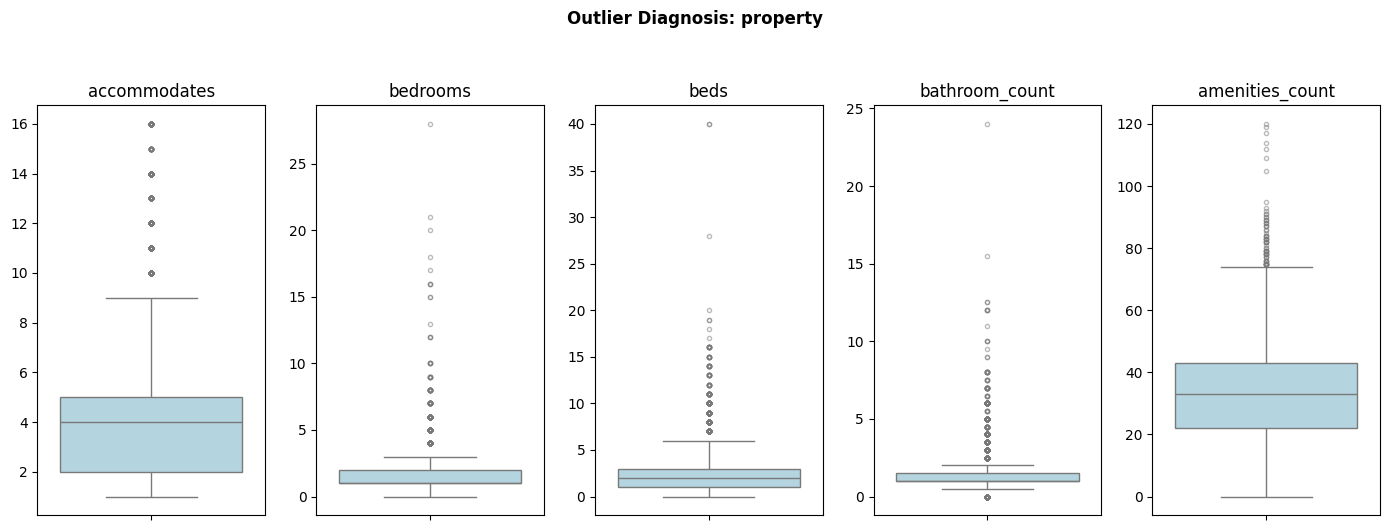

,mean,min,1%,5%,50%,75%,90%,95%,99%,max
accommodates,3.82,1.0,1.0,2.0,4.0,5.0,6.0,7.0,11.0,16.0
bedrooms,1.51,0.0,0.0,1.0,1.0,2.0,3.0,3.0,4.0,28.0
beds,2.22,0.0,0.0,1.0,2.0,3.0,4.0,5.0,7.0,40.0
bathroom_count,1.31,0.0,1.0,1.0,1.0,1.5,2.0,2.0,4.0,24.0
amenities_count,32.58,0.0,5.0,8.0,33.0,43.0,51.0,55.0,64.0,120.0


In [69]:
diagnose_outliers(listings_cleaned, property_cols, group_name = "property")

- `accommodates`: The distribution exhibits a smooth, gradual increase from the median to the maximum. While a capacity of 16 is physically plausible for large group villas, it represents a niche market segment rather than a typical Airbnb listing. Rows with values above the 99th percentile will be removed. This will prevent rare, ultra-large properties from acting as outliers and creating noisy micro-clusters during spatial/behavioral segmentation.

- `bedrooms`: Shows a severe, unnatural discontinuity. The 99th percentile is 4.0, yet the maximum reaches 28.0 which is a 7x jump. This indicates extreme data entry errors or non-residential commercial properties (e.g., hostels, boutique hotels). Rows with values above the 99th percentile will be removed. Keeping or merely capping these values would introduce fundamentally different business models into the dataset, which contradicts the goal of residential segmentation.

- `beds`: Follows the same erratic pattern as `bedrooms`. A massive leap from the 99th percentile to the maximum strongly suggests dormitory-style accommodations or input errors. Rows with values above the 99th percentile will be removed to ensure the dataset strictly reflects plausible, private residential accommodations.

- `bathroom_count`: Displays a highly improbable maximum of 24.0 compared to a 99th percentile of just 4.0. A 6x jump is structurally implausible for standard apartments or houses. Rows with values above the 99th percentile will be removed to eliminate misclassified commercial properties and data anomalies.

- `amenities_count`: Unlike structural variables, this feature shows a continuous, plausible spread up to the maximum. A high count does not imply an error or a hostel; it merely reflects hosts exhaustively checking available UI options on the platform. Values at the 99th percentile will be winsorized. Since these are valid listings, removing the rows entirely would result in unnecessary data loss. Capping neutralizes the variance caused by overzealous tagging while preserving the observation for clustering.

- Host Profile & Scale

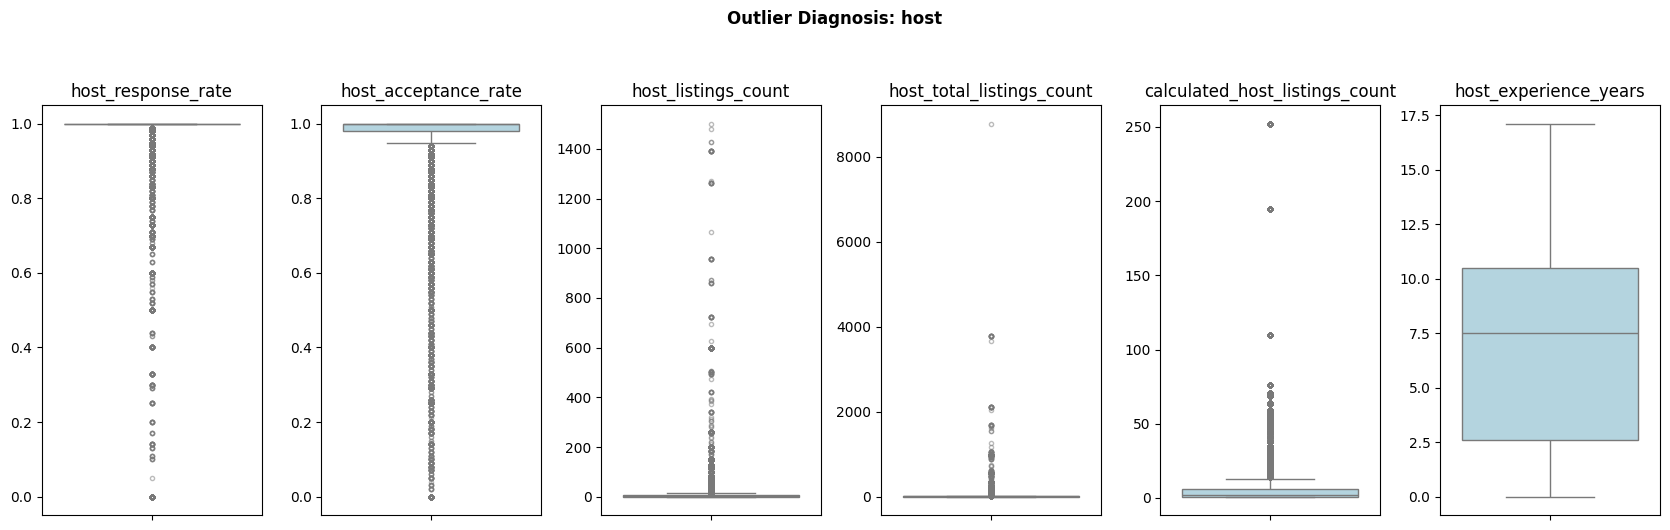

,mean,min,1%,5%,50%,75%,90%,95%,99%,max
host_response_rate,0.97,0.0,0.0,0.80,1.0,1.0,1.0,1.0,1.0,1.0
host_acceptance_rate,0.92,0.0,0.0,0.44,1.0,1.0,1.0,1.0,1.0,1.0
host_listings_count,16.12,1.0,1.0,1.00,3.0,7.0,26.0,58.0,262.0,1500.0
host_total_listings_count,24.24,1.0,1.0,1.00,3.0,9.0,32.0,68.0,544.0,8768.0
calculated_host_listings_count,9.47,1.0,1.0,1.00,2.0,6.0,19.0,41.0,195.0,252.0
host_experience_years,6.94,0.0,0.2,0.60,7.5,10.5,12.3,13.3,14.4,17.1


In [70]:
diagnose_outliers(listings_cleaned, host_behaviour_cols, group_name = "host")

- `host_response_rate` & `host_acceptance_rate`: Both variables are naturally bounded within the range [0,1] and exhibit a strong left-skew. Lower values (0.0–0.8) do not represent data errors but rather meaningful behavioral differences, such as slow response times or frequent booking rejections. In this case no action needed, as lower values constitute valuable variation that enables clustering algorithms to distinguish less responsive or less active hosts from highly engaged ones.

- `host_listings_count` & `host_total_listings_count`: Both variables exhibit an extreme right-skewed distribution. While the median host owns only 3 listings, the 99th percentile reaches 544 listings and the maximum value is 8,768. This substantial jump reflects the presence of large property management companies whose business model differs fundamentally from that of individual hosts. For segmentation purposes, trimming observations above the 99th percentile will be performed. Retaining these extreme values or merely capping them would likely cause clustering algorithms to separate these corporate hosts solely based on portfolio size, overshadowing other relevant accommodation characteristics.

- `calculated_host_listings_count`: This variable shows a similar right-skewed distribution, although less pronounced, since it measures the number of listings a host manages only within the analyzed city or region rather than globally. Trimming at the 99th percentile will be applied to maintain consistency with the treatment of the global host scale variables while reducing the influence of extreme local portfolio sizes.

- Booking Terms & Availability

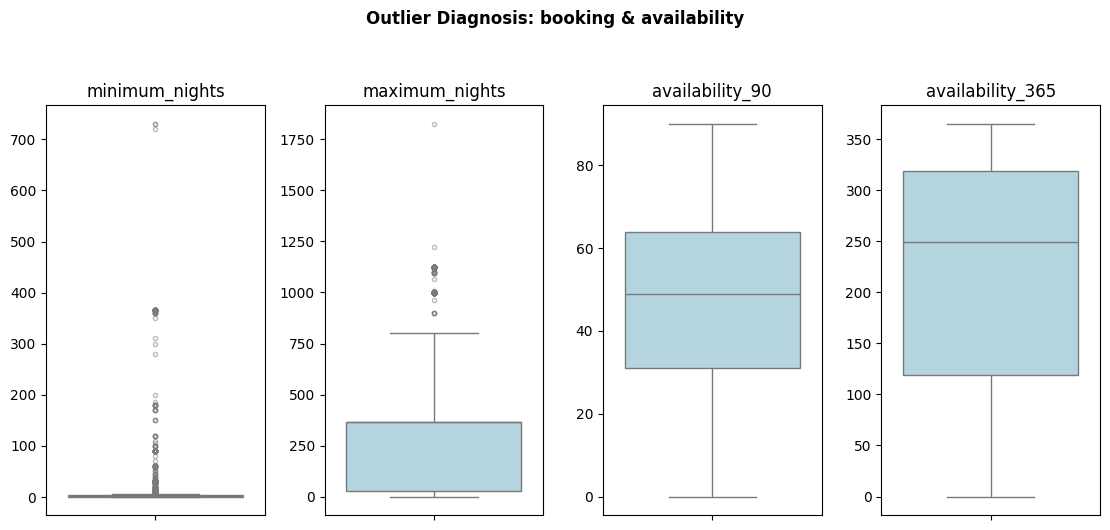

,mean,min,1%,5%,50%,75%,90%,95%,99%,max
minimum_nights,5.39,1.0,1.0,1.0,2.0,3.0,31.0,31.0,31.0,730.0
maximum_nights,346.16,1.0,7.0,15.0,365.0,365.0,1125.0,1125.0,1125.0,1825.0
availability_90,46.56,0.0,0.0,0.0,49.0,64.0,82.0,89.0,90.0,90.0
availability_365,216.34,0.0,0.0,0.0,249.0,319.0,343.0,359.0,365.0,365.0


In [71]:
diagnose_outliers(listings_cleaned, availability_cols, group_name = "booking & availability")

- `minimum_nights`: The distribution exhibits a strong domain-specific plateau: the 90th, 95th, and 99th percentiles all tie precisely at 31.0. This is not a statistical coincidence; it reflects local housing regulations that force hosts to switch to long-term monthly rentals. Values extending up to 730 days (2 years) represent standard residential leasing or artificially blocked calendars rather than short-term tourism. Rows where `minimum_nights` > 31 will be removed. Standard statistical methods (like 99th percentile capping) fail here due to the plateau. Properties requiring stays longer than a month operate under a fundamentally different business model (long-term real estate) and would introduce severe noise into tourist accommodation clustering.

- `maximum_nights`: The data shows a sudden spike where the 90th, 95th, and 99th percentiles all equal 1125, with a maximum of 1825. These are known Airbnb system defaults (representing exactly 3 and 5 years) automatically assigned when a host does not set a limit. They are system artifacts, not organic numerical extremes. Values will be capped at 365, as leaving artificial defaults like 1125 will severely distort the Euclidean distance space during clustering. Capping at 1 year (365 days) standardizes the metric for the algorithm, preserving the listings in the dataset while neutralizing the mathematical weight of the system default.

- Guest Review Scores

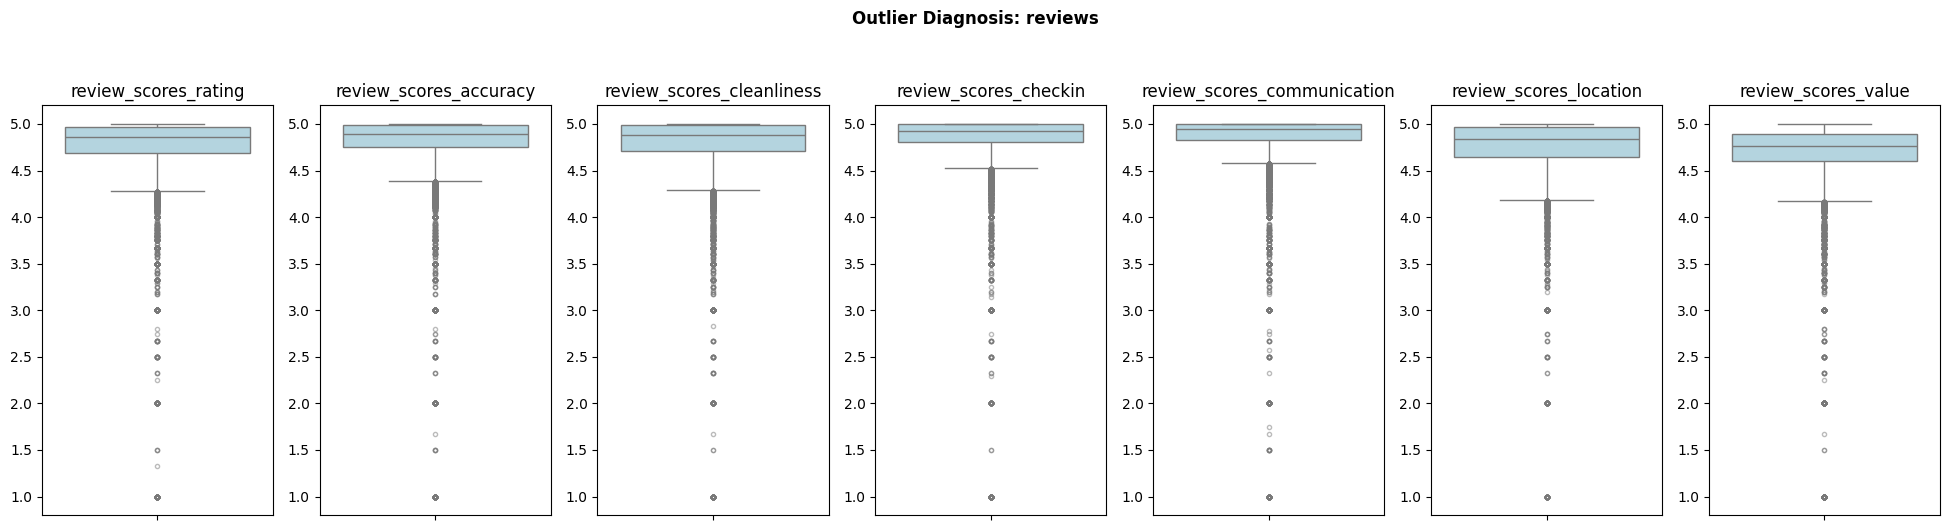

,mean,min,1%,5%,50%,75%,90%,95%,99%,max
review_scores_rating,4.77,1.0,3.50,4.25,4.86,4.97,5.0,5.0,5.0,5.0
review_scores_accuracy,4.80,1.0,3.50,4.33,4.89,4.99,5.0,5.0,5.0,5.0
review_scores_cleanliness,4.78,1.0,3.50,4.28,4.88,4.99,5.0,5.0,5.0,5.0
review_scores_checkin,4.84,1.0,3.75,4.47,4.92,5.00,5.0,5.0,5.0,5.0
review_scores_communication,4.86,1.0,3.60,4.47,4.95,5.00,5.0,5.0,5.0,5.0
review_scores_location,4.75,1.0,3.67,4.22,4.84,4.97,5.0,5.0,5.0,5.0
review_scores_value,4.69,1.0,3.00,4.00,4.76,4.89,5.0,5.0,5.0,5.0


In [72]:
diagnose_outliers(listings_cleaned, review_cols, group_name = "reviews")

- Review Scores (`rating`, `accuracy`, `cleanliness`, `checkin`, `communication`, `location`, `value`): All seven variables are strictly constrained by the platform's UI to a natural boundary of [1.0, 5.0]. The distributions exhibit a severe left-skew, with the 90th to 99th percentiles universally plateauing at a perfect 5.0. The lower-end values (1.0–3.5), while statistically rare, are not data entry errors or artifacts, but genuine representations of poor guest experiences. No outlier treatment required. Applying standard statistical filtering to these variables would inadvertently delete legitimate, high-value signals. Retaining the full spectrum of these scores is critical for clustering algorithms to successfully identify and segment the "low-quality/poor satisfaction" market cohort.

- Demand & Popularity

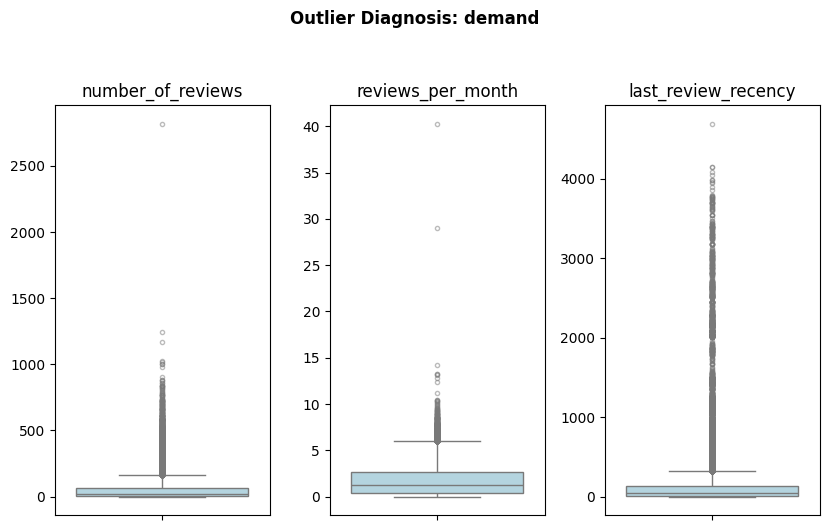

,mean,min,1%,5%,50%,75%,90%,95%,99%,max
number_of_reviews,58.25,0.00,0.00,0.00,18.00,68.00,171.00,256.45,471.49,2817.00
reviews_per_month,1.74,0.01,0.03,0.07,1.26,2.65,4.04,4.92,6.65,40.25
last_review_recency,199.63,0.00,1.00,2.00,42.00,135.00,505.00,930.30,2449.00,4690.00


In [73]:
diagnose_outliers(listings_cleaned, demand_cols, group_name = "demand")

- `number_of_reviews`: The distribution is heavily right-skewed. The maximum reaches 2,817—nearly six times the 99th percentile. These extreme upper values are not data errors but represent genuine "hyper-popular" properties or early adopters that have accumulated reviews over many years. Capping at the 99th percentile will be applied. Trimming these rows would mean deleting some of the most successful listings on the platform. Capping retains these highly active properties in the dataset while pulling their extreme Euclidean distance back to a manageable threshold, preventing them from forming isolated micro-clusters.

- `reviews_per_month`: Exhibits a similar extreme right-skew. The maximum value implies more than one review per day, which, while theoretically possible for 1-night turnover properties or listings renting out multiple individual rooms, is highly anomalous compared to the 99th percentile. Capping at the 99th percentile will be applied. This normalizes the turnover rate for the clustering algorithm, neutralizing the mathematical distortion caused by extreme high-frequency outliers while preserving the listing's status as a "high-demand" property.

- `last_review_recency`: This feature fundamentally measures inactivity. The distribution has a massive right tail: while the median listing was reviewed 42 days ago, the maximum stretches to 4,690 days (~12.8 years), and the 99th percentile is 2,449 days (~6.7 years). These extreme values represent "zombie" or dormant listings that are no longer actively participating in the market. Rows with values above the 99th percentile will be removed. Unlike high popularity, extreme inactivity introduces structurally irrelevant data. Properties that haven't hosted a guest in over 6 years do not reflect current market dynamics and will act as noise. Removing them ensures the clustering algorithm segments the active competitive landscape.

### 6.2 Outliers handling

- Capping

In [74]:
listings_capped = listings_cleaned.copy()

cols_to_cap_99 = [
    'amenities_count',
    'number_of_reviews',
    'reviews_per_month'
]

for col in cols_to_cap_99:
    cap_value = listings_capped[col].quantile(0.99)
    listings_capped[col] = listings_capped[col].clip(upper=cap_value)


listings_capped['maximum_nights'] = listings_capped['maximum_nights'].clip(upper=365.0)

- Trimming

In [75]:
indices_to_drop = set()

# columns for the 99th percentile trimming
cols_to_trim_99 = [
    'price',
    'accommodates',
    'bedrooms',
    'beds',
    'bathroom_count',
    'host_listings_count',
    'host_total_listings_count',
    'calculated_host_listings_count',
    'last_review_recency'
]

for col in cols_to_trim_99:
    threshold = listings_capped[col].quantile(0.99)
    outliers = listings_capped[listings_capped[col] > threshold].index
    indices_to_drop.update(outliers)

# minimum_nights
min_nights_outliers = listings_capped[listings_capped['minimum_nights'] > 31].index
indices_to_drop.update(min_nights_outliers)

# stats
total_rows = len(listings_capped)
dropped_rows = len(indices_to_drop)
percent_dropped = (dropped_rows / total_rows) * 100

print(f"Total rows before trimming: {total_rows}")
print(f"Unique rows to trim: {dropped_rows}")
print(f"%: {percent_dropped:.2f}%")

Total rows before trimming: 37652
Unique rows to trim: 1814
%: 4.82%


In [76]:
listings_trimmed = listings_capped.drop(index=list(indices_to_drop)).reset_index(drop=True)

## 7. Missing Values

In [77]:
# columns with missing values

listings_trimmed.loc[:, listings_trimmed.isna().any()].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
host_response_time,29446,4,within an hour,25099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_response_rate,29446.0,NaN,NaN,NaN,0.966614,0.136867,0.0,1.0,1.0,1.0,1.0
host_acceptance_rate,32325.0,NaN,NaN,NaN,0.926649,0.202023,0.0,0.98,1.0,1.0,1.0
host_is_superhost,33702.0,<NA>,<NA>,<NA>,0.39787,0.489466,0.0,0.0,0.0,1.0,1.0
host_neighbourhood,11067,99,Prati,1303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_listings_count,35829.0,NaN,NaN,NaN,9.284406,20.754619,1.0,1.0,3.0,7.0,257.0
host_total_listings_count,35829.0,NaN,NaN,NaN,11.757766,29.956345,1.0,1.0,3.0,8.0,489.0
host_has_profile_pic,35829.0,<NA>,<NA>,<NA>,0.939742,0.237968,0.0,1.0,1.0,1.0,1.0
host_identity_verified,35829.0,<NA>,<NA>,<NA>,0.919032,0.27279,0.0,1.0,1.0,1.0,1.0
bedrooms,35073.0,NaN,NaN,NaN,1.444958,0.713649,0.0,1.0,1.0,2.0,4.0


### 7.1 Visual Diagnostics

In [95]:
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import pearsonr

def plot_significant_corr_heatmap(df, cols, title, alpha=0.05, use_bonferroni=False,
                                   min_effect_size=0.1, cell_size=0.6, is_binary=False):
    if is_binary:
        data = df[cols].isnull()
        data = data.loc[:, data.var() > 0]
        cols = data.columns
    else:
        data = df[cols]

    n = len(cols)
    corr_matrix = pd.DataFrame(np.eye(n), index=cols, columns=cols)
    pval_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i in range(n):
        for j in range(i + 1, n):
            pair = data.iloc[:, [i, j]].dropna()
            x = pair.iloc[:, 0].astype(int) if is_binary else pair.iloc[:, 0]
            y = pair.iloc[:, 1].astype(int) if is_binary else pair.iloc[:, 1]
            r, p = pearsonr(x, y)
            corr_matrix.iloc[i, j] = corr_matrix.iloc[j, i] = r
            pval_matrix.iloc[i, j] = pval_matrix.iloc[j, i] = p

    n_comparisons = n * (n - 1) / 2
    threshold = alpha / n_comparisons if use_bonferroni else alpha

    sig_arr = (pval_matrix.values < threshold)
    np.fill_diagonal(sig_arr, True)
    is_significant = pd.DataFrame(sig_arr, index=cols, columns=cols)

    annot_labels = corr_matrix.round(1).astype(str)
    annot_labels = annot_labels.where(corr_matrix.abs() > min_effect_size, "")

    size = max(8, cell_size * n)
    fig, ax = plt.subplots(figsize=(size, size))

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.1)

    sns.heatmap(
        corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1,
        annot=annot_labels, fmt="", annot_kws={"fontsize": 10},
        cbar_kws={"label": "Pearson correlation coefficient"},
        square=True, linewidths=0.5, linecolor="white",
        ax=ax, cbar_ax=cax,
    )

    for i in range(n):
        for j in range(n):
            if not is_significant.iloc[i, j]:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1, fill=False, hatch="////",
                    edgecolor="black", linewidth=0,
                ))

    ax.tick_params(labelsize=10)

    legend_patch = mpatches.Patch(
        facecolor="white", edgecolor="black", hatch="////",
        label=f"Not statistically significant (p ≥ {threshold:.2f})"
    )
    
    fig.legend(
        handles=[legend_patch],
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        framealpha=0.9, fontsize=12,
    )

    fig.suptitle(title, fontsize=16, ha='center')
    plt.tight_layout(rect=[0, 0.08, 1, 0.96]) 
    plt.show()
    return corr_matrix, pval_matrix

,missing_count,missing_pct
host_neighbourhood,24771,69.12
host_response_time,6392,17.84
host_response_rate,6392,17.84
last_review_recency,5109,14.26
reviews_per_month,5109,14.26
review_scores_value,5109,14.26
review_scores_location,5109,14.26
review_scores_communication,5109,14.26
review_scores_checkin,5109,14.26
review_scores_cleanliness,5109,14.26


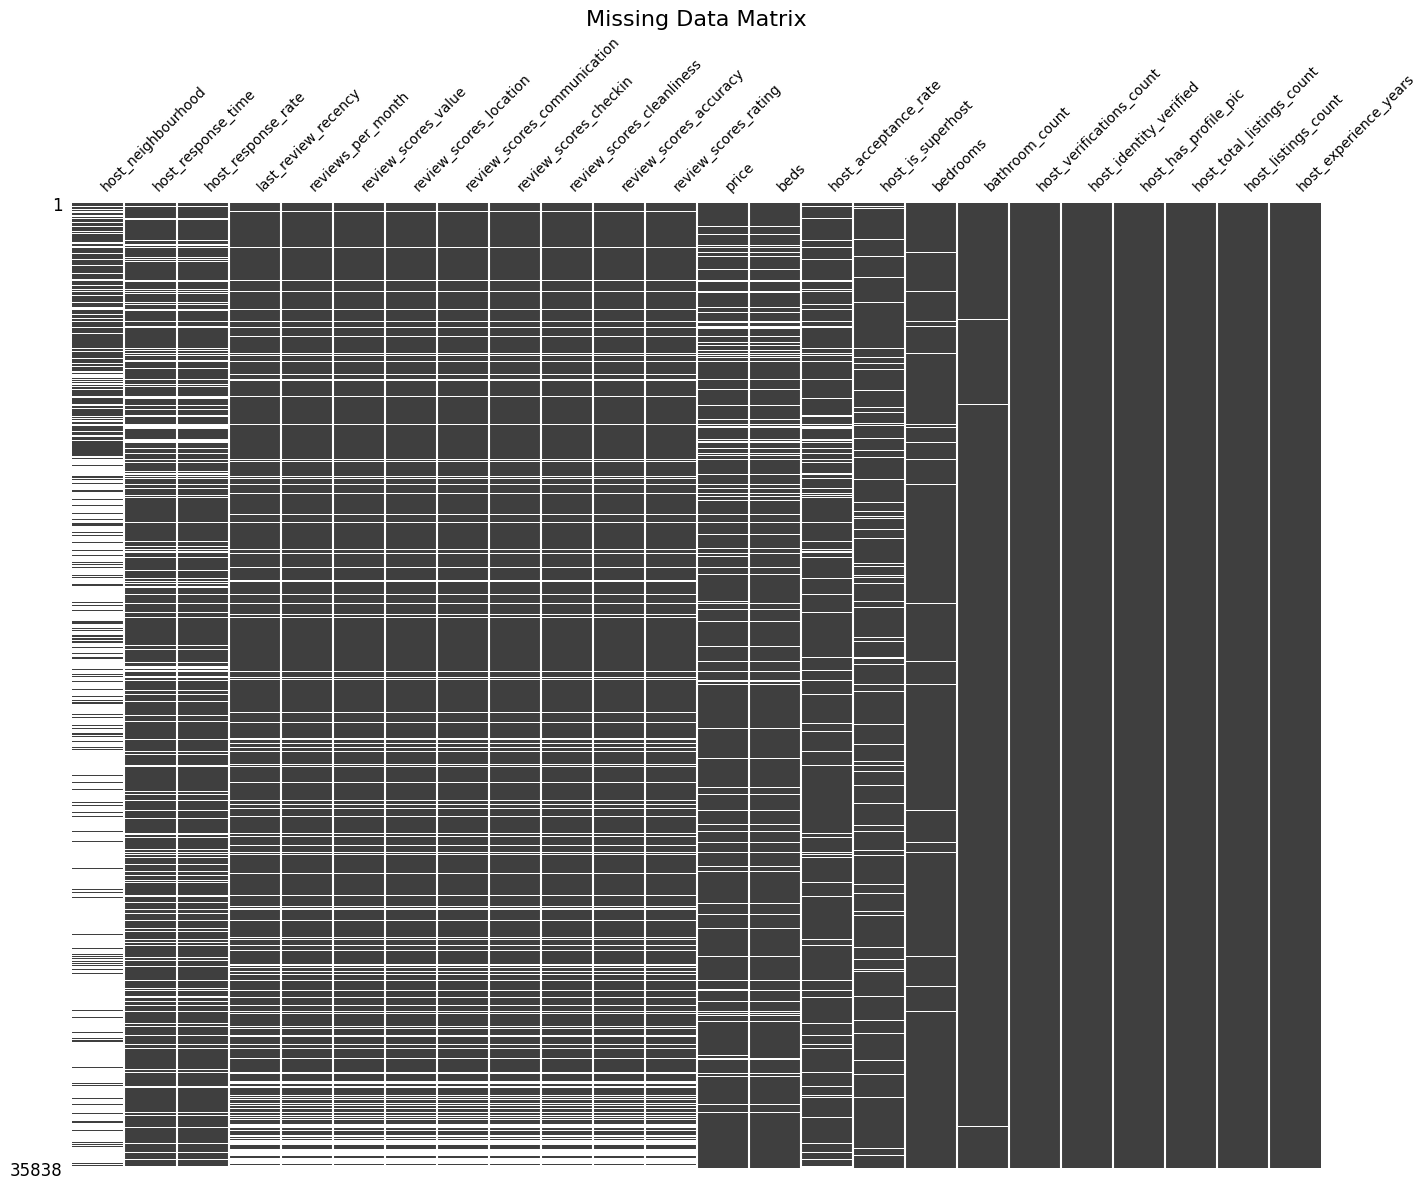

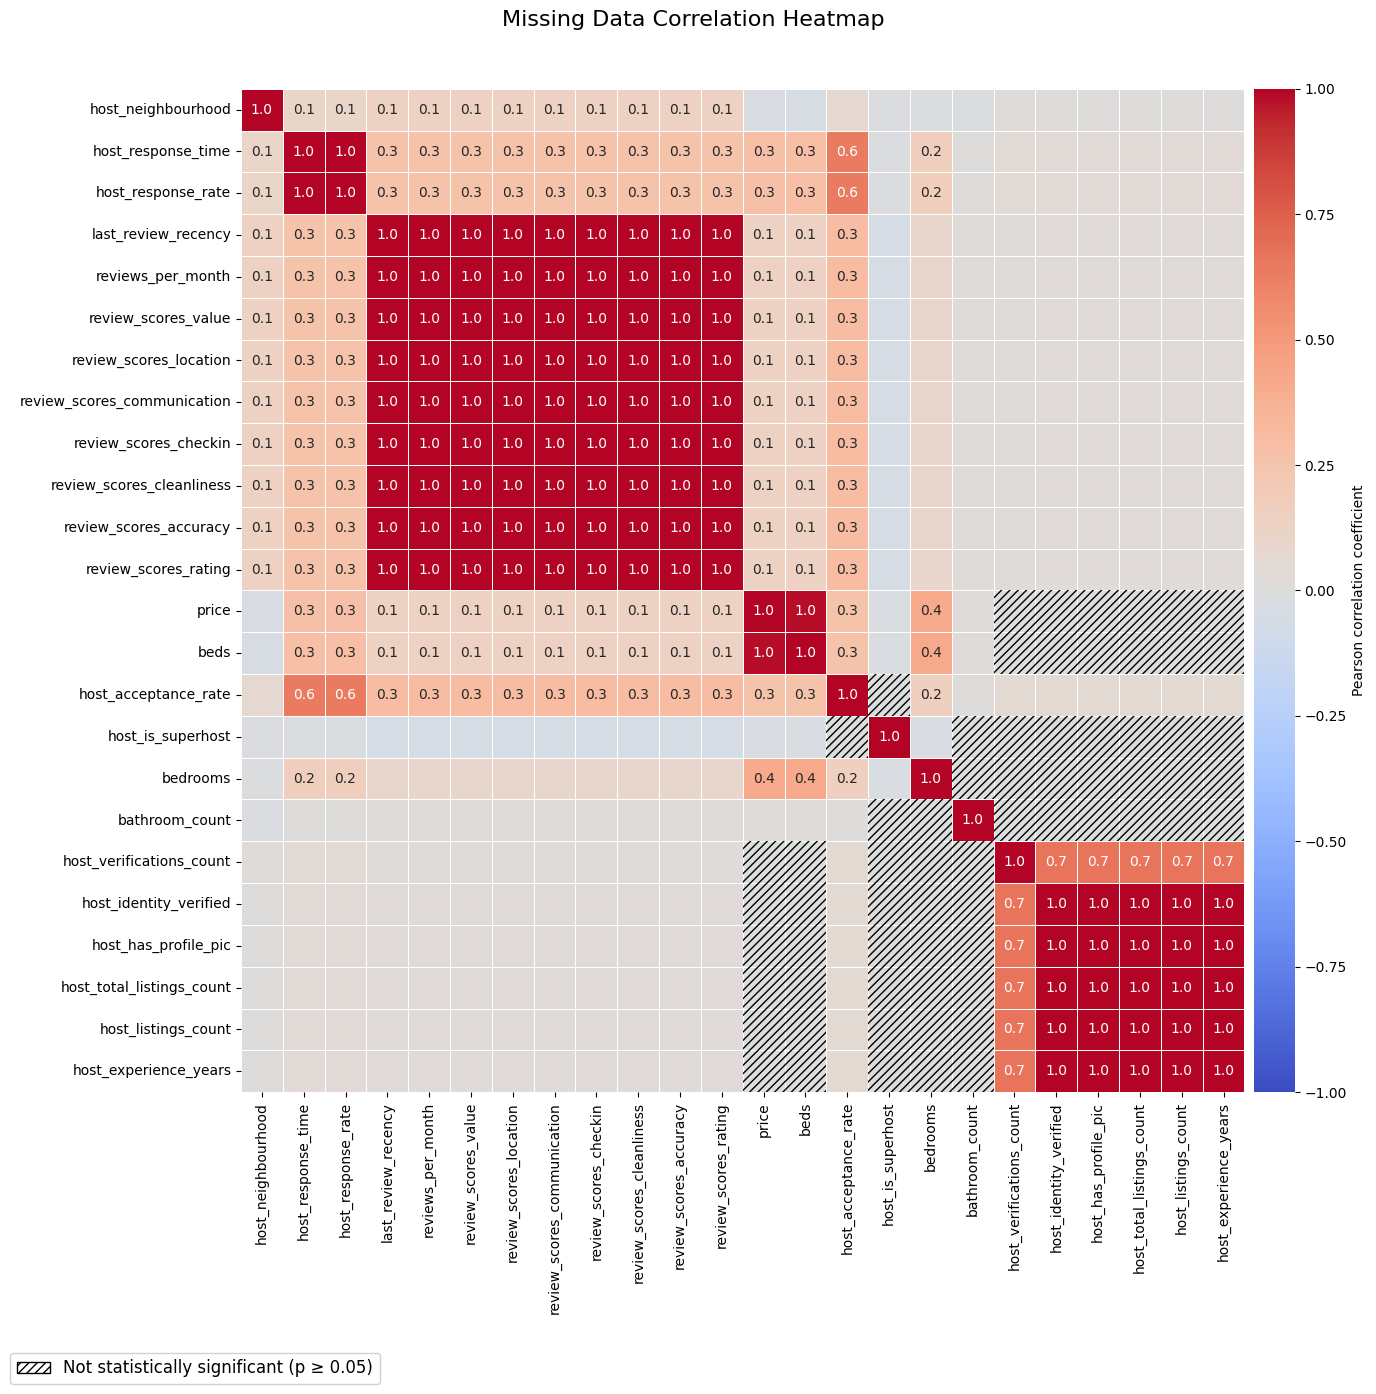

In [96]:
# subset to only columns that have missing values
missing_cols = listings_trimmed.columns[listings_trimmed.isnull().any()].tolist()

# sort columns by amount of missingness 
missing_cols_sorted = (
    listings_trimmed[missing_cols]
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# summary table: missing count + percentage
missing_summary = pd.DataFrame({
    'missing_count': listings_trimmed[missing_cols_sorted].isnull().sum(),
    'missing_pct': (listings_trimmed[missing_cols_sorted].isnull().mean() * 100).round(2)
}).loc[missing_cols_sorted]

display(missing_summary)


# missing values matrix
fig, ax = plt.subplots(figsize=(max(10, 0.6 * len(missing_cols_sorted)), 12))
msno.matrix(listings_trimmed[missing_cols_sorted], sparkline=False, fontsize=10, ax=ax)
plt.title("Missing Data Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# missing values correlation heatmap 
missing_corr, missing_pval = plot_significant_corr_heatmap(
    listings_trimmed, missing_cols_sorted,
    "Missing Data Correlation Heatmap",
    is_binary=True,
)
plt.show()

### Missing Data Structure Diagnosis

**Matrix:**
The missing data matrix reveals that missingness is not randomly scattered across the dataset but concentrated in distinct, visually separable blocks:

- The **review-related block** (`last_review_recency`, `reviews_per_month`, and all seven `review_scores_*` columns) shows an almost perfectly identical white-line pattern across all nine columns — the same rows are blank in every one of them, from the very first row of the matrix down to the bottom. This is a strong visual signature of a shared underlying cause rather than independent, random gaps.
- The **host response block** (`host_response_time`, `host_response_rate`) shows the same tight vertical alignment between its two columns, but a *different* set of rows than the review block — confirming these are two separate structural mechanisms, not one.
- `host_neighbourhood` shows dense, high-frequency white striping distributed fairly evenly across the whole dataset, consistent with a large but unstructured (MCAR-like) gap rather than a block tied to other variables.
- `price`, `beds`, `host_acceptance_rate`, and `bedrooms` show thinner, partially overlapping white bands that loosely track the response/review blocks but are not perfectly aligned with them — suggesting a weaker, MAR-type relationship rather than a hard structural dependency.
- The remaining columns (`bathroom_count`, `host_verifications_count`, `host_identity_verified`, `host_has_profile_pic`, `host_total_listings_count`, `host_listings_count`, `host_experience_years`) are almost entirely solid, with only a handful of isolated white lines — consistent with the very low missing rates (<0.1%) seen in the summary table.

**Correlation heatmap:**
The heatmap quantifies exactly what the matrix suggests visually:

- `host_response_time` and `host_response_rate` correlate at **1.0**. They are missing in exactly the same rows, confirming that `host_response_time` cannot be recorded without an underlying response rate calculation, and vice versa.
- All nine review-related variables (`review_scores_*`, `reviews_per_month`, `last_review_recency`) correlate at **1.0** with each other, which means that a single missingness mechanism drives all of them simultaneously, almost certainly listings with zero reviews.
- `host_acceptance_rate` correlates at **0.6** with the response-time/response-rate pair, which is a real but partial relationship, meaning acceptance rate is missing together with response data in some cases but also has its own independent gaps.
- `price` and `beds` both correlate at **~0.3** with the review block and with each other/`host_acceptance_rate`, which is a weak-to-moderate shared pattern, not a hard dependency.
- `bedrooms` correlates at **0.4** with `beds` and `price` and **0.2** with `host_is_superhost`, which is a mild, plausible relationship (larger/incomplete listings may have multiple fields unfilled together) but far from deterministic.
- `host_is_superhost` shows small **negative** correlations (-0.1) with the review-score block — essentially negligible, indicating superhost status missingness is close to independent of review missingness.
- A separate, near-perfect cluster (**0.7–1.0**) links `host_identity_verified`, `host_has_profile_pic`, `host_total_listings_count`, `host_listings_count`, `host_experience_years`, and `host_verifications_count` — but since the summary table shows these columns are almost fully populated, this reflects a tiny shared set of rows (likely deactivated or malformed host profiles) rather than a substantial missingness mechanism.
- `host_neighbourhood` and `bathroom_count` show negligible correlation with virtually everything else, confirming their gaps are effectively independent of all other variables.

### Conclusion: missingness mechanism by group

| Group | Pattern observed | Likely mechanism |
|---|---|---|
| Review block (9 cols) | Perfect co-occurrence (r=1.0) | **MNAR** — structurally absent for listings with zero reviews |
| Response block (2 cols) | Perfect co-occurrence (r=1.0), partial link to acceptance rate (r=0.6) | **MAR/MNAR hybrid** — tied to hosts with no communication history |
| price, beds, bedrooms, host_acceptance_rate | Weak-to-moderate correlation (0.2–0.4) with other blocks | **MAR** — related to, but not fully explained by, other observed variables |
| host_neighbourhood | High volume, no meaningful correlation with anything | **MCAR-like** — independent, profile-field non-completion |
| host_is_superhost | Near-zero/negative correlation | **MCAR-like** — independent of review/response gaps |
| Tiny-missing cluster (verifications, profile pic, listings counts, experience years) | High mutual correlation but negligible volume (<0.1%) | Isolated malformed/incomplete host records — treat as trivial |

### Resulting handling strategy

Based on this evidence, missing values will be handled according to their diagnosed mechanism rather than a single blanket method:

1. **Structural missingness flags**: Before any imputation, binary indicators `has_reviews` and `has_response_data` will be created from the review block and response block respectively, since the matrix and heatmap confirm these are not random gaps but meaningful "not applicable" signals in themselves.
2. **Categorical fields** (`host_response_time`, `host_neighbourhood`): given their independent, non-random volume and lack of strong correlation to a single predictor set, missing values will be recoded as an explicit `"Unknown"` category rather than imputed with the mode, preserving the information that the field was left blank.
3. **Binary fields** (`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`): due to their low missing volume and weak/negligible correlation with the main blocks, these will either be included in the iterative imputation process or handled with a dedicated classifier, accompanied by their own missingness flag to preserve any residual signal.
4. **Moderately missing numeric fields** (`beds`, `bedrooms`, `bathroom_count`, `host_acceptance_rate`, `host_response_rate`, `host_verifications_count`): since the heatmap shows these are only partially (not perfectly) tied to other variables — i.e., plausibly MAR — they will be tested via `IterativeImputer`, with the results validated in Section 7.6–7.7 before finalizing the imputation method for each variable.
5. **Review-related block** (MNAR): given the confirmed perfect co-missingness with `has_reviews`, this block will be imputed with particular caution — `has_reviews` will be included as a mandatory predictor, and the resulting limitation (imputing scores for listings that never received real guest feedback) will be explicitly acknowledged as a methodological constraint in the write-up, rather than treated as a standard MAR imputation.
6. **price**: although the heatmap shows only a weak-to-moderate correlation (~0.3) with the review and response blocks — consistent with an ordinary MAR variable that could technically be imputed — `price` is deliberately **excluded from imputation**. Since the planned clustering will be performed without `price` as an input feature, and `price` is instead reserved for post-hoc validation of the resulting segments (checking whether hosts are pricing fairly relative to their cluster, and later comparing this after adding NLP-derived features), imputing it would introduce circularity: values generated from the same variables used to profile clusters would no longer serve as an independent, observed benchmark. Rows with missing `price` will therefore be retained in the clustering stage (since `price` is not among its inputs) but excluded via list-wise deletion specifically from any price-based analysis, preserving the integrity of `price` as an external, unaltered reference variable.

### 7.2 Tiny-Missing Host Cluster: Verification & Removal

In [79]:
tiny_host_cluster_cols = [
    'host_identity_verified', 'host_has_profile_pic',
    'host_listings_count', 'host_total_listings_count',
    'host_experience_years', 'host_verifications_count'
]

missing_masks = listings_trimmed[tiny_host_cluster_cols].isna()

rows_missing_any = missing_masks.any(axis=1).sum()
rows_missing_all = missing_masks.all(axis=1).sum()
total_rows = len(listings_trimmed)

print(f"Rows missing in at least one column of the cluster: {rows_missing_any} ({rows_missing_any/total_rows*100:.2f}%)")
print(f"Rows missing in all columns of the cluster simultaneously: {rows_missing_all} ({rows_missing_all/total_rows*100:.2f}%)")

display(missing_masks.sum().rename('missing_count').to_frame()
        .assign(missing_pct=lambda d: (d['missing_count'] / total_rows * 100).round(2)))

Rows missing in at least one column of the cluster: 20 (0.06%)
Rows missing in all columns of the cluster simultaneously: 9 (0.03%)


,missing_count,missing_pct
host_identity_verified,9,0.03
host_has_profile_pic,9,0.03
host_listings_count,9,0.03
host_total_listings_count,9,0.03
host_experience_years,9,0.03
host_verifications_count,20,0.06


Since the union of missing values across the entire tiny host cluster amounts to only **~0.06%** of the dataset, these rows can be safely dropped via list-wise deletion without any meaningful loss of information.

In [80]:
# drop rows with missing values in the host cluster
listings_trimmed = listings_trimmed.dropna(subset=tiny_host_cluster_cols).reset_index(drop=True)

listings_clean = listings_trimmed.copy()

### 7.3 Feature Engineering: Missingness Indicators

In [81]:
# create missingness indicator for the review block
listings_clean['has_reviews'] = (~listings_clean['review_scores_rating'].isna()).astype(int)

# create missingness indicator for the host response block
listings_clean['has_response_data'] = (~listings_clean['host_response_time'].isna()).astype(int)

### 7.4 Handling Categorical & Trivial Missing Data

In [82]:
# define categorical columns with missing values
cat_missing_cols = ['host_response_time', 'host_neighbourhood']

for col in cat_missing_cols:
    if col in listings_clean.columns:
        if isinstance(listings_clean[col].dtype, pd.CategoricalDtype):
            listings_clean[col] = (
                listings_clean[col]
                .cat.add_categories(["Unknown"])
                .fillna("Unknown")
            )
        else:
            listings_clean[col] = listings_clean[col].fillna("Unknown")

### 7.5 Multivariate Imputation by Chained Equations (MICE)

In [83]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import OrdinalEncoder

# missingness flags for binary host fields
# preserves the "profile left incomplete" signal before these columns get imputed
binary_cols = ['host_is_superhost']
for col in binary_cols:
    listings_clean[f'{col}_was_missing'] = listings_clean[col].isna().astype(int)

# columns to impute ('price' is intentionally excluded)
# 'last_review_recency' is excluded here and handled separately via a log-transform 
numeric_cols_to_impute = [
    'beds', 'bedrooms', 'bathroom_count',
    'host_acceptance_rate', 'host_response_rate',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month'
]

binary_cols_to_impute = binary_cols 

# log1p-transform last_review_recency to compress its scale before imputation;
log_col = 'last_review_recency'
log_col_transformed = f'{log_col}_log'
listings_clean[log_col_transformed] = np.log1p(listings_clean[log_col])

cols_to_impute = numeric_cols_to_impute + binary_cols_to_impute + [log_col_transformed]

# predictors
numeric_predictors = ['accommodates', 'amenities_count', 'has_reviews', 'has_response_data']
cat_predictors = [c for c in ['room_type', 'property_type', 'neighbourhood_cleansed'] if c in listings_clean.columns]

mice_features = cols_to_impute + numeric_predictors + cat_predictors
df_mice = listings_clean[mice_features].copy()

# ordinal-encode categorical predictors
if cat_predictors:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_mice[cat_predictors] = encoder.fit_transform(df_mice[cat_predictors])

# define logical bounds
min_values, max_values = [], []
for col in df_mice.columns:
    if col.startswith('review_scores_'):
        min_values.append(1.0); max_values.append(5.0)
    elif col in ['host_response_rate', 'host_acceptance_rate']:
        min_values.append(0.0); max_values.append(1.0)
    elif col in binary_cols_to_impute:
        min_values.append(0.0); max_values.append(1.0)
    elif col == log_col_transformed:
        # bounds on the log-transformed scale, not the raw scale
        min_values.append(0.0)
        max_values.append(listings_clean[log_col_transformed].max())
    elif col in numeric_predictors + cat_predictors:
        min_values.append(-np.inf); max_values.append(np.inf)
    else:
        min_values.append(0.0)
        max_values.append(listings_clean[col].max())

# fit MICE
imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=15, random_state=42),
    max_iter=20,
    min_value=min_values,
    max_value=max_values,
    random_state=42,
    verbose=0
)

df_mice_imputed = pd.DataFrame(
    imputer.fit_transform(df_mice),
    columns=df_mice.columns,
    index=df_mice.index
)

# post-process & merge back
# round discrete counters
cols_to_round = ['beds', 'bedrooms', 'bathroom_count']
for col in cols_to_round:
    listings_clean[col] = np.round(df_mice_imputed[col])

# binarize boolean host fields
for col in binary_cols_to_impute:
    listings_clean[col] = (df_mice_imputed[col] > 0.5).astype(int)

# transfer remaining continuous imputed columns
other_imputed = [c for c in numeric_cols_to_impute if c not in cols_to_round]
for col in other_imputed:
    listings_clean[col] = df_mice_imputed[col]

# inverse-transform last_review_recency back to its original scale
listings_clean[log_col] = np.expm1(df_mice_imputed[log_col_transformed])
listings_clean = listings_clean.drop(columns=[log_col_transformed])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### 7.6 Post-Imputation Validation

In [84]:
def validate_imputation(original_df, imputed_df, column, title, discrete=False, bounds=None):
    """
    Compares the distribution of originally observed values vs. newly
    imputed values only (not the full post-imputation column), to check
    whether MICE-generated values are distributionally plausible.
    """
    was_missing = original_df[column].isna()
    observed = original_df.loc[~was_missing, column]
    imputed_only = imputed_df.loc[was_missing, column]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # plot 1: distribution comparison
    ax = axes[0]
    if discrete:
        bins = np.arange(observed.min(), observed.max() + 2) - 0.5
        ax.hist(observed, bins=bins, density=True, alpha=0.5,
                color='steelblue', label=f'Observed (n={len(observed)})')
        ax.hist(imputed_only, bins=bins, density=True, alpha=0.5,
                color='darkred', label=f'Imputed (n={len(imputed_only)})')
        ax.set_xticks(np.arange(observed.min(), observed.max() + 1))
    else:
        clip = bounds if bounds is not None else None
        sns.kdeplot(observed, color='steelblue', fill=True, alpha=0.4,
                    label=f'Observed (n={len(observed)})', clip=clip, ax=ax)
        sns.kdeplot(imputed_only, color='darkred', linewidth=2, linestyle='--',
                    label=f'Imputed (n={len(imputed_only)})', clip=clip, ax=ax)

    ax.set_title(f'{title}: Observed vs. Imputed values')
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.legend()

    # plot 2: summary stats table as text
    ax2 = axes[1]
    ax2.axis('off')
    stats = pd.DataFrame({
        'Observed': [observed.mean(), observed.median(), observed.std()],
        'Imputed':  [imputed_only.mean(), imputed_only.median(), imputed_only.std()],
        'Full (post-imputation)': [
            imputed_df[column].mean(), imputed_df[column].median(), imputed_df[column].std()
        ]
    }, index=['mean', 'median', 'std']).round(3)

    table = ax2.table(cellText=stats.values,
                       rowLabels=stats.index,
                       colLabels=stats.columns,
                       cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)

    plt.suptitle(f'Imputation Validation: {title}', fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

    return stats

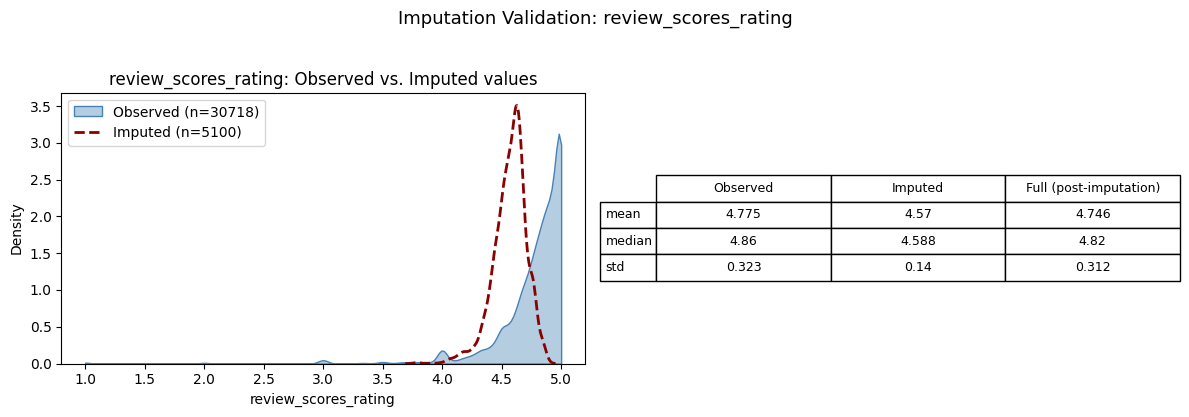

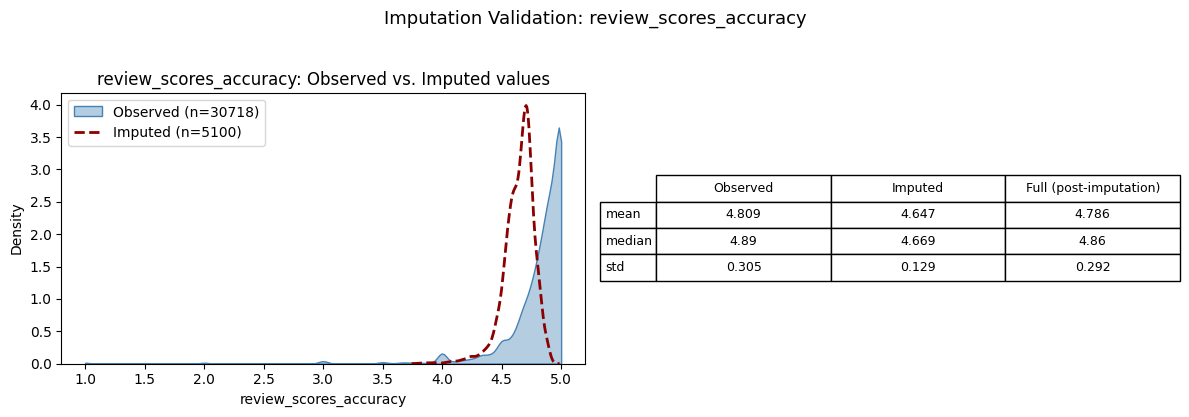

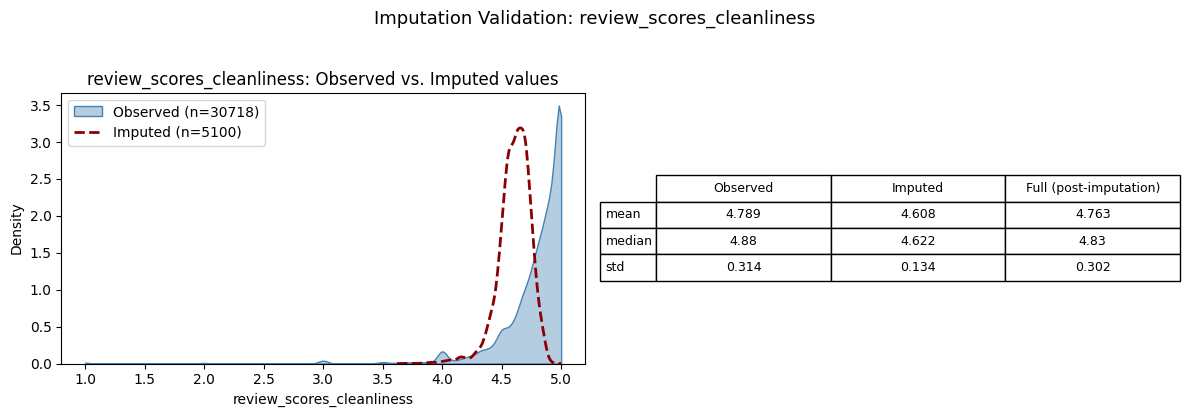

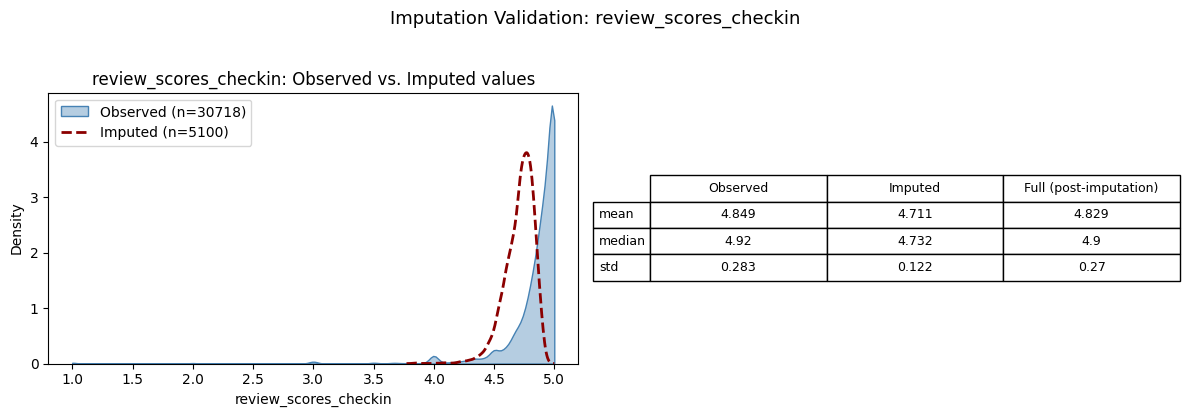

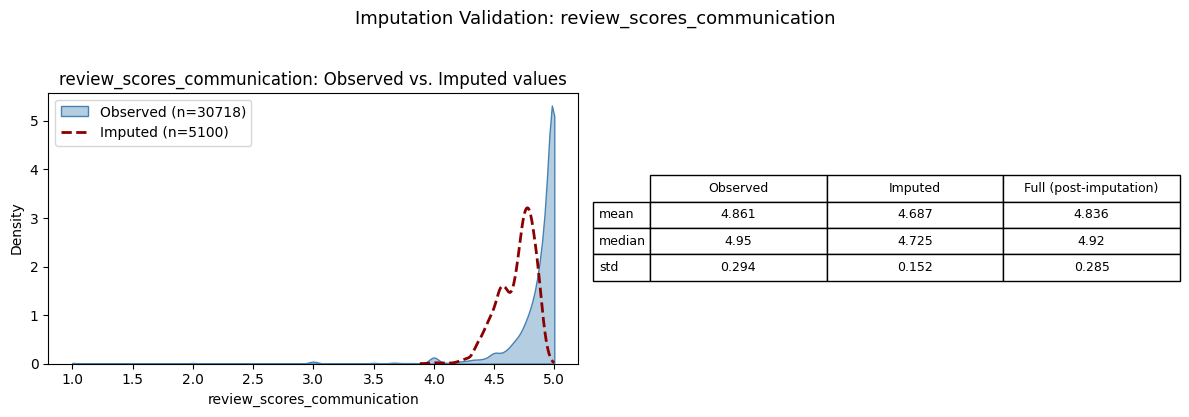

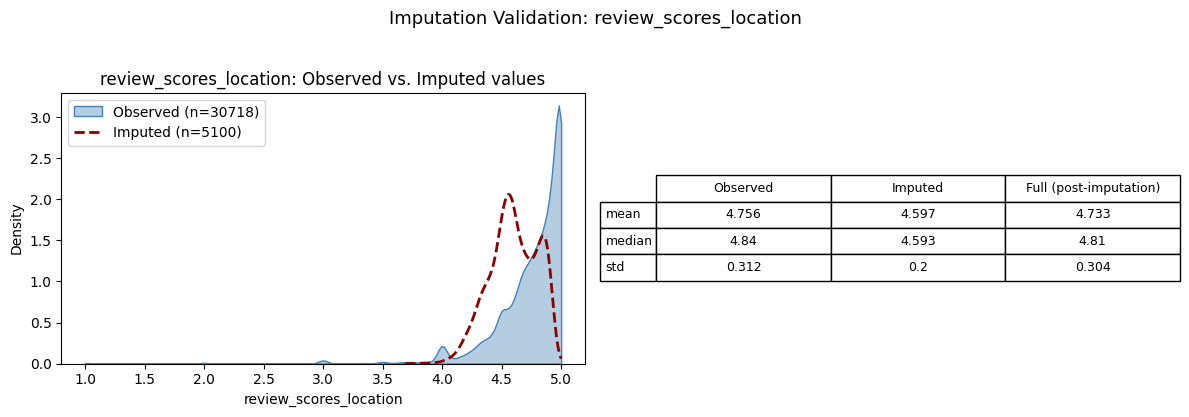

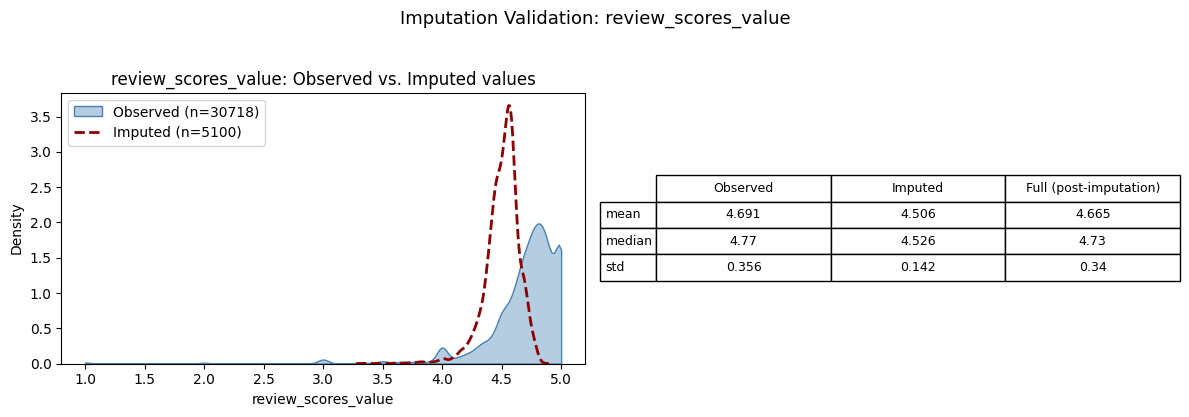

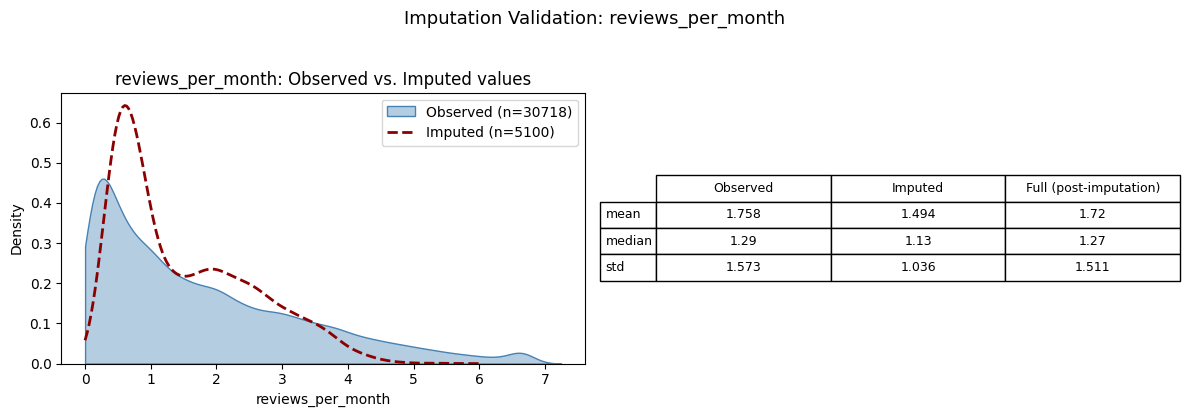

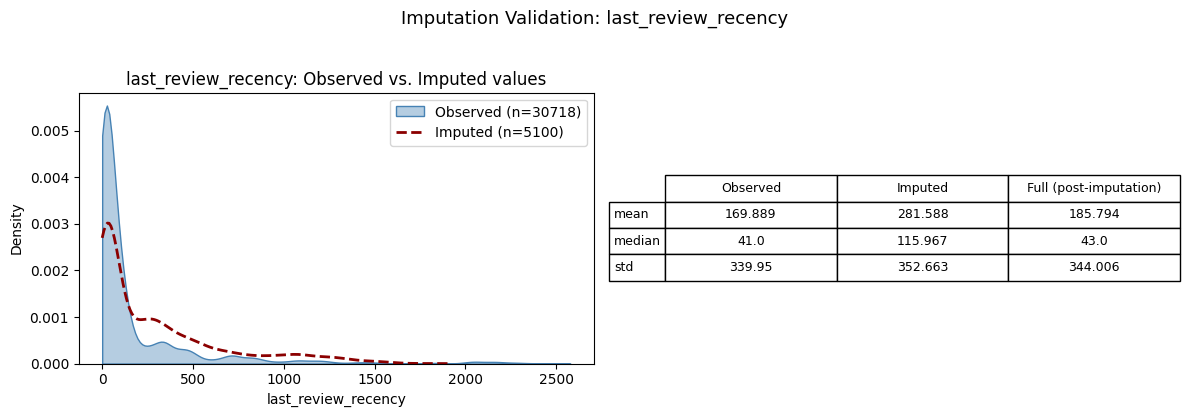

,variable,mean_observed,mean_imputed,std_observed,std_imputed,std_shrinkage_%
0,review_scores_rating,4.775,4.570,0.323,0.140,56.7
1,review_scores_accuracy,4.809,4.647,0.305,0.129,57.7
2,review_scores_cleanliness,4.789,4.608,0.314,0.134,57.3
3,review_scores_checkin,4.849,4.711,0.283,0.122,56.9
4,review_scores_communication,4.861,4.687,0.294,0.152,48.3
5,review_scores_location,4.756,4.597,0.312,0.200,35.9
6,review_scores_value,4.691,4.506,0.356,0.142,60.1
7,reviews_per_month,1.758,1.494,1.573,1.036,34.1
8,last_review_recency,169.889,281.588,339.950,352.663,-3.7


In [85]:
# MNAR Bounded Variables
mnar_config = {
    'review_scores_rating': (False, (1, 5)),
    'review_scores_accuracy': (False, (1, 5)),
    'review_scores_cleanliness': (False, (1, 5)),
    'review_scores_checkin': (False, (1, 5)),
    'review_scores_communication': (False, (1, 5)),
    'review_scores_location': (False, (1, 5)),
    'review_scores_value': (False, (1, 5)),
    'reviews_per_month': (False, (0, None)),
    'last_review_recency': (False, (0, None)),
}


mnar_rows = []
for col, (discrete, bounds) in mnar_config.items():
    stats = validate_imputation(listings_trimmed, listings_clean, col,
                                 title=col, discrete=discrete, bounds=bounds)
    mnar_rows.append({
        'variable': col,
        'mean_observed': stats.loc['mean', 'Observed'],
        'mean_imputed': stats.loc['mean', 'Imputed'],
        'std_observed': stats.loc['std', 'Observed'],
        'std_imputed': stats.loc['std', 'Imputed'],
        'std_shrinkage_%': round((1 - stats.loc['std', 'Imputed'] / stats.loc['std', 'Observed']) * 100, 1)
    })

mnar_summary = pd.DataFrame(mnar_rows)
display(mnar_summary)

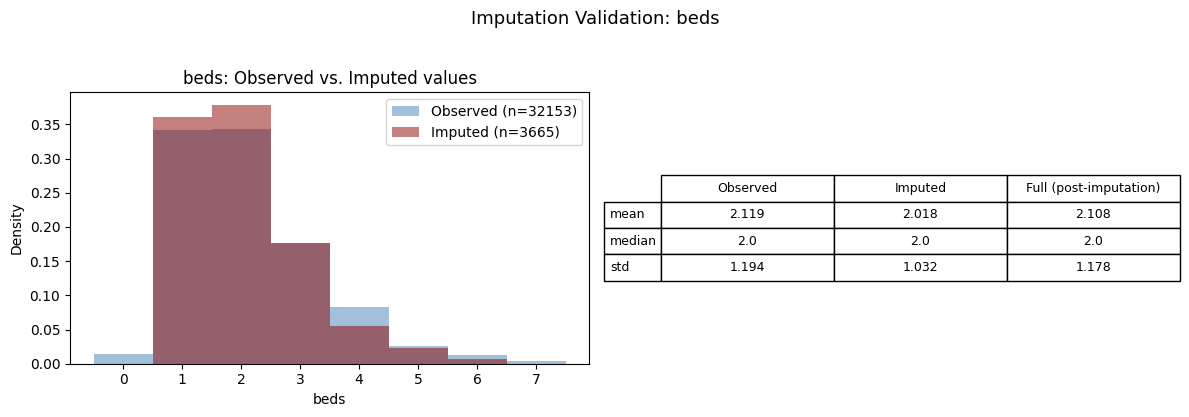

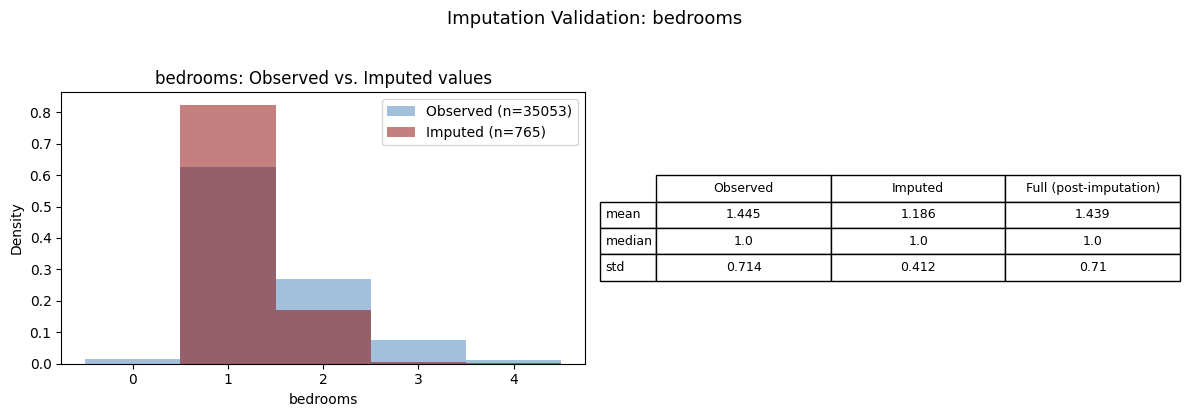

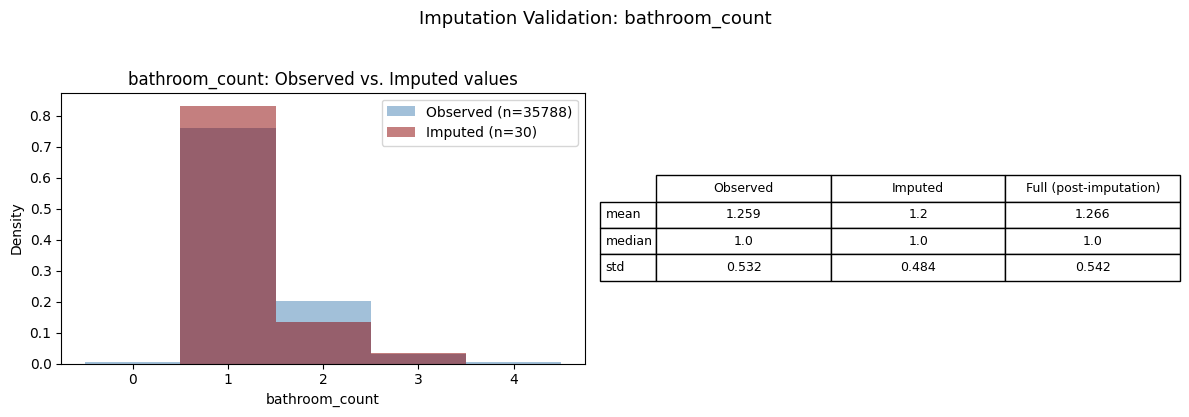

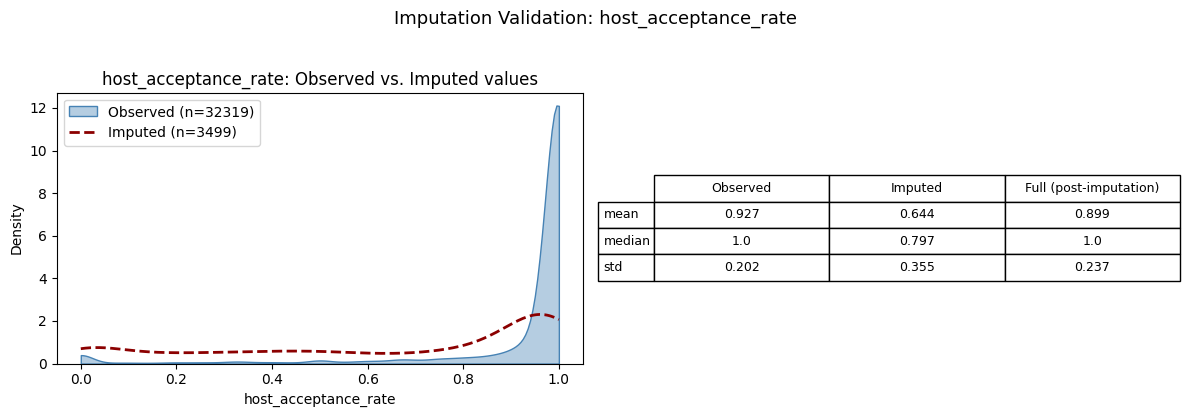

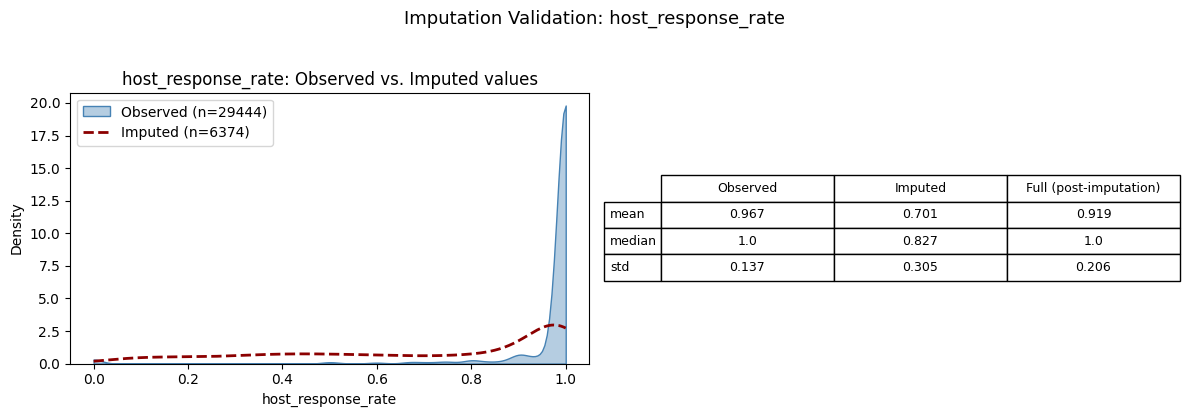

,variable,mean_observed,mean_imputed,std_observed,std_imputed,std_shrinkage_%
0,beds,2.119,2.018,1.194,1.032,13.6
1,bedrooms,1.445,1.186,0.714,0.412,42.3
2,bathroom_count,1.259,1.200,0.532,0.484,9.0
3,host_acceptance_rate,0.927,0.644,0.202,0.355,-75.7
4,host_response_rate,0.967,0.701,0.137,0.305,-122.6


In [86]:
# MAR Variables
mar_config = {
    'beds': (True,  None),
    'bedrooms': (True,  None),
    'bathroom_count': (True,  None),
    'host_acceptance_rate': (False, (0, 1)),
    'host_response_rate': (False, (0, 1)),
}

mar_rows = []
for col, (discrete, bounds) in mar_config.items():
    stats = validate_imputation(listings_trimmed, listings_clean, col,
                                 title=col, discrete=discrete, bounds=bounds)
    mar_rows.append({
        'variable': col,
        'mean_observed': stats.loc['mean', 'Observed'],
        'mean_imputed': stats.loc['mean', 'Imputed'],
        'std_observed': stats.loc['std', 'Observed'],
        'std_imputed': stats.loc['std', 'Imputed'],
        'std_shrinkage_%': round((1 - stats.loc['std', 'Imputed'] / stats.loc['std', 'Observed']) * 100, 1)
    })

mar_summary = pd.DataFrame(mar_rows)
display(mar_summary)

,proportion_superhost,n
Observed,0.398,33683
Imputed,0.420,2135


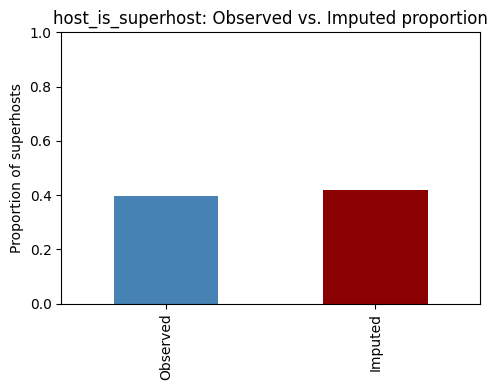

In [87]:
# Binary - host_is_superhost

was_missing = listings_trimmed['host_is_superhost'].isna()
observed = listings_trimmed.loc[~was_missing, 'host_is_superhost']
imputed_only = listings_clean.loc[was_missing, 'host_is_superhost']

superhost_validation = pd.DataFrame({
    'proportion_superhost': [observed.mean(), imputed_only.mean()],
    'n': [len(observed), len(imputed_only)]
}, index=['Observed', 'Imputed'])

display(superhost_validation.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
superhost_validation['proportion_superhost'].plot(kind='bar', ax=ax, color=['steelblue', 'darkred'])
ax.set_ylabel('Proportion of superhosts')
ax.set_title('host_is_superhost: Observed vs. Imputed proportion')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Post-Validation Decision: Imputation vs. Categorical Encoding

**1. MICE retained: `beds`, `bathroom_count`, `host_is_superhost`.**

`beds` and `bathroom_count` show mild shrinkage (9–14%) with no directional distortion in either statistic.
Standard shrinkage metrics do not apply to `host_is_superhosta`, which is binary outcome. Instead, imputation quality was assessed by comparing the proportion of superhosts among observed vs. imputed listings. The imputed proportion (42.0%) closely matches the observed proportion (39.8%), indicating that `IterativeImputer` recovers a plausible superhost rate for listings missing this value rather than defaulting to a compressed or biased estimate. `host_is_superhost` is therefore retained with its MICE-imputed values.

**2. Categorical binning: `bedrooms`, `review_scores × 7`, `reviews_per_month`, `last_review_recency`, `host_acceptance_rate`, `host_response_rate`**

- **`review_scores × 7` and `reviews_per_month`** show substantial shrinkage (34–60%), consistent with their MNAR mechanism: since these variables are structurally undefined for listings with zero reviews, the available predictors carry only a weak, indirect relationship to what the value would have been, and the model regresses toward an artificially compressed range.
- **`last_review_recency`**, after log-transformation, shows near-negligible shrinkage in standard deviation (-3.7%) but a substantial shift in the mean (169.9 observed vs. 281.6 imputed, a 66% relative increase), so this variable will be treated the same way as the rest of the MNAR block rather than retained as an imputed value.
- **`host_acceptance_rate` and `host_response_rate`** show severe negative shrinkage (-76% and -123% respectively), the most pronounced distortion observed across all variables tested, with imputed distributions flattening across the full [0,1] range despite the observed data being sharply peaked near 1.0. These reflect individual host behavior that the available listing-level predictors do not meaningfully explain.
- **`bedrooms`** shows shrinkage of 42.3%, well above the threshold applied to the other retained numeric variables, and is treated as rejected for imputation accordingly.

**3. Resulting strategy:**

- `beds` and `bathroom_count` keep their MICE-imputed values as the final treatment.
- `bedrooms`, all 7 `review_scores_*` variables, `reviews_per_month`, `last_review_recency`, `host_acceptance_rate`, and `host_response_rate` are reverted to their raw (pre-imputation) values and converted into categorical bins, with missing values assigned an explicit `"Unknown"` category.
- The `has_reviews` indicator is retained in the dataset for now, since it may still prove useful either as a standalone feature or as a cross-check against the `"Unknown"` category of the binned review variables. Its final inclusion in the clustering feature set, alongside the question of whether to retain all binned review-score variables individually or collapse them into a smaller subset (e.g., `review_scores_rating` alone), will be determined at the feature selection stage, once redundancy and multicollinearity among candidate features can be assessed directly.

### 7.7 Categorical Binning: Final Treatment for MNAR & Weakly-Imputed MAR Variables

**bedrooms → categorical (Studio/1BR/2BR/3+BR + Unknown)**

`bedrooms` showed shrinkage of 42.3% in the MICE run and is therefore converted to a categorical feature instead. Since `bedrooms` is a small-range count variable, fixed integer thresholds are used rather than quantiles, reflecting natural, interpretable property categories: `"Studio"` (0 bedrooms), `"1 Bedroom"`, `"2 Bedrooms"`, and `"3+ Bedrooms"`. Listings with missing values are assigned an explicit `"Unknown"` category.

In [88]:
def bin_fixed_thresholds(df, column, thresholds, labels):
    edges = [-np.inf] + thresholds + [np.inf]
    binned = pd.cut(df[column], bins=edges, labels=labels, include_lowest=True).astype(object)
    binned = binned.where(df[column].notna(), "Unknown")
    return pd.Categorical(binned, categories=labels + ["Unknown"], ordered=True)


bedrooms_thresholds = [0.5, 1.5, 2.5]
bedrooms_labels = ['Studio', '1 Bedroom', '2 Bedrooms', '3+ Bedrooms']

listings_clean['bedrooms_binned'] = bin_fixed_thresholds(
    listings_trimmed, 'bedrooms', bedrooms_thresholds, bedrooms_labels
)

display(listings_clean['bedrooms_binned'].value_counts(normalize=True).mul(100).round(1))

bedrooms_binned
1 Bedroom      61.2
2 Bedrooms     26.4
3+ Bedrooms     8.7
Unknown         2.1
Studio          1.6
Name: proportion, dtype: float64

**Review scores → binary categorical (Below/Above Average + Unknown)**

Given the severe shrinkage observed during MICE imputation, the `review_scores_*` variables are converted into binary categorical features instead of retaining synthetic numeric values. Values are split at a threshold of **4.8**, informed by the earlier percentile diagnostics, into `"Above Average"` and `"Below Average"`. Listings with no reviews are assigned an explicit `"Unknown"` category.

In [89]:
def bin_binary_threshold(df, column, threshold, labels=('Below Average', 'Above Average')):
    binned = np.where(df[column] < threshold, labels[0], labels[1])
    binned = pd.Series(binned, index=df.index).where(df[column].notna(), "Unknown")
    return pd.Categorical(binned, categories=list(labels) + ["Unknown"], ordered=True)


review_score_cols = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]

score_threshold = 4.8

for col in review_score_cols:
    listings_clean[f'{col}_binned'] = bin_binary_threshold(listings_trimmed, col, score_threshold)

score_breakdown = pd.DataFrame({
    col: listings_clean[f'{col}_binned'].value_counts(normalize=True).mul(100).round(1)
    for col in review_score_cols
}).T[['Below Average', 'Above Average', 'Unknown']]

display(score_breakdown)

,Below Average,Above Average,Unknown
review_scores_rating,32.4,53.4,14.2
review_scores_accuracy,25.7,60.0,14.2
review_scores_cleanliness,29.9,55.9,14.2
review_scores_checkin,18.0,67.8,14.2
review_scores_communication,16.1,69.6,14.2
review_scores_location,36.3,49.4,14.2
review_scores_value,47.4,38.3,14.2


**Host rates → binary categorical (Partial/Full + Unknown)**

`host_acceptance_rate` and `host_response_rate` show a fundamentally different distribution shape than the review scores: percentile diagnostics reveal a heavy point mass sitting exactly at the ceiling value of 1.0, rather than a spread-out distribution with a meaningful center. A ceiling split at **threshold = 1.0** is used to directly capture the substantively meaningful distinction in the data: whether a host is *perfectly* reliable on this metric (`"Full Acceptance"` / `"Full Response"`) versus only partially so (`"Partial Acceptance"` / `"Partial Response"`). As with the review scores, missing values are assigned an explicit `"Unknown"` category. This approach yields a considerably more balanced and interpretable split than an artificial average-based threshold would.

In [90]:
rate_cols_labels = {
    'host_acceptance_rate': ('Partial Acceptance', 'Full Acceptance'),
    'host_response_rate': ('Partial Response', 'Full Response'),
}
rate_threshold = 1

for col, labels in rate_cols_labels.items():
    listings_clean[f'{col}_binned'] = bin_binary_threshold(listings_trimmed, col, rate_threshold, labels)

rate_breakdown = pd.DataFrame({
    col: listings_clean[f'{col}_binned'].value_counts(normalize=True).mul(100).round(1)
    for col in rate_cols_labels
}).T

display(rate_breakdown)

,Full Acceptance,Full Response,Partial Acceptance,Partial Response,Unknown
host_acceptance_rate,59.5,NaN,30.8,NaN,9.8
host_response_rate,NaN,68.8,NaN,13.4,17.8


**reviews_per_month & last_review_recency → categorical (fixed thresholds + Unknown)**

Both variables belong to the MNAR block, since neither concept is structurally defined for listings with no reviews. Fixed, domain-informed thresholds are used instead of quantile splits for both:

- `reviews_per_month` is split at **0.5** and **2.5**, closely aligned with the observed 25th (0.46) and 75th (2.68) percentiles, into `"Low Demand"`, `"Moderate Demand"`, and `"High Demand"`.
- `last_review_recency` is split at **90** and **365 days** into `"Active"`, `"Moderate"`, and `"Dormant"`, reflecting the "zombie listing" concept identified during outlier diagnosis. Although the MICE showed near-negligible shrinkage in standard deviation for this variable, its imputed mean shifted substantially from the observed value, and the underlying concept (days since the last review) is not well-defined for a listing that has never received one.

In both cases, listings with no reviews receive the explicit `"Unknown"` category.

In [91]:
demand_thresholds = [0.5, 2.5]
demand_labels = ['Low Demand', 'Moderate Demand', 'High Demand']

listings_clean['reviews_per_month_binned'] = bin_fixed_thresholds(
    listings_trimmed, 'reviews_per_month', demand_thresholds, demand_labels
)

display(listings_clean['reviews_per_month_binned'].value_counts(normalize=True).mul(100).round(1))


recency_thresholds = [90, 365]
recency_labels = ['Active', 'Moderate', 'Dormant']

listings_clean['last_review_recency_binned'] = bin_fixed_thresholds(
    listings_trimmed, 'last_review_recency', recency_thresholds, recency_labels
)

display(listings_clean['last_review_recency_binned'].value_counts(normalize=True).mul(100).round(1))

reviews_per_month_binned
Moderate Demand    39.5
High Demand        23.4
Low Demand         22.9
Unknown            14.2
Name: proportion, dtype: float64

last_review_recency_binned
Active      57.4
Moderate    17.0
Unknown     14.2
Dormant     11.3
Name: proportion, dtype: float64

### 7.8 Finalizing listings_clean dataframe

In [92]:
# revert MICE-imputed values for variables where binning was chosen instead
cols_mice_rejected = [
    'bedrooms',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month', 'last_review_recency',
    'host_acceptance_rate', 'host_response_rate'
]

for col in cols_mice_rejected:
    listings_clean[col] = listings_trimmed[col]

listings_clean = listings_clean.rename(columns={col: f'{col}_raw' for col in cols_mice_rejected})

# sanity check — confirm final missingness state of listings_clean
final_missing = listings_clean.isna().sum()
final_missing = final_missing[final_missing > 0].sort_values(ascending=False)

print("Remaining missing values in listings_clean")
display(final_missing.rename('missing_count').to_frame()
        .assign(missing_pct=lambda d: (d['missing_count'] / len(listings_clean) * 100).round(2)))

Remaining missing values in listings_clean


,missing_count,missing_pct
host_response_rate_raw,6374,17.80
review_scores_rating_raw,5100,14.24
review_scores_accuracy_raw,5100,14.24
review_scores_cleanliness_raw,5100,14.24
review_scores_checkin_raw,5100,14.24
review_scores_communication_raw,5100,14.24
review_scores_location_raw,5100,14.24
review_scores_value_raw,5100,14.24
reviews_per_month_raw,5100,14.24
last_review_recency_raw,5100,14.24


### 7.9 Aligning Reviews with Final Listings

`reviews_cleaned` was built and cleaned independently of the listings pipeline, so it still contains reviews for listings removed later during outlier trimming and the tiny host cluster drop. Filtering it here, against the final `listings_clean['id']` set, ensures `reviews_clean.csv` never contains "orphaned" reviews for listings that no longer exist.

In [93]:
surviving_listing_ids = set(listings_clean['id'])

n_before = len(reviews_cleaned)
reviews_cleaned = reviews_cleaned[reviews_cleaned['listing_id'].isin(surviving_listing_ids)].reset_index(drop=True)
n_after = len(reviews_cleaned)

print(f"reviews before filtering to surviving listings: {n_before:,}")
print(f"reviews after filtering: {n_after:,}")
print(f"dropped (orphaned reviews for trimmed/removed listings): {n_before - n_after:,} "
      f"({(n_before - n_after) / n_before * 100:.3f}%)")

reviews before filtering to surviving listings: 2,193,159
reviews after filtering: 2,125,661
dropped (orphaned reviews for trimmed/removed listings): 67,498 (3.078%)


In [94]:
# save the cleaned datasets
listings_clean.to_csv(BASE_PATH / "data" / "processed" / "listings_clean.csv", index=False)
reviews_cleaned.to_csv(BASE_PATH / "data" / "processed" / "reviews_clean.csv", index=False)

## 8. Summary & Data Cleaning Conclusion

This notebook covered the full preparation pipeline for the listings and reviews datasets, transforming raw, semi-structured scrapes into an analysis-ready foundation for market segmentation.

**Key steps completed:**

- **Structural cleaning**: irrelevant, redundant, and black-box-derived columns were dropped, and complex fields (`price`, `bathrooms_text`, `host_verifications`, `license`, date columns, percentage columns) were parsed into clean numeric, boolean, or categorical representations.
- **Amenities engineering**: the noisy `amenities` free-text field was denoised, mapped into semantic categories, and reduced to a small set of premium indicators, selected from a luxury classification and filtered by prevalence, turning a high-dimensional text field into interpretable structured features.
- **Duplicates**: listings were confirmed to be structurally unique despite name/description overlaps (different units under the same host); reviews were deduplicated on a composite key while preserving genuine repeat feedback.
- **Data profiling**: numerical, binary, and categorical distributions were examined across host behaviour, property characteristics, pricing, availability, demand, and guest satisfaction, surfacing early signals for segmentation (host professionalization, short- vs long-term rental patterns, ceiling effects in review scores and response rates).
- **Consistency check**: `number_of_reviews` was validated against the raw reviews dataset and corrected to reflect the true, ground-truth review count per listing.
- **Outlier handling**: treatment was decided per variable rather than applying a single rule: trimming for structurally implausible values (e.g. bedrooms, host portfolio size, long-term rental thresholds), capping for legitimate but extreme values (e.g. amenities count, review volume, system-default max nights), and no treatment for naturally bounded variables (review scores, response/acceptance rates).
- **Missing values**: missingness was diagnosed structurally (via matrix and correlation heatmap) rather than treated uniformly, distinguishing MNAR review-related gaps, MAR-like host behaviour gaps, and MCAR-like profile gaps. MICE imputation was tested and validated against observed distributions, and only retained where it didn't distort the underlying distribution; variables with significant shrinkage or mean shift were instead converted into interpretable categorical bins with an explicit "Unknown" level, preserving the missingness signal rather than masking it.

**Key takeaways for the next stages:**

- **Feature Engineering**: several variables were intentionally deferred to this stage: location (`neighbourhood_cleansed`, `property_type`) needs consolidation into fewer macro-categories to avoid sparsity; host behaviour metrics (response/acceptance rate, listings count) are candidates for log-transformation or bucketing due to heavy skew and ceiling effects; and the review-score block should be assessed for redundancy given its strong internal correlation.
- **EDA**: the correlation analysis already flagged that traditional quality signals (review scores) barely relate to price, while structural and host-scale variables do, suggesting price and satisfaction may define largely independent axes of variation worth exploring further before modeling.
- **Feature Selection**: multicollinearity is expected to be a central concern, both within the review-score cluster and within property-size/host-scale groups; dimensionality reduction or careful manual selection will likely be needed before clustering.
- **Modeling**: `price` was deliberately excluded from imputation and from the feature set itself, being reserved as an independent, untouched variable for post-hoc validation of the resulting segments rather than as a clustering input.

The resulting `listings_clean` dataset is now structurally consistent, free of implausible extreme values, and carries an explicit, auditable trail of how every missing value was resolved — providing a reliable foundation for the feature engineering and segmentation work ahead.